In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# 1. 路径设置
# =========================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的")
INPUT_FILE = BASE_DIR / "analyzed_cleaned.csv"
OUTPUT_DIR = BASE_DIR / "part2_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

POST_BASE_FILE = OUTPUT_DIR / "post_base.csv"
COMMENT_BASE_FILE = OUTPUT_DIR / "comment_base.csv"
TOPIC_MERGED_TEMPLATE_FILE = OUTPUT_DIR / "topic_merged_template.csv"

# 后续你做完聚类后，把这两个文件放进同一个文件夹
POST_TOPIC_FILE = OUTPUT_DIR / "post_topic_result.csv"
COMMENT_TOPIC_FILE = OUTPUT_DIR / "comment_topic_result.csv"
TOPIC_MERGED_FILE = OUTPUT_DIR / "topic_merged.csv"


# =========================
# 2. 读取数据
# =========================
df = pd.read_csv(INPUT_FILE, low_memory=False)

print("原始数据大小：", df.shape)
print("原始列名：")
print(df.columns.tolist())


# =========================
# 3. 文本清洗函数
# =========================
def clean_text(x):
    """
    统一处理空值、空格、'nan'、'None' 等问题
    """
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x.lower() in ["nan", "none", "null"]:
        return ""
    return x


def choose_text(preferred, fallback1="", fallback2=""):
    """
    优先用 preferred，如果没有就 fallback1 + fallback2
    """
    preferred = clean_text(preferred)
    fallback1 = clean_text(fallback1)
    fallback2 = clean_text(fallback2)

    if preferred:
        return preferred

    parts = [p for p in [fallback1, fallback2] if p]
    return " ".join(parts).strip()


# =========================
# 4. 生成帖子基础表 post_base
# =========================
post_cols = ["post_id", "title", "content_y", "translated_content_y", "keywords"]
post_base = df[post_cols].copy()

# 一帖一行：按 post_id 去重
post_base = post_base.drop_duplicates(subset=["post_id"]).copy()

# 生成聚类文本列 post_text
post_base["post_text"] = post_base.apply(
    lambda row: choose_text(
        row["translated_content_y"],   # 优先翻译文本
        row["title"],                  # 没有就 title
        row["content_y"]               # 再拼正文
    ),
    axis=1
)

# 去掉 post_id 为空 或 post_text 为空 的记录
post_base["post_id"] = post_base["post_id"].astype(str).str.strip()
post_base = post_base[(post_base["post_id"] != "") & (post_base["post_text"] != "")].copy()

# 可选：加一个帖子文本长度列，方便你后面筛选
post_base["post_text_len"] = post_base["post_text"].str.len()

# 保存
post_base.to_csv(POST_BASE_FILE, index=False, encoding="utf-8-sig")

print("\npost_base 已生成：", POST_BASE_FILE)
print("post_base 大小：", post_base.shape)
print(post_base.head(3))


# =========================
# 5. 生成评论基础表 comment_base
# =========================
comment_cols = [
    "comment_id",
    "post_id",
    "content_x",
    "translated_content_x",
    "sentiment_score",
    "sentiment_category",
    "has_blame",
    "blame_object"
]
comment_base = df[comment_cols].copy()

# 一评一行：按 comment_id 去重
comment_base = comment_base.drop_duplicates(subset=["comment_id"]).copy()

# 生成评论聚类文本列 comment_text
comment_base["comment_text"] = comment_base.apply(
    lambda row: choose_text(
        row["translated_content_x"],   # 优先翻译评论
        row["content_x"]               # 没有就原评论
    ),
    axis=1
)

# 去掉 comment_id / post_id / comment_text 为空的记录
comment_base["comment_id"] = comment_base["comment_id"].astype(str).str.strip()
comment_base["post_id"] = comment_base["post_id"].astype(str).str.strip()

comment_base = comment_base[
    (comment_base["comment_id"] != "") &
    (comment_base["post_id"] != "") &
    (comment_base["comment_text"] != "")
].copy()

# 可选：加评论长度列
comment_base["comment_text_len"] = comment_base["comment_text"].str.len()

# 保存
comment_base.to_csv(COMMENT_BASE_FILE, index=False, encoding="utf-8-sig")

print("\ncomment_base 已生成：", COMMENT_BASE_FILE)
print("comment_base 大小：", comment_base.shape)
print(comment_base.head(3))


# =========================
# 6. 先生成 topic_merged 的模板表
#    （现在先放空的 cluster 字段，后面聚类完再填）
# =========================
topic_merged_template = comment_base[
    [
        "comment_id",
        "post_id",
        "sentiment_score",
        "sentiment_category",
        "has_blame",
        "blame_object"
    ]
].copy()

topic_merged_template["post_cluster_id"] = ""
topic_merged_template["post_cluster_label"] = ""
topic_merged_template["comment_cluster_id"] = ""
topic_merged_template["comment_cluster_label"] = ""

# 调整列顺序
topic_merged_template = topic_merged_template[
    [
        "comment_id",
        "post_id",
        "post_cluster_id",
        "post_cluster_label",
        "comment_cluster_id",
        "comment_cluster_label",
        "sentiment_score",
        "sentiment_category",
        "has_blame",
        "blame_object"
    ]
]

topic_merged_template.to_csv(TOPIC_MERGED_TEMPLATE_FILE, index=False, encoding="utf-8-sig")

print("\ntopic_merged_template 已生成：", TOPIC_MERGED_TEMPLATE_FILE)
print("topic_merged_template 大小：", topic_merged_template.shape)
print(topic_merged_template.head(3))


# =========================
# 7. 如果你后面已经准备好了两个聚类结果表
#    就自动生成正式版 topic_merged.csv
# =========================
if POST_TOPIC_FILE.exists() and COMMENT_TOPIC_FILE.exists():
    print("\n检测到 post_topic_result.csv 和 comment_topic_result.csv，开始生成正式 topic_merged.csv ...")

    post_topic = pd.read_csv(POST_TOPIC_FILE, low_memory=False)
    comment_topic = pd.read_csv(COMMENT_TOPIC_FILE, low_memory=False)

    # ---------- 检查字段 ----------
    required_post_cols = {"post_id", "cluster_id", "cluster_label"}
    required_comment_cols = {"comment_id", "post_id", "comment_cluster_id", "comment_cluster_label"}

    if not required_post_cols.issubset(post_topic.columns):
        raise ValueError(
            f"post_topic_result.csv 缺少字段：{required_post_cols - set(post_topic.columns)}"
        )

    if not required_comment_cols.issubset(comment_topic.columns):
        raise ValueError(
            f"comment_topic_result.csv 缺少字段：{required_comment_cols - set(comment_topic.columns)}"
        )

    # ---------- 标准化 post topic 列名 ----------
    post_topic = post_topic.rename(
        columns={
            "cluster_id": "post_cluster_id",
            "cluster_label": "post_cluster_label"
        }
    )

    post_topic = post_topic[["post_id", "post_cluster_id", "post_cluster_label"]].copy()
    post_topic = post_topic.drop_duplicates(subset=["post_id"])

    # ---------- 标准化 comment topic 列 ----------
    comment_topic = comment_topic[
        ["comment_id", "post_id", "comment_cluster_id", "comment_cluster_label"]
    ].copy()

    comment_topic = comment_topic.drop_duplicates(subset=["comment_id"])

    # ---------- 合并 ----------
    topic_merged = comment_base.merge(
        comment_topic,
        on=["comment_id", "post_id"],
        how="left"
    ).merge(
        post_topic,
        on="post_id",
        how="left"
    )

    # 调整列顺序
    topic_merged = topic_merged[
        [
            "comment_id",
            "post_id",
            "post_cluster_id",
            "post_cluster_label",
            "comment_cluster_id",
            "comment_cluster_label",
            "sentiment_score",
            "sentiment_category",
            "has_blame",
            "blame_object",
            "comment_text"
        ]
    ]

    topic_merged.to_csv(TOPIC_MERGED_FILE, index=False, encoding="utf-8-sig")

    print("\n正式 topic_merged 已生成：", TOPIC_MERGED_FILE)
    print("topic_merged 大小：", topic_merged.shape)
    print(topic_merged.head(3))

else:
    print("\n暂未检测到 post_topic_result.csv 或 comment_topic_result.csv")
    print("目前已经先生成 topic_merged_template.csv")
    print("等你完成帖子聚类和评论聚类之后，把结果表放到同一个文件夹，再重新运行本脚本即可自动生成正式版 topic_merged.csv")

原始数据大小： (78900, 51)
原始列名：
['comment_id', 'post_time_x', 'author_id_x', 'author_name_x', 'content_x', 'language_x', 'translated_content_x', 'platform_x', 'reply_to_id', 'comment_type', 'images_x', 'post_id', 'view_count_x', 'like_count_x', 'reply_count_x', 'user_level_x', 'is_verified_x', 'sentiment_x', 'content_length', 'updated_time_x', 'status_x', 'platform_y', 'country', 'title', 'content_y', 'language_y', 'translated_content_y', 'post_time_y', 'author_id_y', 'author_name_y', 'post_url', 'images_y', 'view_count_y', 'like_count_y', 'reply_count_y', 'share_count', 'keywords', 'sentiment_y', 'sentiment_score', 'topic_category', 'is_verified_y', 'user_level_y', 'updated_time_y', 'status_y', 'sentiment_category', 'fine_grained_emotions', 'has_blame', 'blame_subject', 'blame_object', 'blame_intensity', 'analysis_timestamp']

post_base 已生成： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/post_base.csv
post_base 大小： (8307, 7)
                               post_id title     

In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

# =====================================================
# 1. 路径设置
# =====================================================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的")
INPUT_FILE = BASE_DIR / "analyzed_cleaned.csv"
OUTPUT_DIR = BASE_DIR / "part2_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COMMENT_BASE_FILE = OUTPUT_DIR / "comment_base.csv"
POST_BASE_FILE = OUTPUT_DIR / "post_base.csv"
TOPIC_MERGED_FILE = OUTPUT_DIR / "topic_merged.csv"

# 如果你后面做完聚类，请把结果表放到这个目录下
POST_TOPIC_FILE = OUTPUT_DIR / "post_topic_result.csv"
COMMENT_TOPIC_FILE = OUTPUT_DIR / "comment_topic_result.csv"


# =====================================================
# 2. 读取数据
# =====================================================
df = pd.read_csv(INPUT_FILE, low_memory=False)
print("原始数据大小：", df.shape)
print("列名：", df.columns.tolist())


# =====================================================
# 3. 基础清洗函数
# =====================================================
def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x.lower() in ["nan", "none", "null"]:
        return ""
    return x


def choose_text(preferred, fallback1="", fallback2=""):
    preferred = clean_text(preferred)
    fallback1 = clean_text(fallback1)
    fallback2 = clean_text(fallback2)

    if preferred:
        return preferred

    parts = [p for p in [fallback1, fallback2] if p]
    return " ".join(parts).strip()


def normalize_sentiment_category(x):
    x = clean_text(x).lower()
    mapping = {
        "positive": "positive",
        "pos": "positive",
        "negative": "negative",
        "neg": "negative",
        "neutral": "neutral",
        "neu": "neutral",
    }
    return mapping.get(x, x if x else "")


def normalize_has_blame(x):
    x = clean_text(x).lower()
    if x in ["是", "yes", "y", "true", "1"]:
        return "yes"
    if x in ["否", "no", "n", "false", "0"]:
        return "no"
    return x


def mode_nonempty(series):
    s = series.dropna().astype(str).str.strip()
    s = s[~s.isin(["", "nan", "None", "null"])]
    if len(s) == 0:
        return ""
    vc = s.value_counts()
    return vc.index[0]


def parse_multi_labels(x):
    """
    处理 fine_grained_emotions 这种可能有多个标签的字段
    例如：
    anger
    anger,mock
    ['anger', 'mock']
    anger; mock
    """
    x = clean_text(x)
    if not x:
        return []

    # 去掉中括号和引号
    x = x.replace("[", "").replace("]", "")
    x = x.replace("'", "").replace('"', "")

    # 用常见分隔符切开
    parts = re.split(r"[,;/|、]+", x)
    parts = [p.strip() for p in parts if p.strip()]
    return parts


def top_multi_label(series):
    """
    从多标签字段中，统计最常见的一个标签
    """
    all_labels = []
    for item in series:
        all_labels.extend(parse_multi_labels(item))

    if not all_labels:
        return ""

    return pd.Series(all_labels).value_counts().index[0]


# =====================================================
# 4. 生成 comment_base
#    comment 表：带原始情感字段
# =====================================================
comment_cols = [
    "comment_id",
    "post_id",
    "content_x",
    "translated_content_x",
    "sentiment_score",
    "sentiment_category",
    "fine_grained_emotions",
    "has_blame",
    "blame_subject",
    "blame_object",
    "blame_intensity",
]

comment_base = df[comment_cols].copy()

# 去重：一条评论一行
comment_base = comment_base.drop_duplicates(subset=["comment_id"]).copy()

# 生成 comment_text：优先翻译，没有就原文
comment_base["comment_text"] = comment_base.apply(
    lambda row: choose_text(
        row["translated_content_x"],
        row["content_x"]
    ),
    axis=1
)

# 标准化几个关键标签
comment_base["sentiment_category"] = comment_base["sentiment_category"].apply(normalize_sentiment_category)
comment_base["has_blame"] = comment_base["has_blame"].apply(normalize_has_blame)

# 清理空 ID / 空文本
comment_base["comment_id"] = comment_base["comment_id"].astype(str).str.strip()
comment_base["post_id"] = comment_base["post_id"].astype(str).str.strip()

comment_base = comment_base[
    (comment_base["comment_id"] != "") &
    (comment_base["post_id"] != "") &
    (comment_base["comment_text"] != "")
].copy()

# 文本长度
comment_base["comment_text_len"] = comment_base["comment_text"].str.len()

# 保存
comment_base.to_csv(COMMENT_BASE_FILE, index=False, encoding="utf-8-sig")
print(f"\ncomment_base 已保存：{COMMENT_BASE_FILE}")
print("comment_base 大小：", comment_base.shape)


# =====================================================
# 5. 生成 post 级情感聚合特征
#    post 表：带聚合后的情感字段
# =====================================================
# 先做每个 post 下评论的聚合
post_agg_basic = comment_base.groupby("post_id", as_index=False).agg(
    comment_count=("comment_id", "count"),
    avg_sentiment_score=("sentiment_score", "mean"),
    blame_ratio=("has_blame", lambda s: np.mean(s == "yes")),
    main_blame_subject=("blame_subject", mode_nonempty),
    main_blame_object=("blame_object", mode_nonempty),
    main_blame_intensity=("blame_intensity", mode_nonempty),
)

# 正负中性占比
sentiment_dist = (
    comment_base
    .pivot_table(
        index="post_id",
        columns="sentiment_category",
        values="comment_id",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

# 确保三列都存在
for col in ["positive", "negative", "neutral"]:
    if col not in sentiment_dist.columns:
        sentiment_dist[col] = 0

sentiment_dist["total_sentiment_comments"] = (
    sentiment_dist["positive"] + sentiment_dist["negative"] + sentiment_dist["neutral"]
).replace(0, np.nan)

sentiment_dist["pos_ratio"] = sentiment_dist["positive"] / sentiment_dist["total_sentiment_comments"]
sentiment_dist["neg_ratio"] = sentiment_dist["negative"] / sentiment_dist["total_sentiment_comments"]
sentiment_dist["neu_ratio"] = sentiment_dist["neutral"] / sentiment_dist["total_sentiment_comments"]

sentiment_dist = sentiment_dist[["post_id", "pos_ratio", "neg_ratio", "neu_ratio"]]

# 细粒度情绪主标签
post_main_emotion = (
    comment_base.groupby("post_id")["fine_grained_emotions"]
    .apply(top_multi_label)
    .reset_index(name="main_fine_grained_emotion")
)

# 合并成 post 情感聚合特征表
post_sentiment_features = (
    post_agg_basic
    .merge(sentiment_dist, on="post_id", how="left")
    .merge(post_main_emotion, on="post_id", how="left")
)

# 空值处理
for col in ["avg_sentiment_score", "blame_ratio", "pos_ratio", "neg_ratio", "neu_ratio"]:
    post_sentiment_features[col] = post_sentiment_features[col].fillna(0)


# =====================================================
# 6. 生成 post_base
#    post 表：一帖一行 + 聚合情感字段
# =====================================================
post_cols = [
    "post_id",
    "title",
    "content_y",
    "translated_content_y",
    "keywords"
]

post_base = df[post_cols].copy()
post_base = post_base.drop_duplicates(subset=["post_id"]).copy()

# 生成 post_text：优先翻译文本，没有就 title + 正文
post_base["post_text"] = post_base.apply(
    lambda row: choose_text(
        row["translated_content_y"],
        row["title"],
        row["content_y"]
    ),
    axis=1
)

post_base["post_id"] = post_base["post_id"].astype(str).str.strip()
post_base = post_base[(post_base["post_id"] != "") & (post_base["post_text"] != "")].copy()
post_base["post_text_len"] = post_base["post_text"].str.len()

# 合并 post 级情感聚合结果
post_base = post_base.merge(post_sentiment_features, on="post_id", how="left")

# 空值补齐
fill_zero_cols = ["comment_count", "avg_sentiment_score", "blame_ratio", "pos_ratio", "neg_ratio", "neu_ratio"]
for col in fill_zero_cols:
    if col in post_base.columns:
        post_base[col] = post_base[col].fillna(0)

fill_empty_cols = ["main_blame_subject", "main_blame_object", "main_blame_intensity", "main_fine_grained_emotion"]
for col in fill_empty_cols:
    if col in post_base.columns:
        post_base[col] = post_base[col].fillna("")

# 保存
post_base.to_csv(POST_BASE_FILE, index=False, encoding="utf-8-sig")
print(f"\npost_base 已保存：{POST_BASE_FILE}")
print("post_base 大小：", post_base.shape)


# =====================================================
# 7. 生成 topic_merged
#    merged 总表：完整情感字段 + 聚类标签
# =====================================================
# 先从 comment_base 出发，默认 cluster 列为空
topic_merged = comment_base[
    [
        "comment_id",
        "post_id",
        "comment_text",
        "sentiment_score",
        "sentiment_category",
        "fine_grained_emotions",
        "has_blame",
        "blame_subject",
        "blame_object",
        "blame_intensity"
    ]
].copy()

topic_merged["post_cluster_id"] = ""
topic_merged["post_cluster_label"] = ""
topic_merged["comment_cluster_id"] = ""
topic_merged["comment_cluster_label"] = ""

# 如果已经有聚类结果表，就自动合并进来
if POST_TOPIC_FILE.exists():
    post_topic = pd.read_csv(POST_TOPIC_FILE, low_memory=False)

    required_post_cols = {"post_id", "cluster_id", "cluster_label"}
    if required_post_cols.issubset(post_topic.columns):
        post_topic = post_topic.rename(columns={
            "cluster_id": "post_cluster_id",
            "cluster_label": "post_cluster_label"
        })
        post_topic = post_topic[["post_id", "post_cluster_id", "post_cluster_label"]].drop_duplicates("post_id")

        topic_merged = topic_merged.merge(post_topic, on="post_id", how="left", suffixes=("", "_new"))

        if "post_cluster_id_new" in topic_merged.columns:
            topic_merged["post_cluster_id"] = topic_merged["post_cluster_id_new"].fillna(topic_merged["post_cluster_id"])
            topic_merged["post_cluster_label"] = topic_merged["post_cluster_label_new"].fillna(topic_merged["post_cluster_label"])
            topic_merged = topic_merged.drop(columns=["post_cluster_id_new", "post_cluster_label_new"])

if COMMENT_TOPIC_FILE.exists():
    comment_topic = pd.read_csv(COMMENT_TOPIC_FILE, low_memory=False)

    required_comment_cols = {"comment_id", "post_id", "comment_cluster_id", "comment_cluster_label"}
    if required_comment_cols.issubset(comment_topic.columns):
        comment_topic = comment_topic[
            ["comment_id", "post_id", "comment_cluster_id", "comment_cluster_label"]
        ].drop_duplicates("comment_id")

        topic_merged = topic_merged.merge(
            comment_topic,
            on=["comment_id", "post_id"],
            how="left",
            suffixes=("", "_new")
        )

        if "comment_cluster_id_new" in topic_merged.columns:
            topic_merged["comment_cluster_id"] = topic_merged["comment_cluster_id_new"].fillna(topic_merged["comment_cluster_id"])
            topic_merged["comment_cluster_label"] = topic_merged["comment_cluster_label_new"].fillna(topic_merged["comment_cluster_label"])
            topic_merged = topic_merged.drop(columns=["comment_cluster_id_new", "comment_cluster_label_new"])

# 调整列顺序
topic_merged = topic_merged[
    [
        "comment_id",
        "post_id",
        "post_cluster_id",
        "post_cluster_label",
        "comment_cluster_id",
        "comment_cluster_label",
        "comment_text",
        "sentiment_score",
        "sentiment_category",
        "fine_grained_emotions",
        "has_blame",
        "blame_subject",
        "blame_object",
        "blame_intensity"
    ]
]

# 保存
topic_merged.to_csv(TOPIC_MERGED_FILE, index=False, encoding="utf-8-sig")
print(f"\ntopic_merged 已保存：{TOPIC_MERGED_FILE}")
print("topic_merged 大小：", topic_merged.shape)

print("\n全部完成。")
print("输出文件：")
print("1.", COMMENT_BASE_FILE)
print("2.", POST_BASE_FILE)
print("3.", TOPIC_MERGED_FILE)

原始数据大小： (78900, 51)
列名： ['comment_id', 'post_time_x', 'author_id_x', 'author_name_x', 'content_x', 'language_x', 'translated_content_x', 'platform_x', 'reply_to_id', 'comment_type', 'images_x', 'post_id', 'view_count_x', 'like_count_x', 'reply_count_x', 'user_level_x', 'is_verified_x', 'sentiment_x', 'content_length', 'updated_time_x', 'status_x', 'platform_y', 'country', 'title', 'content_y', 'language_y', 'translated_content_y', 'post_time_y', 'author_id_y', 'author_name_y', 'post_url', 'images_y', 'view_count_y', 'like_count_y', 'reply_count_y', 'share_count', 'keywords', 'sentiment_y', 'sentiment_score', 'topic_category', 'is_verified_y', 'user_level_y', 'updated_time_y', 'status_y', 'sentiment_category', 'fine_grained_emotions', 'has_blame', 'blame_subject', 'blame_object', 'blame_intensity', 'analysis_timestamp']

comment_base 已保存：/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/comment_base.csv
comment_base 大小： (78886, 13)

post_base 已保存：/Users/xujingyu/Desktop/课程

In [4]:
!pip install openai --upgrade
from openai import OpenAI

client = OpenAI(
    api_key="xai-kw0TsJVQRUK00G0kGIlgo9mMvFLYaV6Tf6N23ZVTbpDWVj6LvgQMFzEq0Jln1iNqP8Dz7n98OXgRig61",  
    base_url="https://api.x.ai/v1"
)

response = client.chat.completions.create(
    model="grok-4-1-fast-non-reasoning",     # ←←← 改成这个（最推荐）
    # model="grok-4.20-non-reasoning",       # 或者用这个更强的
    messages=[{"role": "user", "content": "Hello! 你好，请简单介绍一下自己。"}],
    temperature=0.7,
    max_tokens=200
)

print(response.choices[0].message.content)

你好！我是Grok，由xAI打造的AI助手，灵感来源于《银河系漫游指南》和贾维斯。我的目标是最大限度地帮助你解答问题、探索想法，并以幽默和实用的方式回应。有什么可以帮你的？😊


In [5]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

# =========================
# 1. 路径设置
# =========================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的")
INPUT_FILE = BASE_DIR / "analyzed_cleaned.csv"
OUTPUT_DIR = BASE_DIR / "part2_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COMMENT_BASE_FILE = OUTPUT_DIR / "comment_base.csv"
COMMENT_PILOT_FILE = OUTPUT_DIR / "comment_pilot_150.csv"

RANDOM_STATE = 42
TARGET_POSTS = 50         # 目标抽 50 个不同 post
COMMENTS_PER_POST = 3     # 每个 post 尽量抽 3 条 comment
TARGET_TOTAL = 150        # 最终目标 150 条

# =========================
# 2. 读取数据
# =========================
df = pd.read_csv(INPUT_FILE, low_memory=False)
print("原始数据大小：", df.shape)

# =========================
# 3. 工具函数
# =========================
def ensure_col(df, col):
    """如果列不存在，就补一个空列"""
    if col not in df.columns:
        df[col] = ""
    return df

def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x.lower() in ["nan", "none", "null"]:
        return ""
    return x

def choose_text(preferred, fallback=""):
    preferred = clean_text(preferred)
    fallback = clean_text(fallback)
    return preferred if preferred else fallback

def normalize_sentiment_category(x):
    x = clean_text(x).lower()
    mapping = {
        "positive": "positive",
        "pos": "positive",
        "negative": "negative",
        "neg": "negative",
        "neutral": "neutral",
        "neu": "neutral",
    }
    return mapping.get(x, x)

def normalize_has_blame(x):
    x = clean_text(x).lower()
    if x in ["是", "yes", "y", "true", "1"]:
        return "yes"
    if x in ["否", "no", "n", "false", "0"]:
        return "no"
    return x

def is_noise_text(text):
    """
    过滤明显噪音评论
    """
    t = clean_text(text).lower()

    if not t:
        return True

    # 太短：只有 1~2 个字符 / 纯符号 / 纯数字
    if len(t) <= 2:
        return True

    if re.fullmatch(r"[\W_]+", t):   # 全是符号
        return True

    if re.fullmatch(r"\d+", t):      # 全是数字
        return True

    # 常见低信息短回复
    low_info = {
        "ok", "okay", "yes", "no", "lol", "lmao", "omg", "same", "+1",
        "fake", "real?", "really?", "哈哈", "呵呵", "是的", "不是", "真的", "假的"
    }
    if t in low_info:
        return True

    # 常见自动回复 / 系统噪音
    noise_patterns = [
        r"automoderator",
        r"recovery scam",
        r"recover your funds",
        r"dm me",
        r"message me on",
        r"contact .* on telegram",
        r"whatsapp",
        r"instagram",
        r"kindly inbox",
        r"admin",
        r"moderator",
        r"bot",
    ]
    for p in noise_patterns:
        if re.search(p, t):
            return True

    return False

def sample_comments_within_post(group, n=3, random_state=42):
    """
    在同一个 post 下尽量抽出有差异的 comment：
    优先保证 sentiment_category / has_blame 的多样性，
    然后再补足到 n 条
    """
    g = group.copy()

    # 文本长度优先
    g["comment_text_len"] = g["comment_text"].astype(str).str.len()

    # 先按 (sentiment_category, has_blame) 分组，每组挑一条最长的
    picked = []
    used_ids = set()

    for (_, _), sub in g.groupby(["sentiment_category", "has_blame"], dropna=False):
        sub = sub.sort_values("comment_text_len", ascending=False)
        row = sub.iloc[0]
        if row["comment_id"] not in used_ids:
            picked.append(row)
            used_ids.add(row["comment_id"])
        if len(picked) >= n:
            break

    # 如果还不够，再从剩余里按“较长评论优先”补
    if len(picked) < n:
        remaining = g[~g["comment_id"].isin(used_ids)].copy()
        remaining = remaining.sort_values("comment_text_len", ascending=False)

        # 先补 1 条最长的
        for _, row in remaining.iterrows():
            if len(picked) >= n:
                break
            picked.append(row)
            used_ids.add(row["comment_id"])

    # 如果还不够，就随机补
    if len(picked) < n:
        remaining = g[~g["comment_id"].isin(used_ids)].copy()
        if not remaining.empty:
            extra_n = min(n - len(picked), len(remaining))
            extra = remaining.sample(n=extra_n, random_state=random_state)
            for _, row in extra.iterrows():
                picked.append(row)

    out = pd.DataFrame(picked).drop_duplicates(subset=["comment_id"]).head(n)
    return out


# =========================
# 4. 确保列存在
# =========================
needed_cols = [
    "comment_id",
    "post_id",
    "content_x",
    "translated_content_x",
    "sentiment_score",
    "sentiment_category",
    "fine_grained_emotions",
    "has_blame",
    "blame_subject",
    "blame_object",
    "blame_intensity",
]
for col in needed_cols:
    df = ensure_col(df, col)

# =========================
# 5. 生成 comment_base
# =========================
comment_base = df[needed_cols].copy()

# 去重：一条评论一行
comment_base = comment_base.drop_duplicates(subset=["comment_id"]).copy()

# 生成 comment_text
comment_base["comment_text"] = comment_base.apply(
    lambda row: choose_text(row["translated_content_x"], row["content_x"]),
    axis=1
)

# 标准化字段
comment_base["comment_id"] = comment_base["comment_id"].astype(str).str.strip()
comment_base["post_id"] = comment_base["post_id"].astype(str).str.strip()
comment_base["sentiment_category"] = comment_base["sentiment_category"].apply(normalize_sentiment_category)
comment_base["has_blame"] = comment_base["has_blame"].apply(normalize_has_blame)

# 数值型情感分数
comment_base["sentiment_score"] = pd.to_numeric(comment_base["sentiment_score"], errors="coerce")

# 文本长度
comment_base["comment_text_len"] = comment_base["comment_text"].astype(str).str.len()

# 去空值
comment_base = comment_base[
    (comment_base["comment_id"] != "") &
    (comment_base["post_id"] != "") &
    (comment_base["comment_text"] != "")
].copy()

# 去噪音
comment_base["is_noise"] = comment_base["comment_text"].apply(is_noise_text)
comment_base = comment_base[comment_base["is_noise"] == False].copy()

# 再加一个简单长度过滤，避免极短但漏网的
comment_base = comment_base[comment_base["comment_text_len"] >= 5].copy()

# 保存 comment_base
comment_base = comment_base.drop(columns=["is_noise"])
comment_base.to_csv(COMMENT_BASE_FILE, index=False, encoding="utf-8-sig")
print(f"comment_base 已保存：{COMMENT_BASE_FILE}")
print("comment_base 大小：", comment_base.shape)

# =========================
# 6. 做 pilot 抽样：尽量从不同 post 分散抽 150 条
# =========================
# 先统计每个 post 的评论数
post_counts = (
    comment_base.groupby("post_id", as_index=False)
    .agg(comment_count=("comment_id", "count"))
)

# 只保留至少有 1 条评论的 post
post_counts = post_counts[post_counts["comment_count"] > 0].copy()

# 给 post 分层：冷 / 中 / 热
# 用三分位近似分层，避免全抽最热门帖子
post_counts["rank"] = post_counts["comment_count"].rank(method="first")
try:
    post_counts["post_tier"] = pd.qcut(
        post_counts["rank"],
        q=3,
        labels=["low", "mid", "high"]
    )
except ValueError:
    # 如果数据过于集中导致 qcut 失败，就手动按百分位切
    q1 = post_counts["comment_count"].quantile(0.33)
    q2 = post_counts["comment_count"].quantile(0.67)

    def assign_tier(x):
        if x <= q1:
            return "low"
        elif x <= q2:
            return "mid"
        else:
            return "high"

    post_counts["post_tier"] = post_counts["comment_count"].apply(assign_tier)

# 分层抽 post
rng = np.random.default_rng(RANDOM_STATE)

def sample_posts_by_tier(post_counts, target_posts=50):
    sampled = []

    target_map = {
        "high": 15,
        "mid": 20,
        "low": 15
    }

    for tier, n_target in target_map.items():
        sub = post_counts[post_counts["post_tier"] == tier].copy()
        if len(sub) == 0:
            continue

        n_take = min(n_target, len(sub))
        sampled.append(sub.sample(n=n_take, random_state=RANDOM_STATE))

    sampled_posts = pd.concat(sampled, axis=0).drop_duplicates(subset=["post_id"])

    # 如果不足 50 个，再从剩余 post 中补
    if len(sampled_posts) < target_posts:
        remain = post_counts[~post_counts["post_id"].isin(sampled_posts["post_id"])].copy()
        need = min(target_posts - len(sampled_posts), len(remain))
        if need > 0:
            extra = remain.sample(n=need, random_state=RANDOM_STATE)
            sampled_posts = pd.concat([sampled_posts, extra], axis=0)

    # 如果超过 50，就随机裁一下
    if len(sampled_posts) > target_posts:
        sampled_posts = sampled_posts.sample(n=target_posts, random_state=RANDOM_STATE)

    return sampled_posts

sampled_posts = sample_posts_by_tier(post_counts, target_posts=TARGET_POSTS)
print("抽中的 post 数：", len(sampled_posts))

# =========================
# 7. 每个 post 尽量抽 3 条 comment
# =========================
pilot_parts = []

for post_id in sampled_posts["post_id"]:
    group = comment_base[comment_base["post_id"] == post_id].copy()
    if group.empty:
        continue

    sampled_comments = sample_comments_within_post(
        group,
        n=min(COMMENTS_PER_POST, len(group)),
        random_state=RANDOM_STATE
    )
    pilot_parts.append(sampled_comments)

pilot_df = pd.concat(pilot_parts, axis=0).drop_duplicates(subset=["comment_id"]).copy()

# =========================
# 8. 如果不足 150 条，再从其他评论中补齐
# =========================
if len(pilot_df) < TARGET_TOTAL:
    remain = comment_base[~comment_base["comment_id"].isin(pilot_df["comment_id"])].copy()
    need = min(TARGET_TOTAL - len(pilot_df), len(remain))
    if need > 0:
        extra = remain.sample(n=need, random_state=RANDOM_STATE)
        pilot_df = pd.concat([pilot_df, extra], axis=0)

# 如果超过 150 条，就裁到 150
if len(pilot_df) > TARGET_TOTAL:
    pilot_df = pilot_df.sample(n=TARGET_TOTAL, random_state=RANDOM_STATE)

# 排序，方便看
pilot_df = pilot_df.sort_values(["post_id", "comment_id"]).copy()

# 只保留你 pilot 真正需要的列
pilot_keep_cols = [
    "comment_id",
    "post_id",
    "comment_text",
    "sentiment_category",
    "sentiment_score",
    "fine_grained_emotions",
    "has_blame",
    "blame_subject",
    "blame_object",
    "blame_intensity",
]
pilot_df = pilot_df[pilot_keep_cols].copy()

# 保存
pilot_df.to_csv(COMMENT_PILOT_FILE, index=False, encoding="utf-8-sig")
print(f"comment_pilot_150 已保存：{COMMENT_PILOT_FILE}")
print("pilot 样本大小：", pilot_df.shape)

# =========================
# 9. 简单检查
# =========================
print("\n=== pilot 样本快速检查 ===")
print("不同 post 数：", pilot_df['post_id'].nunique())
print("\n情感分布：")
print(pilot_df["sentiment_category"].value_counts(dropna=False))

print("\n是否指责分布：")
print(pilot_df["has_blame"].value_counts(dropna=False))

print("\n每个 post 的样本数（前 10 个）：")
print(pilot_df["post_id"].value_counts().head(10))

print("\n完成。输出文件：")
print("1.", COMMENT_BASE_FILE)
print("2.", COMMENT_PILOT_FILE)

原始数据大小： (78900, 51)
comment_base 已保存：/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/comment_base.csv
comment_base 大小： (69879, 13)
抽中的 post 数： 50
comment_pilot_150 已保存：/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/comment_pilot_150.csv
pilot 样本大小： (150, 10)

=== pilot 样本快速检查 ===
不同 post 数： 87

情感分布：
sentiment_category
negative    104
neutral      44
positive      2
Name: count, dtype: int64

是否指责分布：
has_blame
yes    84
no     66
Name: count, dtype: int64

每个 post 的样本数（前 10 个）：
post_id
LK_20251111040002906_5840f1d1          3
FACEBOOK_20251127040015428_52bcfcc9    3
FACEBOOK_20260102040123417_0698236d    3
FACEBOOK_20260117040021966_2cb5e2da    3
FACEBOOK_20251226040008666_5eea4a64    3
FACEBOOK_20251220040006619_5528be86    3
FACEBOOK_20260212025105749_01ce5051    3
FACEBOOK_20251216040007285_39b58cca    3
PTT_1766741142_196521331b              3
PTT_1766035319_579b8a9288              3
Name: count, dtype: int64

完成。输出文件：
1. /Users/xujingyu/Desktop/课程资

In [19]:
import json
import re
from pathlib import Path

import pandas as pd
from openai import OpenAI

# =====================================================
# 1. 路径设置
# =====================================================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的")
INPUT_FILE = BASE_DIR / "part2_outputs" / "comment_pilot_150.csv"
OUTPUT_DIR = BASE_DIR / "part2_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_OUTPUT_FILE = OUTPUT_DIR / "emotion_blame_cluster_raw.txt"
JSON_OUTPUT_FILE = OUTPUT_DIR / "emotion_blame_cluster_framework.json"
TOPIC_TABLE_FILE = OUTPUT_DIR / "emotion_blame_cluster_table.csv"

# =====================================================
# 2. API 设置
# 把下面替换成你新的 xAI key
# =====================================================
api_key = "xai-kw0TsJVQRUK00G0kGIlgo9mMvFLYaV6Tf6N23ZVTbpDWVj6LvgQMFzEq0Jln1iNqP8Dz7n98OXgRig61"

client = OpenAI(
    api_key=api_key,
    base_url="https://api.x.ai/v1"
)

# 你前面测试成功的模型名
MODEL_NAME = "grok-4-1-fast-non-reasoning"

# =====================================================
# 3. 检查输入文件
# =====================================================
print("输入文件路径：", INPUT_FILE)
print("文件是否存在：", INPUT_FILE.exists())

if not INPUT_FILE.exists():
    raise FileNotFoundError(f"找不到文件：{INPUT_FILE}")

# =====================================================
# 4. 读取 pilot 数据
# =====================================================
df = pd.read_csv(INPUT_FILE, low_memory=False)
print("读取 pilot 数据：", df.shape)

# 最多取前 150 条
df = df.head(150).copy()

# =====================================================
# 5. 清洗函数
# =====================================================
def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x.lower() in ["nan", "none", "null"]:
        return ""
    return x

def truncate_text(text, max_len=280):
    text = clean_text(text)
    if len(text) <= max_len:
        return text
    return text[:max_len] + "..."

def safe_number(x):
    if pd.isna(x):
        return None
    try:
        return float(x)
    except Exception:
        return None

# =====================================================
# 6. 组织 comments_data
# =====================================================
records = []
for _, row in df.iterrows():
    record = {
        "comment_id": clean_text(row.get("comment_id", "")),
        "post_id": clean_text(row.get("post_id", "")),
        "comment_text": truncate_text(row.get("comment_text", ""), 280),
        "sentiment_score": safe_number(row.get("sentiment_score", None)),
        "sentiment_category": clean_text(row.get("sentiment_category", "")),
        "fine_grained_emotions": clean_text(row.get("fine_grained_emotions", "")),
        "has_blame": clean_text(row.get("has_blame", "")),
        "blame_subject": clean_text(row.get("blame_subject", "")),
        "blame_object": clean_text(row.get("blame_object", "")),
        "blame_intensity": clean_text(row.get("blame_intensity", "")),
    }
    records.append(record)

comments_data = json.dumps(records, ensure_ascii=False, indent=2)

# =====================================================
# 7. Prompt
# =====================================================
system_prompt = """你是一个专业的媒体数据分析师，擅长对反诈相关社群中的评论进行基于情绪与指责特征的聚类分析。

请综合考虑以下信息：
- comment_text
- sentiment_score
- sentiment_category
- fine_grained_emotions
- has_blame
- blame_subject
- blame_object
- blame_intensity

将评论归纳为 10-15 个有意义的 reaction clusters（评论反应集群）。

注意：
1. 这次聚类重点不是传统主题，而是评论的反应模式、情绪倾向、责任归因方式和表达立场。
2. 文本内容仍然重要，但请重点关注情绪和 blame 相关特征。
3. cluster 之间要尽量边界清晰，避免重复。
4. 不要只输出过于宽泛的类别，例如“负面评论”“中性评论”“愤怒评论”。
5. cluster 必须是可解释、可用于后续分析的。
6. 请优先形成 10-15 个 cluster；如果样本结构不足，可以略少，但不要过于粗糙。
7. 输出必须是严格 JSON，不要添加任何解释文字。"""

user_prompt = f"""以下是 {len(records)} 条反诈相关评论数据。请基于情绪、指责特征和文本内容，进行 reaction cluster 归纳测试。

请输出一个 JSON 对象，包含两个部分：

1. "clusters":
一个数组，每个元素代表一个 cluster，包含：
- cluster_id: 整数，从 1 开始编号
- cluster_label: 简洁且有意义的 cluster 名称（建议中文）
- cluster_keywords: 3-6 个核心关键词，数组格式
- short_description: 该 cluster 的简短描述（1-2 句话）
- inclusion_criteria: 哪类评论应归入该 cluster
- exclusion_criteria: 哪类评论不应归入该 cluster
- representative_comment_ids: 2-5 个最能代表该 cluster 的 comment_id

2. "summary":
一个对象，包含：
- suggested_cluster_count: 建议保留的 cluster 数
- overlaps_or_confusions: 哪些 cluster 容易重叠
- need_other_category: 是否建议保留“其他”类（true/false）
- overall_observation: 对这批评论反应模式的总体观察（1-3 句话）

评论数据如下：
{comments_data}
"""

# =====================================================
# 8. 调用模型
# =====================================================
print("开始请求模型...")

response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ],
    temperature=0.2,
    max_tokens=5000
)

raw_text = response.choices[0].message.content

with open(RAW_OUTPUT_FILE, "w", encoding="utf-8") as f:
    f.write(raw_text)

print("原始返回已保存：", RAW_OUTPUT_FILE)

# =====================================================
# 9. 提取 JSON
# =====================================================
def extract_json_block(text):
    text = text.strip()

    match = re.search(r"```json\s*(\{.*\})\s*```", text, re.DOTALL)
    if match:
        return match.group(1)

    match = re.search(r"```\s*(\{.*\})\s*```", text, re.DOTALL)
    if match:
        return match.group(1)

    start = text.find("{")
    end = text.rfind("}")
    if start != -1 and end != -1 and end > start:
        return text[start:end+1]

    return text

json_text = extract_json_block(raw_text)

# =====================================================
# 10. 解析 JSON
# =====================================================
try:
    parsed = json.loads(json_text)
except json.JSONDecodeError as e:
    print("JSON 解析失败，请先查看原始输出文件：")
    print(RAW_OUTPUT_FILE)
    raise e

with open(JSON_OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(parsed, f, ensure_ascii=False, indent=2)

print("解析后的 JSON 已保存：", JSON_OUTPUT_FILE)

# =====================================================
# 11. 转成表格，方便你看
# =====================================================
clusters = parsed.get("clusters", [])
summary = parsed.get("summary", {})

if clusters:
    cluster_rows = []
    for c in clusters:
        cluster_rows.append({
            "cluster_id": c.get("cluster_id"),
            "cluster_label": c.get("cluster_label"),
            "cluster_keywords": ", ".join(c.get("cluster_keywords", [])) if isinstance(c.get("cluster_keywords"), list) else c.get("cluster_keywords"),
            "short_description": c.get("short_description"),
            "inclusion_criteria": c.get("inclusion_criteria"),
            "exclusion_criteria": c.get("exclusion_criteria"),
            "representative_comment_ids": ", ".join(c.get("representative_comment_ids", [])) if isinstance(c.get("representative_comment_ids"), list) else c.get("representative_comment_ids"),
        })

    cluster_df = pd.DataFrame(cluster_rows)
    cluster_df.to_csv(TOPIC_TABLE_FILE, index=False, encoding="utf-8-sig")
    print("cluster 表已保存：", TOPIC_TABLE_FILE)
else:
    print("没有解析到 clusters。")

# =====================================================
# 12. 打印摘要
# =====================================================
print("\n=== Reaction Cluster 简要结果 ===")
print("建议 cluster 数：", summary.get("suggested_cluster_count"))
print("是否需要 other 类：", summary.get("need_other_category"))
print("总体观察：", summary.get("overall_observation"))
print("重叠/混淆：", summary.get("overlaps_or_confusions"))

print("\n候选 clusters：")
for c in clusters:
    print(f"- [{c.get('cluster_id')}] {c.get('cluster_label')} | 关键词: {c.get('cluster_keywords')}")

输入文件路径： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/comment_pilot_150.csv
文件是否存在： True
读取 pilot 数据： (150, 10)
开始请求模型...
原始返回已保存： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/emotion_blame_cluster_raw.txt
解析后的 JSON 已保存： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/emotion_blame_cluster_framework.json
cluster 表已保存： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/emotion_blame_cluster_table.csv

=== Reaction Cluster 简要结果 ===
建议 cluster 数： 12
是否需要 other 类： True
总体观察： 评论以负面情绪为主导，核心反应模式为指责诈骗集团（占比最高），其次是受害者自责与政府不满；少数正面支持严惩，反映社群高度警惕但分化严重。
重叠/混淆： 直接嘲讽诈骗与咒骂报应容易重叠（mock/anger相似）；警惕分享与恐惧警告边界模糊（实用vs情绪）

候选 clusters：
- [1] 直接嘲讽诈骗 | 关键词: ['嘲讽', '傻子', '粗糙', '假的', '鸟app', '吃饱太闲']
- [2] 愤怒指责政府 | 关键词: ['司法', '鞭刑', '警方', '立法', '垃圾司法', '人權']
- [3] 受害者控诉 | 关键词: ['被骗', '损失', '倾家荡产', '自殺', '負債']
- [4] 指责受害者贪婪 | 关键词: ['贪', '傻', '貪變窮', '挖東牆補西牆', '信代操']
- [5] 警惕分享经验 | 关键词: ['小心', '求證', '查詢', '加LINE', '假app']
- [6] 平台指责 | 关键词: ['Facebook', '

In [20]:
import json
import re
import math
from pathlib import Path

import pandas as pd
from openai import OpenAI

# =====================================================
# 1. 路径设置
# =====================================================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的")
OUTPUT_DIR = BASE_DIR / "part2_outputs"

COMMENT_FILE = OUTPUT_DIR / "comment_pilot_150.csv"
FRAMEWORK_FILE = OUTPUT_DIR / "emotion_blame_cluster_framework.json"

RESULT_FILE = OUTPUT_DIR / "comment_reaction_cluster_results.csv"
COUNT_FILE = OUTPUT_DIR / "cluster_count_summary.csv"
RAW_RESPONSES_DIR = OUTPUT_DIR / "batch_raw_responses"
RAW_RESPONSES_DIR.mkdir(parents=True, exist_ok=True)

# =====================================================
# 2. API 设置
# =====================================================
api_key = "xai-kw0TsJVQRUK00G0kGIlgo9mMvFLYaV6Tf6N23ZVTbpDWVj6LvgQMFzEq0Jln1iNqP8Dz7n98OXgRig61"

client = OpenAI(
    api_key=api_key,
    base_url="https://api.x.ai/v1"
)

MODEL_NAME = "grok-4-1-fast-non-reasoning"

# =====================================================
# 3. 检查文件
# =====================================================
print("COMMENT_FILE:", COMMENT_FILE)
print("COMMENT_FILE exists:", COMMENT_FILE.exists())
print("FRAMEWORK_FILE:", FRAMEWORK_FILE)
print("FRAMEWORK_FILE exists:", FRAMEWORK_FILE.exists())

if not COMMENT_FILE.exists():
    raise FileNotFoundError(f"找不到文件：{COMMENT_FILE}")

if not FRAMEWORK_FILE.exists():
    raise FileNotFoundError(f"找不到文件：{FRAMEWORK_FILE}")

# =====================================================
# 4. 读取数据
# =====================================================
df = pd.read_csv(COMMENT_FILE, low_memory=False)

with open(FRAMEWORK_FILE, "r", encoding="utf-8") as f:
    framework = json.load(f)

clusters = framework.get("clusters", [])
if not clusters:
    raise ValueError("framework 文件中没有 clusters，请先检查 emotion_blame_cluster_framework.json")

print("pilot comment 数量：", len(df))
print("framework cluster 数量：", len(clusters))

# =====================================================
# 5. 工具函数
# =====================================================
def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x.lower() in ["nan", "none", "null"]:
        return ""
    return x

def safe_number(x):
    if pd.isna(x):
        return None
    try:
        return float(x)
    except Exception:
        return None

def truncate_text(text, max_len=260):
    text = clean_text(text)
    if len(text) <= max_len:
        return text
    return text[:max_len] + "..."

def extract_json_block(text):
    text = text.strip()

    # ```json ... ```
    match = re.search(r"```json\s*(\{.*\})\s*```", text, re.DOTALL)
    if match:
        return match.group(1)

    # ``` ... ```
    match = re.search(r"```\s*(\{.*\})\s*```", text, re.DOTALL)
    if match:
        return match.group(1)

    # 直接取最外层 {}
    start = text.find("{")
    end = text.rfind("}")
    if start != -1 and end != -1 and end > start:
        return text[start:end+1]

    return text

# =====================================================
# 6. 整理 framework 给模型
# =====================================================
framework_for_prompt = []
for c in clusters:
    framework_for_prompt.append({
        "cluster_id": c.get("cluster_id"),
        "cluster_label": c.get("cluster_label"),
        "short_description": c.get("short_description"),
        "inclusion_criteria": c.get("inclusion_criteria"),
        "exclusion_criteria": c.get("exclusion_criteria"),
        "cluster_keywords": c.get("cluster_keywords"),
    })

framework_text = json.dumps(framework_for_prompt, ensure_ascii=False, indent=2)

# =====================================================
# 7. system prompt
# =====================================================
system_prompt = """你是一个专业的媒体数据分析师，擅长根据既定的 reaction cluster framework，对反诈相关评论进行分类。

请根据给定 cluster framework，对每条评论进行单标签分类。

注意：
1. 这次分类重点是评论的反应模式、情绪倾向、责任归因方式和表达立场。
2. comment_text 是主要依据；sentiment 与 blame 相关字段是辅助依据。
3. 每条评论只能归入一个最合适的 cluster。
4. 如果评论与多个 cluster 都有点像，请选择最核心、最主要的一个。
5. 只有在确实无法归入现有 cluster 时，才可以归入“其他/other”。
6. 输出必须是严格 JSON，不要添加任何解释文字。"""

# =====================================================
# 8. 批量分类
# =====================================================
BATCH_SIZE = 20
all_results = []

num_batches = math.ceil(len(df) / BATCH_SIZE)
print("总批次数：", num_batches)

for batch_idx in range(num_batches):
    start = batch_idx * BATCH_SIZE
    end = min((batch_idx + 1) * BATCH_SIZE, len(df))
    batch_df = df.iloc[start:end].copy()

    batch_records = []
    for _, row in batch_df.iterrows():
        batch_records.append({
            "comment_id": clean_text(row.get("comment_id", "")),
            "post_id": clean_text(row.get("post_id", "")),
            "comment_text": truncate_text(row.get("comment_text", ""), 260),
            "sentiment_score": safe_number(row.get("sentiment_score", None)),
            "sentiment_category": clean_text(row.get("sentiment_category", "")),
            "fine_grained_emotions": clean_text(row.get("fine_grained_emotions", "")),
            "has_blame": clean_text(row.get("has_blame", "")),
            "blame_subject": clean_text(row.get("blame_subject", "")),
            "blame_object": clean_text(row.get("blame_object", "")),
            "blame_intensity": clean_text(row.get("blame_intensity", "")),
        })

    user_prompt = f"""以下是已经定义好的 reaction cluster framework，请根据它对评论逐条分类。

Cluster framework:
{framework_text}

请对以下 {len(batch_records)} 条评论逐条输出分类结果。

每条评论输出：
- comment_id
- post_id
- cluster_id
- cluster_label
- confidence: 0-1 之间的小数

评论数据：
{json.dumps(batch_records, ensure_ascii=False, indent=2)}

请输出为严格 JSON，格式如下：
{{
  "results": [
    {{
      "comment_id": "...",
      "post_id": "...",
      "cluster_id": 1,
      "cluster_label": "...",
      "confidence": 0.92
    }}
  ]
}}
"""

    print(f"\n开始处理 batch {batch_idx+1}/{num_batches} ...")

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0.1,
        max_tokens=3000
    )

    raw_text = response.choices[0].message.content

    # 保存原始返回
    raw_file = RAW_RESPONSES_DIR / f"batch_{batch_idx+1:02d}_raw.txt"
    with open(raw_file, "w", encoding="utf-8") as f:
        f.write(raw_text)

    json_text = extract_json_block(raw_text)

    try:
        parsed = json.loads(json_text)
    except json.JSONDecodeError:
        print(f"batch {batch_idx+1} JSON 解析失败，请检查：{raw_file}")
        raise

    batch_results = parsed.get("results", [])
    all_results.extend(batch_results)

    print(f"batch {batch_idx+1} 完成，返回 {len(batch_results)} 条")

# =====================================================
# 9. 转成结果表
# =====================================================
result_df = pd.DataFrame(all_results)

# 去重，防止重复返回
if "comment_id" in result_df.columns:
    result_df = result_df.drop_duplicates(subset=["comment_id"])

# 和原 comment 表合并，带回原始字段
merge_cols = [
    "comment_id",
    "post_id",
    "comment_text",
    "sentiment_score",
    "sentiment_category",
    "fine_grained_emotions",
    "has_blame",
    "blame_subject",
    "blame_object",
    "blame_intensity"
]

base_df = df[merge_cols].copy()

result_df = base_df.merge(
    result_df,
    on=["comment_id", "post_id"],
    how="left"
)

# 保存逐条分类结果
result_df.to_csv(RESULT_FILE, index=False, encoding="utf-8-sig")
print("\n逐条分类结果已保存：", RESULT_FILE)

# =====================================================
# 10. 统计每个 cluster 有多少条
# =====================================================
count_df = (
    result_df.groupby(["cluster_id", "cluster_label"], dropna=False)
    .agg(
        comment_count=("comment_id", "count"),
        avg_confidence=("confidence", "mean")
    )
    .reset_index()
    .sort_values("comment_count", ascending=False)
)

total_comments = len(result_df)
count_df["ratio"] = count_df["comment_count"] / total_comments

# 保存统计表
count_df.to_csv(COUNT_FILE, index=False, encoding="utf-8-sig")
print("cluster 统计表已保存：", COUNT_FILE)

# =====================================================
# 11. 打印结果
# =====================================================
print("\n=== 每个 cluster 底下有多少条 comment ===")
print(count_df)

print("\n总 comment 数：", total_comments)

COMMENT_FILE: /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/comment_pilot_150.csv
COMMENT_FILE exists: True
FRAMEWORK_FILE: /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/emotion_blame_cluster_framework.json
FRAMEWORK_FILE exists: True
pilot comment 数量： 150
framework cluster 数量： 12
总批次数： 8

开始处理 batch 1/8 ...
batch 1 完成，返回 20 条

开始处理 batch 2/8 ...
batch 2 完成，返回 20 条

开始处理 batch 3/8 ...
batch 3 完成，返回 20 条

开始处理 batch 4/8 ...
batch 4 完成，返回 20 条

开始处理 batch 5/8 ...
batch 5 完成，返回 20 条

开始处理 batch 6/8 ...
batch 6 完成，返回 20 条

开始处理 batch 7/8 ...
batch 7 完成，返回 20 条

开始处理 batch 8/8 ...
batch 8 完成，返回 10 条

逐条分类结果已保存： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/comment_reaction_cluster_results.csv
cluster 统计表已保存： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/cluster_count_summary.csv

=== 每个 cluster 底下有多少条 comment ===
    cluster_id cluster_label  comment_count  avg_confidence     ratio
10          11        中性无关闲聊          

In [21]:
import json
import re
import math
import time
from pathlib import Path

import pandas as pd
from openai import OpenAI

# =====================================================
# 1. 路径设置
# =====================================================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的")
OUTPUT_DIR = BASE_DIR / "part2_outputs"

INPUT_FILE = OUTPUT_DIR / "comment_base.csv"
RAW_RESPONSES_DIR = OUTPUT_DIR / "trial_1000_raw_responses"
RAW_RESPONSES_DIR.mkdir(parents=True, exist_ok=True)

RESULT_FILE = OUTPUT_DIR / "trial_1000_comment_cluster_results.csv"
COUNT_FILE = OUTPUT_DIR / "trial_1000_cluster_count_summary.csv"
SENTIMENT_FILE = OUTPUT_DIR / "trial_1000_cluster_sentiment_summary.csv"
BLAME_FILE = OUTPUT_DIR / "trial_1000_cluster_blame_summary.csv"

# =====================================================
# 2. API 设置
# =====================================================
api_key = "xai-kw0TsJVQRUK00G0kGIlgo9mMvFLYaV6Tf6N23ZVTbpDWVj6LvgQMFzEq0Jln1iNqP8Dz7n98OXgRig61"

client = OpenAI(
    api_key=api_key,
    base_url="https://api.x.ai/v1"
)

MODEL_NAME = "grok-4-1-fast-non-reasoning"

# =====================================================
# 3. 固定 12 个 cluster
# =====================================================
CLUSTERS = [
    {
        "cluster_id": 11,
        "cluster_label": "中性无关闲聊",
        "short_description": "偏闲聊、感叹、简短回应或低信息量评论，与具体责任归因或反诈知识关系较弱。",
        "inclusion_criteria": "中性聊天、无实质分析、轻度回应、与核心事件关联弱。",
        "exclusion_criteria": "明确在指责、警告、分享经验、识别套路、控诉或举报。"
    },
    {
        "cluster_id": 1,
        "cluster_label": "直接嘲讽诈骗",
        "short_description": "对骗子、诈骗行为或相关对象进行直接嘲讽、挖苦、讽刺。",
        "inclusion_criteria": "明显讽刺、mock、嘲笑诈骗方或相关行为。",
        "exclusion_criteria": "单纯咒骂报应、不带讽刺意味的愤怒谴责。"
    },
    {
        "cluster_id": 5,
        "cluster_label": "警惕分享经验",
        "short_description": "提醒他人提高警惕，并结合自身或他人经验进行经验性分享。",
        "inclusion_criteria": "经验分享、提醒别人小心、从经历中总结教训。",
        "exclusion_criteria": "纯粹讲常见套路、不包含经验分享。"
    },
    {
        "cluster_id": 9,
        "cluster_label": "常见套路识别",
        "short_description": "识别、总结、解释诈骗的常见手法、套路和识别特征。",
        "inclusion_criteria": "分析骗局模式、识别特征、说明常见骗术。",
        "exclusion_criteria": "只是提醒小心但没有具体套路分析。"
    },
    {
        "cluster_id": 2,
        "cluster_label": "愤怒指责政府",
        "short_description": "将责任归因于政府、警方、监管或制度失灵，并带有明显愤怒表达。",
        "inclusion_criteria": "责怪政府/警方/监管/制度，带强烈负面态度。",
        "exclusion_criteria": "责怪平台，或只是一般社会感叹。"
    },
    {
        "cluster_id": 4,
        "cluster_label": "指责受害者贪婪",
        "short_description": "认为受害者因为贪心、轻信、侥幸等原因导致受骗。",
        "inclusion_criteria": "责怪受害者贪婪、蠢、活该、轻信。",
        "exclusion_criteria": "受害者控诉，或对受害者表示同情。"
    },
    {
        "cluster_id": 7,
        "cluster_label": "恐惧警告诈骗",
        "short_description": "强调诈骗可怕、令人害怕，带有警惕、惊慌、恐惧式提醒。",
        "inclusion_criteria": "害怕、恐慌、提醒大家警惕、表达风险感。",
        "exclusion_criteria": "经验分享为主，或套路分析为主。"
    },
    {
        "cluster_id": 3,
        "cluster_label": "受害者控诉",
        "short_description": "从受害者视角讲述被害经历、损失、委屈、愤怒和控诉。",
        "inclusion_criteria": "亲历或代入受害者叙述、控诉被骗经历和后果。",
        "exclusion_criteria": "只是经验提醒，不是受害叙述。"
    },
    {
        "cluster_id": 6,
        "cluster_label": "平台指责",
        "short_description": "将责任归咎于社交平台、交易平台、通信平台或其审核监管不力。",
        "inclusion_criteria": "责怪平台放任诈骗、审核不足、监管缺失。",
        "exclusion_criteria": "责怪政府/警方/制度。"
    },
    {
        "cluster_id": 10,
        "cluster_label": "咒骂报应表达",
        "short_description": "用诅咒、报应、恶有恶报等语言表达强烈谴责。",
        "inclusion_criteria": "诅咒骗子、希望遭报应、情绪化谩骂。",
        "exclusion_criteria": "带明显讽刺意味的嘲讽评论。"
    },
    {
        "cluster_id": 12,
        "cluster_label": "检举举报呼吁",
        "short_description": "呼吁举报、检举、报警、曝光、提交证据或采取正式行动。",
        "inclusion_criteria": "建议举报、报警、提交线索、公开曝光。",
        "exclusion_criteria": "泛泛呼吁严惩但没有具体举报行动。"
    },
    {
        "cluster_id": 8,
        "cluster_label": "支持严惩遣返",
        "short_description": "主张强力惩罚、遣返、驱逐、重判等处罚性措施。",
        "inclusion_criteria": "支持重罚、遣返、驱逐、严惩。",
        "exclusion_criteria": "只是建议举报，不涉及处罚诉求。"
    }
]

# =====================================================
# 4. 工具函数
# =====================================================
def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x.lower() in ["nan", "none", "null"]:
        return ""
    return x

def safe_number(x):
    if pd.isna(x):
        return None
    try:
        return float(x)
    except Exception:
        return None

def truncate_text(text, max_len=260):
    text = clean_text(text)
    if len(text) <= max_len:
        return text
    return text[:max_len] + "..."

def extract_json_block(text):
    text = text.strip()

    match = re.search(r"```json\s*(\{.*\})\s*```", text, re.DOTALL)
    if match:
        return match.group(1)

    match = re.search(r"```\s*(\{.*\})\s*```", text, re.DOTALL)
    if match:
        return match.group(1)

    start = text.find("{")
    end = text.rfind("}")
    if start != -1 and end != -1 and end > start:
        return text[start:end+1]

    return text

def mode_nonempty(series):
    s = series.dropna().astype(str).str.strip()
    s = s[~s.isin(["", "nan", "None", "null"])]
    if len(s) == 0:
        return ""
    return s.value_counts().index[0]

def ratio_of_value(series, value):
    s = series.fillna("").astype(str).str.lower()
    return (s == value).mean()

# =====================================================
# 5. 检查输入文件
# =====================================================
print("INPUT_FILE:", INPUT_FILE)
print("exists:", INPUT_FILE.exists())

if not INPUT_FILE.exists():
    raise FileNotFoundError(f"找不到文件：{INPUT_FILE}")

# =====================================================
# 6. 读取 comment_base 并抽样 1000 条
# =====================================================
df = pd.read_csv(INPUT_FILE, low_memory=False)
print("原始 comment_base 大小：", df.shape)

TRIAL_N = 1000
RANDOM_STATE = 42

if len(df) > TRIAL_N:
    trial_df = df.sample(n=TRIAL_N, random_state=RANDOM_STATE).copy()
else:
    trial_df = df.copy()

trial_df = trial_df.reset_index(drop=True)
print("试跑样本大小：", trial_df.shape)

# 确保关键列存在
needed_cols = [
    "comment_id", "post_id", "comment_text",
    "sentiment_score", "sentiment_category", "fine_grained_emotions",
    "has_blame", "blame_subject", "blame_object", "blame_intensity"
]
for col in needed_cols:
    if col not in trial_df.columns:
        trial_df[col] = ""

# =====================================================
# 7. 给模型的固定 framework
# =====================================================
framework_text = json.dumps(CLUSTERS, ensure_ascii=False, indent=2)

system_prompt = """你是一个专业的媒体数据分析师，擅长根据既定的评论反应集群框架，对反诈相关评论进行单标签分类。

请严格按照给定的 12 个 cluster 对评论进行分类。

注意：
1. comment_text 是最主要依据；sentiment 与 blame 字段是辅助依据。
2. 每条评论只能归入一个最合适的 cluster。
3. 不要新建 cluster，不要修改 cluster_id 和 cluster_label。
4. 如果评论同时像多个 cluster，请选择最核心、最主要的一个。
5. 输出必须是严格 JSON，不要添加任何解释文字。"""

# =====================================================
# 8. 批量分类
# =====================================================
BATCH_SIZE = 20
num_batches = math.ceil(len(trial_df) / BATCH_SIZE)
all_results = []

print("总批次数：", num_batches)

for batch_idx in range(num_batches):
    start = batch_idx * BATCH_SIZE
    end = min((batch_idx + 1) * BATCH_SIZE, len(trial_df))
    batch_df = trial_df.iloc[start:end].copy()

    batch_records = []
    for _, row in batch_df.iterrows():
        batch_records.append({
            "comment_id": clean_text(row.get("comment_id", "")),
            "post_id": clean_text(row.get("post_id", "")),
            "comment_text": truncate_text(row.get("comment_text", ""), 260),
            "sentiment_score": safe_number(row.get("sentiment_score", None)),
            "sentiment_category": clean_text(row.get("sentiment_category", "")),
            "fine_grained_emotions": clean_text(row.get("fine_grained_emotions", "")),
            "has_blame": clean_text(row.get("has_blame", "")),
            "blame_subject": clean_text(row.get("blame_subject", "")),
            "blame_object": clean_text(row.get("blame_object", "")),
            "blame_intensity": clean_text(row.get("blame_intensity", "")),
        })

    user_prompt = f"""以下是已经固定好的 12 个 cluster framework，请根据它对评论逐条分类。

固定 cluster framework:
{framework_text}

请对以下 {len(batch_records)} 条评论逐条输出分类结果。

每条评论输出：
- comment_id
- post_id
- cluster_id
- cluster_label
- confidence: 0-1 之间的小数

评论数据：
{json.dumps(batch_records, ensure_ascii=False, indent=2)}

请输出为严格 JSON，格式如下：
{{
  "results": [
    {{
      "comment_id": "...",
      "post_id": "...",
      "cluster_id": 1,
      "cluster_label": "...",
      "confidence": 0.92
    }}
  ]
}}
"""

    print(f"\n开始处理 batch {batch_idx + 1}/{num_batches} ...")

    success = False
    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model=MODEL_NAME,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0.1,
                max_tokens=3000
            )

            raw_text = response.choices[0].message.content

            raw_file = RAW_RESPONSES_DIR / f"batch_{batch_idx + 1:02d}_raw.txt"
            with open(raw_file, "w", encoding="utf-8") as f:
                f.write(raw_text)

            json_text = extract_json_block(raw_text)
            parsed = json.loads(json_text)
            batch_results = parsed.get("results", [])

            all_results.extend(batch_results)
            print(f"batch {batch_idx + 1} 完成，返回 {len(batch_results)} 条")
            success = True
            break

        except Exception as e:
            print(f"batch {batch_idx + 1} 第 {attempt + 1} 次失败：{e}")
            time.sleep(2)

    if not success:
        raise RuntimeError(f"batch {batch_idx + 1} 连续失败 3 次，请检查 raw response 或 prompt。")

# =====================================================
# 9. 合并逐条结果
# =====================================================
result_df = pd.DataFrame(all_results)

if result_df.empty:
    raise ValueError("没有拿到任何分类结果。")

result_df = result_df.drop_duplicates(subset=["comment_id"])

merge_cols = [
    "comment_id", "post_id", "comment_text",
    "sentiment_score", "sentiment_category", "fine_grained_emotions",
    "has_blame", "blame_subject", "blame_object", "blame_intensity"
]

final_df = trial_df[merge_cols].merge(
    result_df,
    on=["comment_id", "post_id"],
    how="left"
)

final_df.to_csv(RESULT_FILE, index=False, encoding="utf-8-sig")
print("\n逐条分类结果已保存：", RESULT_FILE)

# =====================================================
# 10. 每个 cluster 有多少条
# =====================================================
count_df = (
    final_df.groupby(["cluster_id", "cluster_label"], dropna=False)
    .agg(
        comment_count=("comment_id", "count"),
        avg_confidence=("confidence", "mean")
    )
    .reset_index()
    .sort_values("comment_count", ascending=False)
)

count_df["ratio"] = count_df["comment_count"] / len(final_df)
count_df.to_csv(COUNT_FILE, index=False, encoding="utf-8-sig")
print("cluster 数量汇总已保存：", COUNT_FILE)

# =====================================================
# 11. cluster × 情感汇总
# =====================================================
sentiment_pivot = (
    final_df.pivot_table(
        index=["cluster_id", "cluster_label"],
        columns="sentiment_category",
        values="comment_id",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

for col in ["negative", "neutral", "positive"]:
    if col not in sentiment_pivot.columns:
        sentiment_pivot[col] = 0

sentiment_pivot["total_comments"] = (
    sentiment_pivot["negative"] + sentiment_pivot["neutral"] + sentiment_pivot["positive"]
).replace(0, pd.NA)

sentiment_pivot["negative_ratio"] = sentiment_pivot["negative"] / sentiment_pivot["total_comments"]
sentiment_pivot["neutral_ratio"] = sentiment_pivot["neutral"] / sentiment_pivot["total_comments"]
sentiment_pivot["positive_ratio"] = sentiment_pivot["positive"] / sentiment_pivot["total_comments"]

avg_sent = (
    final_df.groupby(["cluster_id", "cluster_label"], as_index=False)
    .agg(
        avg_sentiment_score=("sentiment_score", "mean"),
        main_fine_grained_emotion=("fine_grained_emotions", mode_nonempty)
    )
)

sentiment_summary = avg_sent.merge(
    sentiment_pivot[
        ["cluster_id", "cluster_label", "negative", "neutral", "positive",
         "negative_ratio", "neutral_ratio", "positive_ratio"]
    ],
    on=["cluster_id", "cluster_label"],
    how="left"
).sort_values("cluster_id")

sentiment_summary.to_csv(SENTIMENT_FILE, index=False, encoding="utf-8-sig")
print("cluster 情感汇总已保存：", SENTIMENT_FILE)

# =====================================================
# 12. cluster × blame 汇总
# =====================================================
blame_summary = (
    final_df.groupby(["cluster_id", "cluster_label"], as_index=False)
    .agg(
        comment_count=("comment_id", "count"),
        blame_ratio=("has_blame", lambda s: ratio_of_value(s, "yes")),
        main_blame_subject=("blame_subject", mode_nonempty),
        main_blame_object=("blame_object", mode_nonempty),
        main_blame_intensity=("blame_intensity", mode_nonempty)
    )
    .sort_values("cluster_id")
)

blame_summary.to_csv(BLAME_FILE, index=False, encoding="utf-8-sig")
print("cluster blame 汇总已保存：", BLAME_FILE)

# =====================================================
# 13. 简单打印
# =====================================================
print("\n=== 小规模正式试跑完成 ===")
print("总评论数：", len(final_df))
print("\ncluster 分布：")
print(count_df)

print("\n输出文件：")
print("1.", RESULT_FILE)
print("2.", COUNT_FILE)
print("3.", SENTIMENT_FILE)
print("4.", BLAME_FILE)

INPUT_FILE: /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/comment_base.csv
exists: True
原始 comment_base 大小： (69879, 13)
试跑样本大小： (1000, 13)
总批次数： 50

开始处理 batch 1/50 ...
batch 1 完成，返回 20 条

开始处理 batch 2/50 ...
batch 2 完成，返回 20 条

开始处理 batch 3/50 ...
batch 3 完成，返回 20 条

开始处理 batch 4/50 ...
batch 4 完成，返回 20 条

开始处理 batch 5/50 ...
batch 5 完成，返回 20 条

开始处理 batch 6/50 ...
batch 6 完成，返回 20 条

开始处理 batch 7/50 ...
batch 7 完成，返回 20 条

开始处理 batch 8/50 ...
batch 8 完成，返回 20 条

开始处理 batch 9/50 ...
batch 9 完成，返回 20 条

开始处理 batch 10/50 ...
batch 10 完成，返回 20 条

开始处理 batch 11/50 ...
batch 11 完成，返回 20 条

开始处理 batch 12/50 ...
batch 12 完成，返回 20 条

开始处理 batch 13/50 ...
batch 13 完成，返回 20 条

开始处理 batch 14/50 ...
batch 14 完成，返回 20 条

开始处理 batch 15/50 ...
batch 15 完成，返回 20 条

开始处理 batch 16/50 ...
batch 16 完成，返回 20 条

开始处理 batch 17/50 ...
batch 17 完成，返回 20 条

开始处理 batch 18/50 ...
batch 18 完成，返回 20 条

开始处理 batch 19/50 ...
batch 19 完成，返回 20 条

开始处理 batch 20/50 ...
batch 20 完成，返回 20 条

开始处理 batch 

In [22]:
import pandas as pd
from pathlib import Path

# 路径
file_path = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/trial_1000_comment_cluster_results.csv")

df = pd.read_csv(file_path, low_memory=False)

# 只看“中性无关闲聊”
target = df[df["cluster_label"] == "中性无关闲聊"].copy()

print("中性无关闲聊 总数：", len(target))

# 文本长度
target["text_len"] = target["comment_text"].astype(str).str.len()

# 1) 随机抽 10 条
sample_random = target.sample(n=min(10, len(target)), random_state=42)

# 2) 置信度最低的 5 条
sample_low_conf = target.sort_values("confidence", ascending=True).head(5)

# 3) 最长评论 5 条
sample_long = target.sort_values("text_len", ascending=False).head(5)

print("\n=== 随机抽 10 条 ===")
print(sample_random[["comment_id", "post_id", "comment_text", "confidence"]])

print("\n=== 置信度最低 5 条 ===")
print(sample_low_conf[["comment_id", "post_id", "comment_text", "confidence"]])

print("\n=== 最长评论 5 条 ===")
print(sample_long[["comment_id", "post_id", "comment_text", "confidence"]])

中性无关闲聊 总数： 328

=== 随机抽 10 条 ===
                              comment_id                        post_id  \
696            reddit_1763614980_npsnxqw      reddit_1763605556_1p1rehf   
367   COMMENT_20251105103020270_f0df75f7  LK_20251105103020269_e75e106c   
750   COMMENT_20251105103014975_1bf9300e  LK_20251105103014973_76907539   
27             reddit_1766747007_nw0aiq7      reddit_1766715028_1pvsvp8   
302   COMMENT_20251105103012922_21dc49b0  LK_20251105103012921_c23d32a3   
676            reddit_1766442938_nvg3wrw      reddit_1766435208_1pta0hl   
931            reddit_1766940109_nwdx9zl      reddit_1766936237_1pxu7eq   
620            reddit_1764403541_nrcm21v      reddit_1764363759_1p961h0   
632  PTT_1766934905_5d89226c5d_push_0023      PTT_1766934905_5d89226c5d   
337  PTT_1765772601_133b9259c6_push_0007      PTT_1765772601_133b9259c6   

                                          comment_text  confidence  
696  Now that you mention it, he does get paid earl...        0.92  
367

In [23]:
import json
import re
import math
import time
from pathlib import Path

import pandas as pd
from openai import OpenAI

# =====================================================
# 1. 路径设置
# =====================================================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的")
OUTPUT_DIR = BASE_DIR / "part2_outputs"

INPUT_FILE = OUTPUT_DIR / "comment_base.csv"

BATCH_RESULTS_DIR = OUTPUT_DIR / "full_run_batch_results"
RAW_RESPONSES_DIR = OUTPUT_DIR / "full_run_raw_responses"
RECOVERY_DIR = OUTPUT_DIR / "full_run_recovery"

BATCH_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RAW_RESPONSES_DIR.mkdir(parents=True, exist_ok=True)
RECOVERY_DIR.mkdir(parents=True, exist_ok=True)

FINAL_RESULT_FILE = OUTPUT_DIR / "full_comment_cluster_results.csv"
COUNT_FILE = OUTPUT_DIR / "full_cluster_count_summary.csv"
SENTIMENT_FILE = OUTPUT_DIR / "full_cluster_sentiment_summary.csv"
BLAME_FILE = OUTPUT_DIR / "full_cluster_blame_summary.csv"
MISSING_FILE = OUTPUT_DIR / "full_run_missing_comments.csv"

# =====================================================
# 2. API 设置
# =====================================================
api_key = "xai-kw0TsJVQRUK00G0kGIlgo9mMvFLYaV6Tf6N23ZVTbpDWVj6LvgQMFzEq0Jln1iNqP8Dz7n98OXgRig61"

client = OpenAI(
    api_key=api_key,
    base_url="https://api.x.ai/v1"
)

MODEL_NAME = "grok-4-1-fast-non-reasoning"

# =====================================================
# 3. 固定 12 个 cluster
#    已把第 11 类改成：中性回应与信息补充
# =====================================================
CLUSTERS = [
    {
        "cluster_id": 11,
        "cluster_label": "中性回应与信息补充",
        "short_description": "偏中性的简短回应、轻度互动、事实补充或信息说明，通常不形成明确责任归因或强烈反诈立场。",
        "inclusion_criteria": "中性回应、轻度互动、简短感叹、事实补充、信息说明、低信息量表达。",
        "exclusion_criteria": "明确在指责、警告、分享经验、识别套路、控诉、举报或要求严惩。"
    },
    {
        "cluster_id": 1,
        "cluster_label": "直接嘲讽诈骗",
        "short_description": "对骗子、诈骗行为或相关对象进行直接嘲讽、挖苦、讽刺。",
        "inclusion_criteria": "明显讽刺、mock、嘲笑诈骗方或相关行为。",
        "exclusion_criteria": "单纯咒骂报应、不带讽刺意味的愤怒谴责。"
    },
    {
        "cluster_id": 5,
        "cluster_label": "警惕分享经验",
        "short_description": "提醒他人提高警惕，并结合自身或他人经验进行经验性分享。",
        "inclusion_criteria": "经验分享、提醒别人小心、从经历中总结教训。",
        "exclusion_criteria": "纯粹讲常见套路、不包含经验分享。"
    },
    {
        "cluster_id": 9,
        "cluster_label": "常见套路识别",
        "short_description": "识别、总结、解释诈骗的常见手法、套路和识别特征。",
        "inclusion_criteria": "分析骗局模式、识别特征、说明常见骗术。",
        "exclusion_criteria": "只是提醒小心但没有具体套路分析。"
    },
    {
        "cluster_id": 2,
        "cluster_label": "愤怒指责政府",
        "short_description": "将责任归因于政府、警方、监管或制度失灵，并带有明显愤怒表达。",
        "inclusion_criteria": "责怪政府/警方/监管/制度，带强烈负面态度。",
        "exclusion_criteria": "责怪平台，或只是一般社会感叹。"
    },
    {
        "cluster_id": 4,
        "cluster_label": "指责受害者贪婪",
        "short_description": "认为受害者因为贪心、轻信、侥幸等原因导致受骗。",
        "inclusion_criteria": "责怪受害者贪婪、蠢、活该、轻信。",
        "exclusion_criteria": "受害者控诉，或对受害者表示同情。"
    },
    {
        "cluster_id": 7,
        "cluster_label": "恐惧警告诈骗",
        "short_description": "强调诈骗可怕、令人害怕，带有警惕、惊慌、恐惧式提醒。",
        "inclusion_criteria": "害怕、恐慌、提醒大家警惕、表达风险感。",
        "exclusion_criteria": "经验分享为主，或套路分析为主。"
    },
    {
        "cluster_id": 3,
        "cluster_label": "受害者控诉",
        "short_description": "从受害者视角讲述被害经历、损失、委屈、愤怒和控诉。",
        "inclusion_criteria": "亲历或代入受害者叙述、控诉被骗经历和后果。",
        "exclusion_criteria": "只是经验提醒，不是受害叙述。"
    },
    {
        "cluster_id": 6,
        "cluster_label": "平台指责",
        "short_description": "将责任归咎于社交平台、交易平台、通信平台或其审核监管不力。",
        "inclusion_criteria": "责怪平台放任诈骗、审核不足、监管缺失。",
        "exclusion_criteria": "责怪政府/警方/制度。"
    },
    {
        "cluster_id": 10,
        "cluster_label": "咒骂报应表达",
        "short_description": "用诅咒、报应、恶有恶报等语言表达强烈谴责。",
        "inclusion_criteria": "诅咒骗子、希望遭报应、情绪化谩骂。",
        "exclusion_criteria": "带明显讽刺意味的嘲讽评论。"
    },
    {
        "cluster_id": 12,
        "cluster_label": "检举举报呼吁",
        "short_description": "呼吁举报、检举、报警、曝光、提交证据或采取正式行动。",
        "inclusion_criteria": "建议举报、报警、提交线索、公开曝光。",
        "exclusion_criteria": "泛泛呼吁严惩但没有具体举报行动。"
    },
    {
        "cluster_id": 8,
        "cluster_label": "支持严惩遣返",
        "short_description": "主张强力惩罚、遣返、驱逐、重判等处罚性措施。",
        "inclusion_criteria": "支持重罚、遣返、驱逐、严惩。",
        "exclusion_criteria": "只是建议举报，不涉及处罚诉求。"
    }
]

CLUSTER_MAP = {c["cluster_id"]: c["cluster_label"] for c in CLUSTERS}

# =====================================================
# 4. 参数设置
# =====================================================
BATCH_SIZE = 30          # 全量跑建议 30；太大容易掉格式
MAX_TEXT_LEN = 260
MAX_RETRY = 3
SLEEP_SECONDS = 2
RECOVERY_BATCH_SIZE = 10 # 补跑漏标时用更小 batch

# =====================================================
# 5. 工具函数
# =====================================================
def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x.lower() in ["nan", "none", "null"]:
        return ""
    return x

def safe_number(x):
    if pd.isna(x):
        return None
    try:
        return float(x)
    except Exception:
        return None

def truncate_text(text, max_len=260):
    text = clean_text(text)
    if len(text) <= max_len:
        return text
    return text[:max_len] + "..."

def extract_json_block(text):
    text = text.strip()

    match = re.search(r"```json\s*(\{.*\})\s*```", text, re.DOTALL)
    if match:
        return match.group(1)

    match = re.search(r"```\s*(\{.*\})\s*```", text, re.DOTALL)
    if match:
        return match.group(1)

    start = text.find("{")
    end = text.rfind("}")
    if start != -1 and end != -1 and end > start:
        return text[start:end+1]

    return text

def mode_nonempty(series):
    s = series.dropna().astype(str).str.strip()
    s = s[~s.isin(["", "nan", "None", "null"])]
    if len(s) == 0:
        return ""
    return s.value_counts().index[0]

def ratio_of_value(series, value):
    s = series.fillna("").astype(str).str.lower()
    return (s == value).mean()

def build_batch_records(batch_df):
    records = []
    for _, row in batch_df.iterrows():
        records.append({
            "comment_id": clean_text(row.get("comment_id", "")),
            "post_id": clean_text(row.get("post_id", "")),
            "comment_text": truncate_text(row.get("comment_text", ""), MAX_TEXT_LEN),
            "sentiment_score": safe_number(row.get("sentiment_score", None)),
            "sentiment_category": clean_text(row.get("sentiment_category", "")),
            "fine_grained_emotions": clean_text(row.get("fine_grained_emotions", "")),
            "has_blame": clean_text(row.get("has_blame", "")),
            "blame_subject": clean_text(row.get("blame_subject", "")),
            "blame_object": clean_text(row.get("blame_object", "")),
            "blame_intensity": clean_text(row.get("blame_intensity", "")),
        })
    return records

def parse_and_normalize_results(raw_text):
    json_text = extract_json_block(raw_text)
    parsed = json.loads(json_text)
    results = parsed.get("results", [])

    normalized = []
    for item in results:
        cid = item.get("cluster_id", None)
        try:
            cid = int(cid)
        except Exception:
            cid = None

        if cid not in CLUSTER_MAP:
            continue

        normalized.append({
            "comment_id": clean_text(item.get("comment_id", "")),
            "post_id": clean_text(item.get("post_id", "")),
            "cluster_id": cid,
            "cluster_label": CLUSTER_MAP[cid],   # 用官方标签统一
            "confidence": item.get("confidence", None)
        })

    return normalized

def make_user_prompt(batch_records, framework_text):
    return f"""以下是已经固定好的 12 个 cluster framework，请根据它对评论逐条分类。

固定 cluster framework:
{framework_text}

请对以下 {len(batch_records)} 条评论逐条输出分类结果。

每条评论输出：
- comment_id
- post_id
- cluster_id
- confidence: 0-1 之间的小数

注意：
- 不要新建 cluster
- 不要改 cluster_id
- 不需要输出额外解释
- 输出必须是严格 JSON

评论数据：
{json.dumps(batch_records, ensure_ascii=False, indent=2)}

请输出为严格 JSON，格式如下：
{{
  "results": [
    {{
      "comment_id": "...",
      "post_id": "...",
      "cluster_id": 1,
      "confidence": 0.92
    }}
  ]
}}
"""

# =====================================================
# 6. API 客户端
# =====================================================
client = OpenAI(
    api_key=api_key,
    base_url="https://api.x.ai/v1"
)

system_prompt = """你是一个专业的媒体数据分析师，擅长根据既定的评论反应集群框架，对反诈相关评论进行单标签分类。

请严格按照给定的 12 个 cluster 对评论进行分类。

注意：
1. comment_text 是最主要依据；sentiment 与 blame 字段是辅助依据。
2. 每条评论只能归入一个最合适的 cluster。
3. 不要新建 cluster，不要修改 cluster_id。
4. 如果评论同时像多个 cluster，请选择最核心、最主要的一个。
5. 输出必须是严格 JSON，不要添加任何解释文字。"""

framework_text = json.dumps(CLUSTERS, ensure_ascii=False, indent=2)

# =====================================================
# 7. 读取 comment_base
# =====================================================
print("INPUT_FILE:", INPUT_FILE)
print("exists:", INPUT_FILE.exists())

if not INPUT_FILE.exists():
    raise FileNotFoundError(f"找不到文件：{INPUT_FILE}")

df = pd.read_csv(INPUT_FILE, low_memory=False)
print("comment_base 大小：", df.shape)

needed_cols = [
    "comment_id", "post_id", "comment_text",
    "sentiment_score", "sentiment_category", "fine_grained_emotions",
    "has_blame", "blame_subject", "blame_object", "blame_intensity"
]
for col in needed_cols:
    if col not in df.columns:
        df[col] = ""

df["comment_id"] = df["comment_id"].astype(str).str.strip()
df["post_id"] = df["post_id"].astype(str).str.strip()
df = df[(df["comment_id"] != "") & (df["post_id"] != "") & (df["comment_text"].astype(str).str.strip() != "")].copy()
df = df.drop_duplicates(subset=["comment_id"]).reset_index(drop=True)

print("清洗后 comment 数：", len(df))

# =====================================================
# 8. 支持断点续跑：跳过已完成 batch
# =====================================================
num_batches = math.ceil(len(df) / BATCH_SIZE)
print("总批次数：", num_batches)

for batch_idx in range(num_batches):
    result_file = BATCH_RESULTS_DIR / f"batch_{batch_idx + 1:05d}_result.csv"
    raw_file = RAW_RESPONSES_DIR / f"batch_{batch_idx + 1:05d}_raw.txt"

    if result_file.exists():
        print(f"跳过 batch {batch_idx + 1}/{num_batches}（已存在结果）")
        continue

    start = batch_idx * BATCH_SIZE
    end = min((batch_idx + 1) * BATCH_SIZE, len(df))
    batch_df = df.iloc[start:end].copy()
    batch_records = build_batch_records(batch_df)
    user_prompt = make_user_prompt(batch_records, framework_text)

    print(f"\n开始处理 batch {batch_idx + 1}/{num_batches}，样本数={len(batch_records)}")

    success = False
    for attempt in range(MAX_RETRY):
        try:
            response = client.chat.completions.create(
                model=MODEL_NAME,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0.1,
                max_tokens=3000
            )

            raw_text = response.choices[0].message.content

            with open(raw_file, "w", encoding="utf-8") as f:
                f.write(raw_text)

            normalized_results = parse_and_normalize_results(raw_text)
            result_df = pd.DataFrame(normalized_results)

            # 保存本 batch 的返回结果，允许少量漏标，后面统一补跑
            result_df.to_csv(result_file, index=False, encoding="utf-8-sig")
            print(f"batch {batch_idx + 1} 完成，返回 {len(result_df)} 条")
            success = True
            break

        except Exception as e:
            print(f"batch {batch_idx + 1} 第 {attempt + 1} 次失败：{e}")
            time.sleep(SLEEP_SECONDS)

    if not success:
        raise RuntimeError(f"batch {batch_idx + 1} 连续失败 {MAX_RETRY} 次，请检查。")

# =====================================================
# 9. 合并所有 batch 结果
# =====================================================
all_batch_files = sorted(BATCH_RESULTS_DIR.glob("batch_*_result.csv"))
if not all_batch_files:
    raise ValueError("没有找到任何 batch 结果文件。")

batch_result_df = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in all_batch_files],
    ignore_index=True
)

batch_result_df["comment_id"] = batch_result_df["comment_id"].astype(str).str.strip()
batch_result_df["post_id"] = batch_result_df["post_id"].astype(str).str.strip()
batch_result_df = batch_result_df.drop_duplicates(subset=["comment_id"])

print("\n当前已拿到标签的 comment 数：", len(batch_result_df))

# =====================================================
# 10. 找出漏标 comment，保存并补跑
# =====================================================
labeled_ids = set(batch_result_df["comment_id"].tolist())
missing_df = df[~df["comment_id"].isin(labeled_ids)].copy()

print("当前漏标 comment 数：", len(missing_df))
missing_df.to_csv(MISSING_FILE, index=False, encoding="utf-8-sig")
print("漏标列表已保存：", MISSING_FILE)

if len(missing_df) > 0:
    missing_df = missing_df.reset_index(drop=True)
    recovery_batches = math.ceil(len(missing_df) / RECOVERY_BATCH_SIZE)

    print("\n开始补跑漏标 comment ...")

    for batch_idx in range(recovery_batches):
        recovery_file = RECOVERY_DIR / f"recovery_{batch_idx + 1:05d}.csv"
        recovery_raw_file = RECOVERY_DIR / f"recovery_{batch_idx + 1:05d}_raw.txt"

        if recovery_file.exists():
            print(f"跳过 recovery batch {batch_idx + 1}/{recovery_batches}（已存在）")
            continue

        start = batch_idx * RECOVERY_BATCH_SIZE
        end = min((batch_idx + 1) * RECOVERY_BATCH_SIZE, len(missing_df))
        sub_df = missing_df.iloc[start:end].copy()
        sub_records = build_batch_records(sub_df)
        user_prompt = make_user_prompt(sub_records, framework_text)

        success = False
        for attempt in range(MAX_RETRY):
            try:
                response = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": user_prompt}
                    ],
                    temperature=0.1,
                    max_tokens=2000
                )

                raw_text = response.choices[0].message.content
                with open(recovery_raw_file, "w", encoding="utf-8") as f:
                    f.write(raw_text)

                normalized_results = parse_and_normalize_results(raw_text)
                recovery_df = pd.DataFrame(normalized_results)
                recovery_df.to_csv(recovery_file, index=False, encoding="utf-8-sig")

                print(f"recovery batch {batch_idx + 1}/{recovery_batches} 完成，返回 {len(recovery_df)} 条")
                success = True
                break

            except Exception as e:
                print(f"recovery batch {batch_idx + 1} 第 {attempt + 1} 次失败：{e}")
                time.sleep(SLEEP_SECONDS)

        if not success:
            print(f"recovery batch {batch_idx + 1} 最终失败，后面会保留为空值。")

# =====================================================
# 11. 再次汇总 recovery 结果
# =====================================================
recovery_files = sorted(RECOVERY_DIR.glob("recovery_*.csv"))
if recovery_files:
    recovery_result_df = pd.concat(
        [pd.read_csv(f, low_memory=False) for f in recovery_files if f.stat().st_size > 0],
        ignore_index=True
    ) if any(f.stat().st_size > 0 for f in recovery_files) else pd.DataFrame()
else:
    recovery_result_df = pd.DataFrame()

if not recovery_result_df.empty:
    recovery_result_df["comment_id"] = recovery_result_df["comment_id"].astype(str).str.strip()
    recovery_result_df["post_id"] = recovery_result_df["post_id"].astype(str).str.strip()
    recovery_result_df = recovery_result_df.drop_duplicates(subset=["comment_id"])

    all_results_df = pd.concat([batch_result_df, recovery_result_df], ignore_index=True)
    all_results_df = all_results_df.drop_duplicates(subset=["comment_id"])
else:
    all_results_df = batch_result_df.copy()

print("\n最终拿到标签的 comment 数：", len(all_results_df))
print("最终漏标 comment 数：", len(df) - len(all_results_df))

# =====================================================
# 12. 合并回原始 comment_base
# =====================================================
merge_cols = [
    "comment_id", "post_id", "comment_text",
    "sentiment_score", "sentiment_category", "fine_grained_emotions",
    "has_blame", "blame_subject", "blame_object", "blame_intensity"
]

final_df = df[merge_cols].merge(
    all_results_df[["comment_id", "post_id", "cluster_id", "cluster_label", "confidence"]],
    on=["comment_id", "post_id"],
    how="left"
)

final_df.to_csv(FINAL_RESULT_FILE, index=False, encoding="utf-8-sig")
print("\n全量逐条分类结果已保存：", FINAL_RESULT_FILE)

# =====================================================
# 13. cluster 分布表
# =====================================================
count_df = (
    final_df.groupby(["cluster_id", "cluster_label"], dropna=False)
    .agg(
        comment_count=("comment_id", "count"),
        avg_confidence=("confidence", "mean")
    )
    .reset_index()
    .sort_values("comment_count", ascending=False)
)

count_df["ratio"] = count_df["comment_count"] / len(final_df)
count_df.to_csv(COUNT_FILE, index=False, encoding="utf-8-sig")
print("cluster 分布表已保存：", COUNT_FILE)

# =====================================================
# 14. cluster × 情感汇总表
# =====================================================
sentiment_pivot = (
    final_df.pivot_table(
        index=["cluster_id", "cluster_label"],
        columns="sentiment_category",
        values="comment_id",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

for col in ["negative", "neutral", "positive"]:
    if col not in sentiment_pivot.columns:
        sentiment_pivot[col] = 0

sentiment_pivot["total_comments"] = (
    sentiment_pivot["negative"] + sentiment_pivot["neutral"] + sentiment_pivot["positive"]
).replace(0, pd.NA)

sentiment_pivot["negative_ratio"] = sentiment_pivot["negative"] / sentiment_pivot["total_comments"]
sentiment_pivot["neutral_ratio"] = sentiment_pivot["neutral"] / sentiment_pivot["total_comments"]
sentiment_pivot["positive_ratio"] = sentiment_pivot["positive"] / sentiment_pivot["total_comments"]

avg_sent_df = (
    final_df.groupby(["cluster_id", "cluster_label"], as_index=False)
    .agg(
        avg_sentiment_score=("sentiment_score", "mean"),
        main_fine_grained_emotion=("fine_grained_emotions", mode_nonempty)
    )
)

sentiment_summary = avg_sent_df.merge(
    sentiment_pivot[
        ["cluster_id", "cluster_label", "negative", "neutral", "positive",
         "negative_ratio", "neutral_ratio", "positive_ratio"]
    ],
    on=["cluster_id", "cluster_label"],
    how="left"
).sort_values("cluster_id")

sentiment_summary.to_csv(SENTIMENT_FILE, index=False, encoding="utf-8-sig")
print("cluster 情感汇总表已保存：", SENTIMENT_FILE)

# =====================================================
# 15. cluster × blame 汇总表
# =====================================================
blame_summary = (
    final_df.groupby(["cluster_id", "cluster_label"], as_index=False)
    .agg(
        comment_count=("comment_id", "count"),
        blame_ratio=("has_blame", lambda s: ratio_of_value(s, "yes")),
        main_blame_subject=("blame_subject", mode_nonempty),
        main_blame_object=("blame_object", mode_nonempty),
        main_blame_intensity=("blame_intensity", mode_nonempty)
    )
    .sort_values("cluster_id")
)

blame_summary.to_csv(BLAME_FILE, index=False, encoding="utf-8-sig")
print("cluster blame 汇总表已保存：", BLAME_FILE)

# =====================================================
# 16. 简单打印结果
# =====================================================
print("\n=== 全量跑完成 ===")
print("总 comment 数：", len(final_df))
print("已分类 comment 数：", final_df["cluster_id"].notna().sum())
print("未分类 comment 数：", final_df["cluster_id"].isna().sum())

print("\n输出文件：")
print("1.", FINAL_RESULT_FILE)
print("2.", COUNT_FILE)
print("3.", SENTIMENT_FILE)
print("4.", BLAME_FILE)
print("5.", MISSING_FILE)

INPUT_FILE: /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/comment_base.csv
exists: True
comment_base 大小： (69879, 13)
清洗后 comment 数： 69879
总批次数： 2330

开始处理 batch 1/2330，样本数=30
batch 1 完成，返回 30 条

开始处理 batch 2/2330，样本数=30
batch 2 完成，返回 30 条

开始处理 batch 3/2330，样本数=30
batch 3 完成，返回 30 条

开始处理 batch 4/2330，样本数=30
batch 4 完成，返回 30 条

开始处理 batch 5/2330，样本数=30
batch 5 完成，返回 30 条

开始处理 batch 6/2330，样本数=30
batch 6 完成，返回 30 条

开始处理 batch 7/2330，样本数=30
batch 7 完成，返回 30 条

开始处理 batch 8/2330，样本数=30
batch 8 完成，返回 30 条

开始处理 batch 9/2330，样本数=30
batch 9 完成，返回 30 条

开始处理 batch 10/2330，样本数=30
batch 10 完成，返回 30 条

开始处理 batch 11/2330，样本数=30
batch 11 完成，返回 30 条

开始处理 batch 12/2330，样本数=30
batch 12 完成，返回 30 条

开始处理 batch 13/2330，样本数=30
batch 13 完成，返回 30 条

开始处理 batch 14/2330，样本数=30
batch 14 完成，返回 30 条

开始处理 batch 15/2330，样本数=30
batch 15 完成，返回 30 条

开始处理 batch 16/2330，样本数=30
batch 16 完成，返回 30 条

开始处理 batch 17/2330，样本数=30
batch 17 完成，返回 30 条

开始处理 batch 18/2330，样本数=30
batch 18 完成，返回 30 条

开始处理

数据大小： (12, 10)
   post_cluster_id post_cluster_label  comment_count  avg_sentiment_score  \
0              3.0         质疑真实性/求证诈骗          19391            -0.390293   
1              1.0          指责骗子/诈骗集团          13702            -0.624799   
2              4.0           分享个人受害经历           6830            -0.458529   
3              8.0         嘲讽受害者/骗局荒谬           4366            -0.564063   
4             11.0         检举曝光假账号/手法           4004            -0.518744   

   negative  neutral  positive  negative_ratio  neutral_ratio  positive_ratio  
0     11251     7844       296        0.580218       0.404518        0.015265  
1     10949     2535       216        0.799197       0.185036        0.015766  
2      4577     2129       124        0.670132       0.311713        0.018155  
3      3227     1069        68        0.739459       0.244959        0.015582  
4      2872     1071        61        0.717283       0.267483        0.015235  


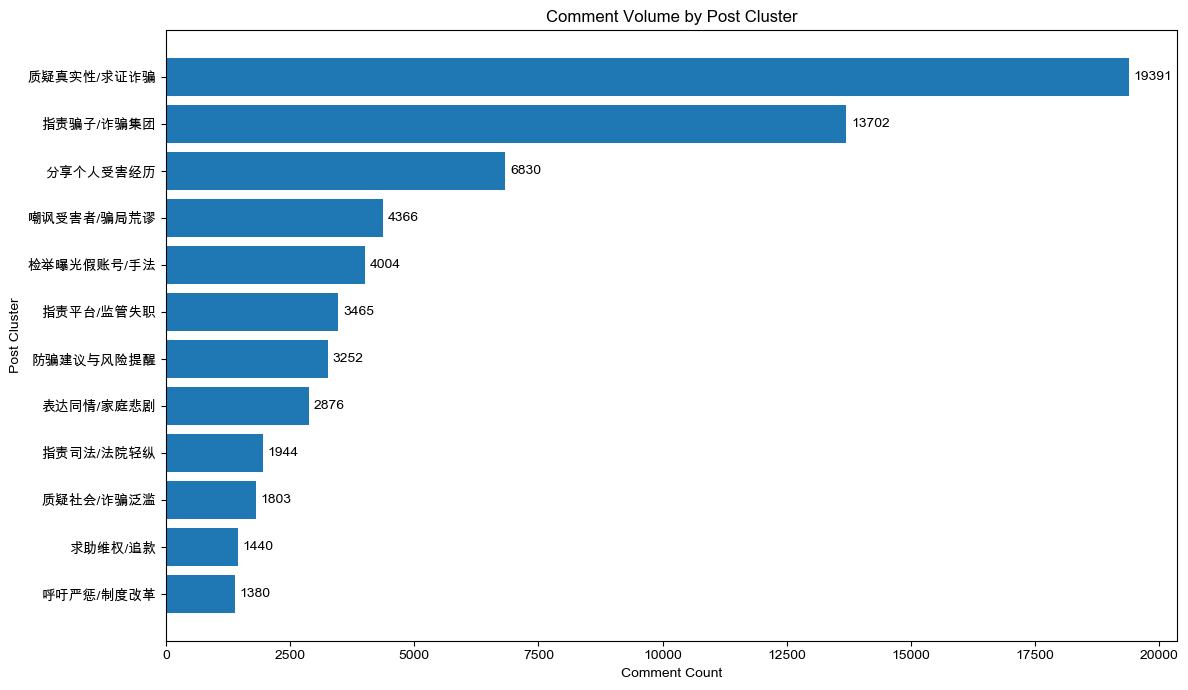

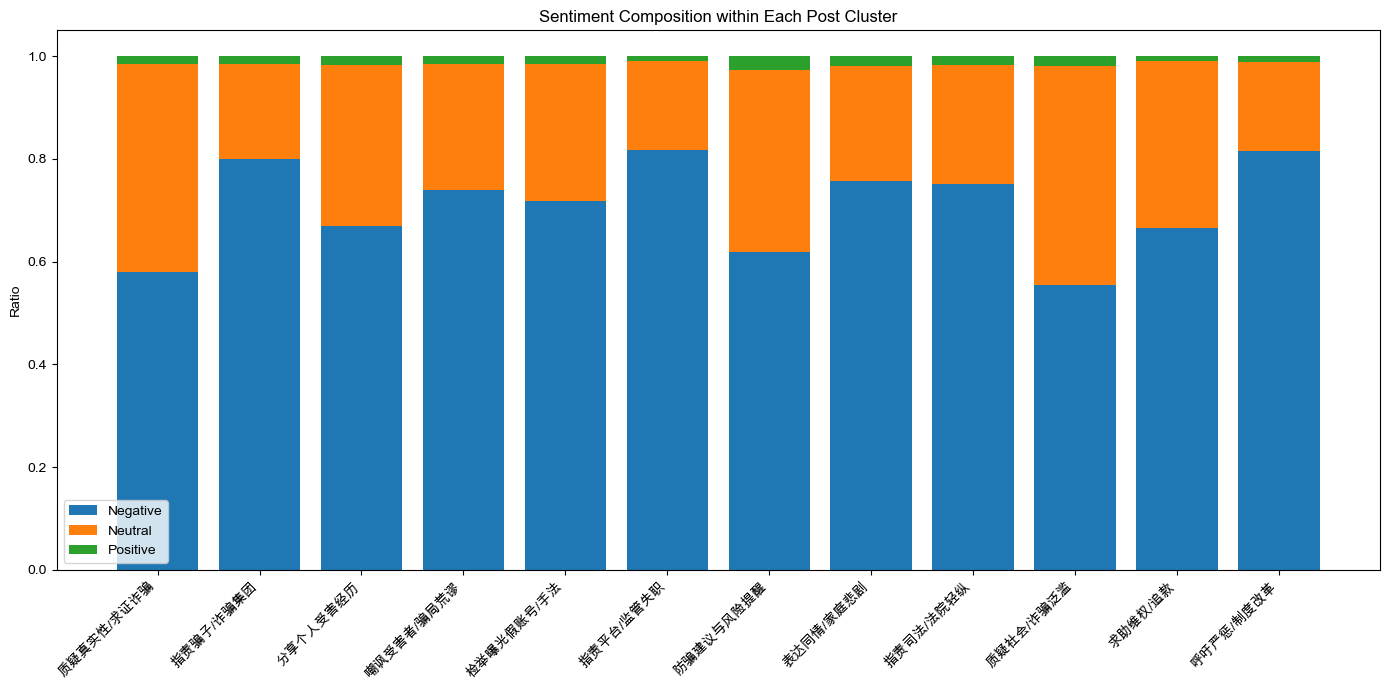

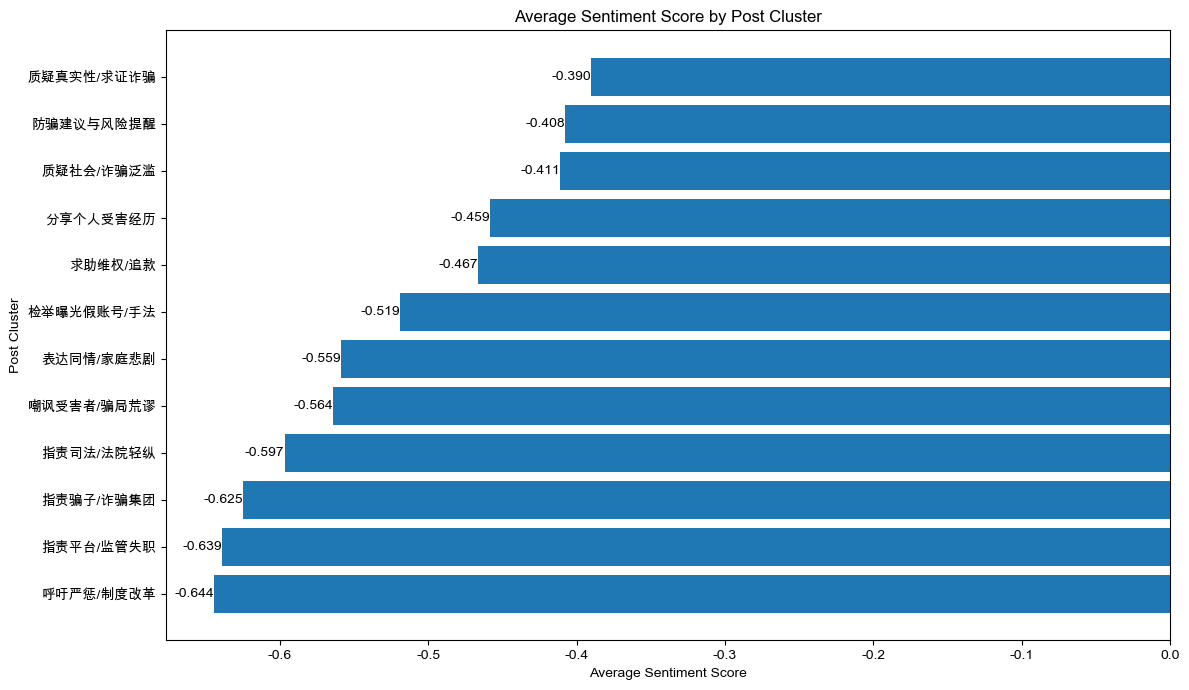

第1部分完成，图片保存在： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_part1


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# =========================
# 1. 路径设置
# =========================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析")
INPUT_FILE = BASE_DIR / "post_cluster_sentiment_summary_core.csv"
OUTPUT_DIR = BASE_DIR / "figures_part1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2. 读数据
# =========================
df = pd.read_csv(INPUT_FILE, low_memory=False)

print("数据大小：", df.shape)
print(df.head())

# 为了图更整齐，按评论数排序
df = df.sort_values("comment_count", ascending=False).copy()

# 字体设置（如果你电脑里有中文字体，一般可以正常显示）
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS", "PingFang HK", "Heiti TC", "SimHei", "Microsoft YaHei"
]
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 图1：post cluster 评论量分布图
# =========================
fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(df["post_cluster_label"], df["comment_count"])
ax.invert_yaxis()
ax.set_xlabel("Comment Count")
ax.set_ylabel("Post Cluster")
ax.set_title("Comment Volume by Post Cluster")

for i, v in enumerate(df["comment_count"]):
    ax.text(v + max(df["comment_count"]) * 0.005, i, f"{int(v)}", va="center")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_post_cluster_comment_count_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 图2：情感结构 100% 堆叠柱状图
# =========================
plot_df = df.copy()

x = np.arange(len(plot_df))
neg = plot_df["negative_ratio"].fillna(0).values
neu = plot_df["neutral_ratio"].fillna(0).values
pos = plot_df["positive_ratio"].fillna(0).values

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(x, neg, label="Negative")
ax.bar(x, neu, bottom=neg, label="Neutral")
ax.bar(x, pos, bottom=neg + neu, label="Positive")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["post_cluster_label"], rotation=45, ha="right")
ax.set_ylabel("Ratio")
ax.set_title("Sentiment Composition within Each Post Cluster")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_post_cluster_sentiment_stacked_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 图3：平均情感分值图
# =========================
avg_df = df.sort_values("avg_sentiment_score", ascending=True).copy()

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(avg_df["post_cluster_label"], avg_df["avg_sentiment_score"])
ax.set_xlabel("Average Sentiment Score")
ax.set_ylabel("Post Cluster")
ax.set_title("Average Sentiment Score by Post Cluster")

for i, v in enumerate(avg_df["avg_sentiment_score"]):
    if pd.notna(v):
        ax.text(v, i, f"{v:.3f}", va="center", ha="left" if v >= 0 else "right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_post_cluster_avg_sentiment_score.png", dpi=300, bbox_inches="tight")
plt.show()

print("第1部分完成，图片保存在：", OUTPUT_DIR)

数据大小： (12, 7)
   post_cluster_id post_cluster_label  comment_count  blame_ratio  \
0              3.0         质疑真实性/求证诈骗          19391     0.459234   
1              1.0          指责骗子/诈骗集团          13702     0.745731   
2              4.0           分享个人受害经历           6830     0.533236   
3              8.0         嘲讽受害者/骗局荒谬           4366     0.642923   
4             11.0         检举曝光假账号/手法           4004     0.637113   

  main_blame_subject main_blame_object main_blame_intensity  
0                 网民             无明确对象                 weak  
1                 网民           诈骗集团/骗徒               strong  
2                 网民             无明确对象                 weak  
3                 网民           诈骗集团/骗徒               strong  
4                 网民           诈骗集团/骗徒               strong  


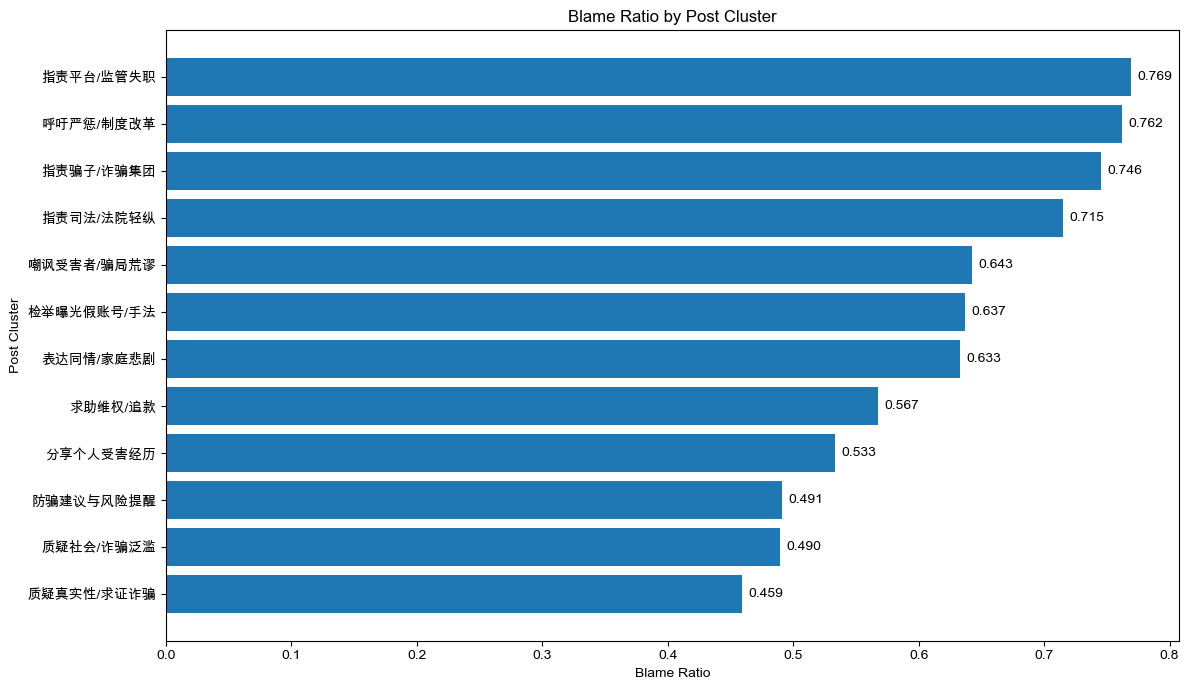

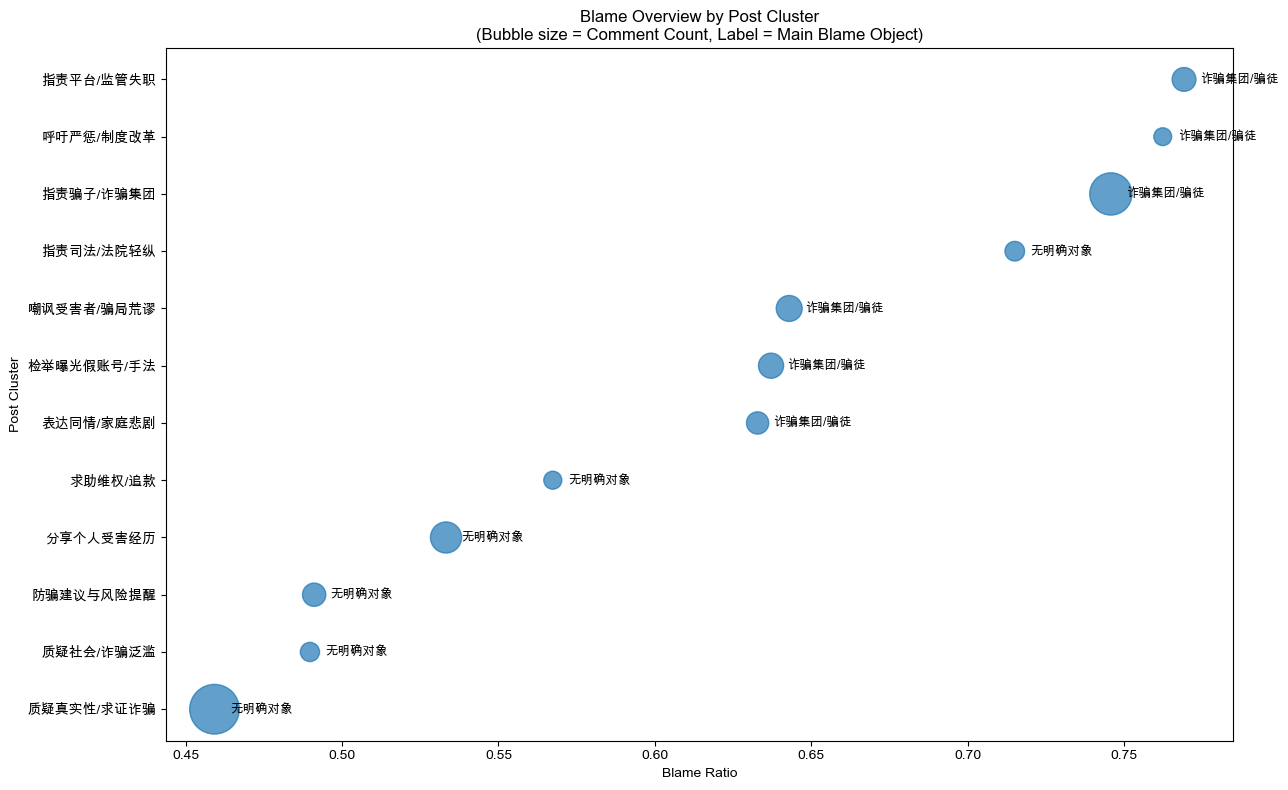

第2部分完成，结果保存在： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_part2


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# =========================
# 1. 路径设置
# =========================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析")
INPUT_FILE = BASE_DIR / "post_cluster_blame_summary_core.csv"
OUTPUT_DIR = BASE_DIR / "figures_part2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2. 读数据
# =========================
df = pd.read_csv(INPUT_FILE, low_memory=False)

print("数据大小：", df.shape)
print(df.head())

# 字体设置
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS", "PingFang HK", "Heiti TC", "SimHei", "Microsoft YaHei"
]
plt.rcParams["axes.unicode_minus"] = False

# 数值列处理
df["comment_count"] = pd.to_numeric(df["comment_count"], errors="coerce")
df["blame_ratio"] = pd.to_numeric(df["blame_ratio"], errors="coerce")

# 文本列处理
for col in ["main_blame_subject", "main_blame_object", "main_blame_intensity"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str).str.strip()

# =========================
# 图4：blame_ratio 横向柱状图
# =========================
plot_df = df.sort_values("blame_ratio", ascending=False).copy()

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(plot_df["post_cluster_label"], plot_df["blame_ratio"])
ax.invert_yaxis()
ax.set_xlabel("Blame Ratio")
ax.set_ylabel("Post Cluster")
ax.set_title("Blame Ratio by Post Cluster")

for i, v in enumerate(plot_df["blame_ratio"]):
    if pd.notna(v):
        ax.text(v + 0.005, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_post_cluster_blame_ratio_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 图5：blame 概览散点图
# x = blame_ratio
# y = post_cluster_label
# 点大小 = comment_count
# 标注 = main_blame_object
# =========================
scatter_df = df.sort_values("blame_ratio", ascending=True).copy()

# 为了让点大小不要差太夸张，这里做一个缩放
size_base = scatter_df["comment_count"].fillna(0)
size_scaled = (size_base / size_base.max()) * 1200 + 80

fig, ax = plt.subplots(figsize=(13, 8))

y_pos = np.arange(len(scatter_df))

ax.scatter(
    scatter_df["blame_ratio"],
    y_pos,
    s=size_scaled,
    alpha=0.7
)

ax.set_yticks(y_pos)
ax.set_yticklabels(scatter_df["post_cluster_label"])
ax.set_xlabel("Blame Ratio")
ax.set_ylabel("Post Cluster")
ax.set_title("Blame Overview by Post Cluster\n(Bubble size = Comment Count, Label = Main Blame Object)")

# 标注 main_blame_object
for i, row in scatter_df.reset_index(drop=True).iterrows():
    label = row.get("main_blame_object", "")
    if label == "" or label.lower() in ["nan", "none", "null"]:
        label = "无明显对象"
    ax.text(row["blame_ratio"] + 0.005, i, label, va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_post_cluster_blame_overview_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 附加输出：导出一个更适合查看的 blame 概览表
# =========================
out_df = df[
    [
        "post_cluster_id",
        "post_cluster_label",
        "comment_count",
        "blame_ratio",
        "main_blame_subject",
        "main_blame_object",
        "main_blame_intensity"
    ]
].sort_values("blame_ratio", ascending=False)

out_df.to_csv(OUTPUT_DIR / "05_post_cluster_blame_overview_table.csv",
              index=False, encoding="utf-8-sig")

print("第2部分完成，结果保存在：", OUTPUT_DIR)

pivot_df: (12, 15)
dist_df: (151, 7)


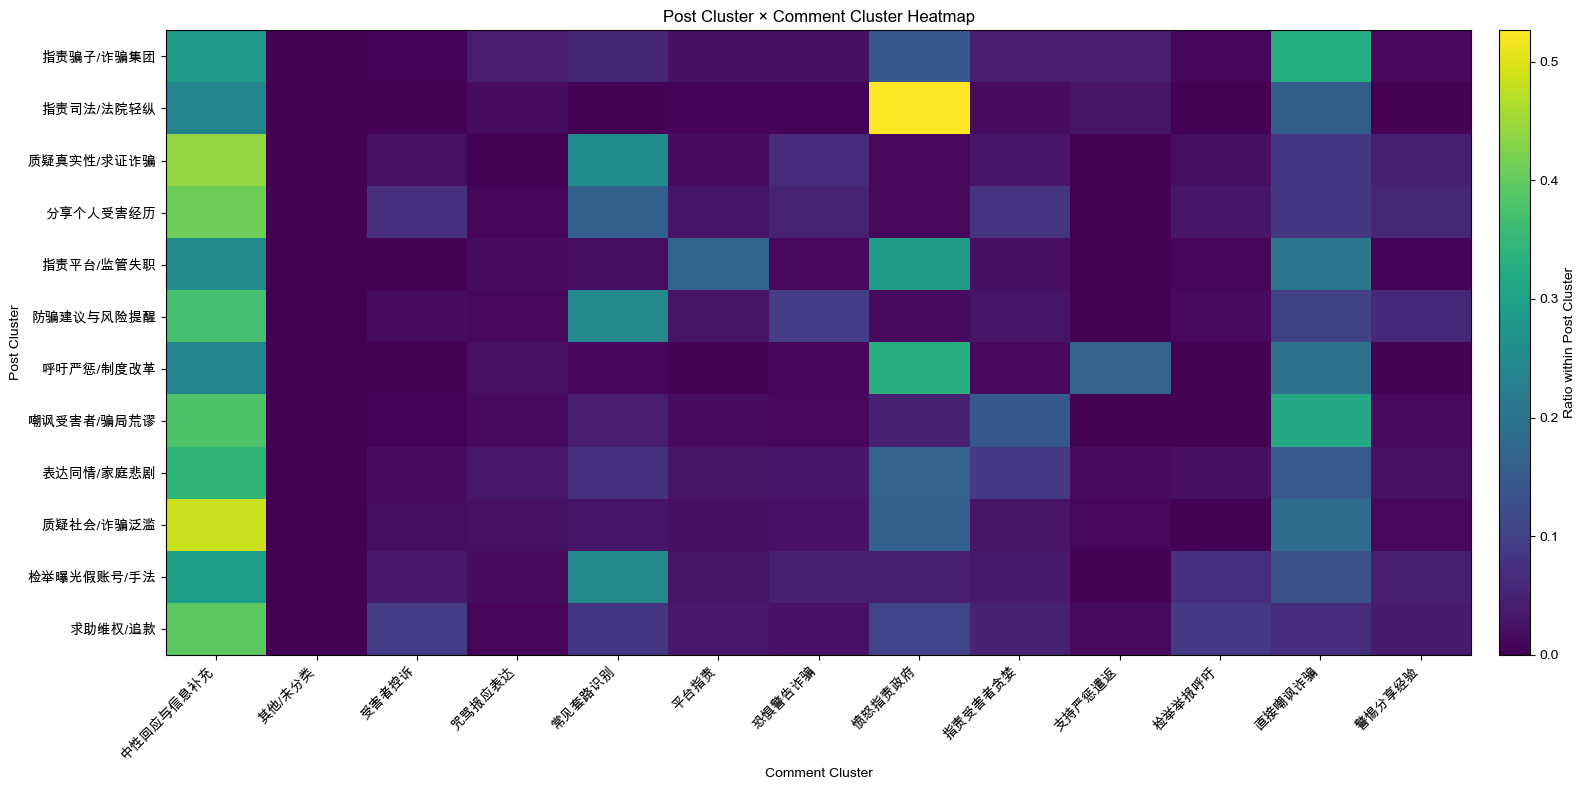

总体 Top 8 comment cluster:
['中性回应与信息补充', '直接嘲讽诈骗', '常见套路识别', '愤怒指责政府', '指责受害者贪婪', '恐惧警告诈骗', '警惕分享经验', '平台指责']


/var/folders/sf/mgyxhhk10sqcwjy1dtft4gm80000gn/T/ipykernel_11449/3151085701.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stack_pivot.index, rotation=45, ha="right")


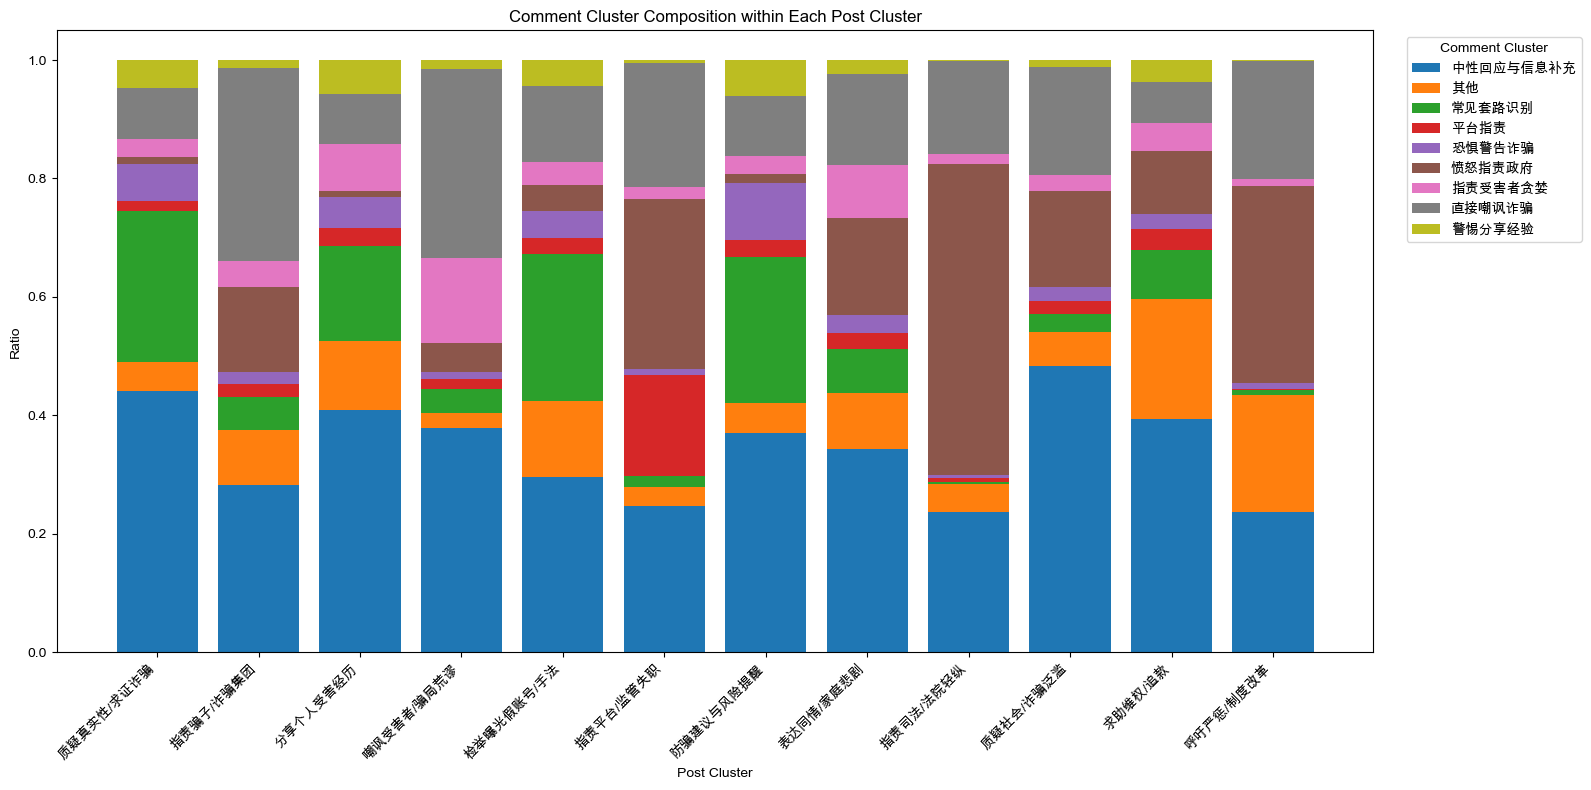

第3部分完成，图片保存在： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_part3


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# =========================
# 1. 路径设置
# =========================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析")

PIVOT_FILE = BASE_DIR / "post_comment_cluster_pivot_core.csv"
DIST_FILE = BASE_DIR / "post_comment_cluster_distribution_core.csv"

OUTPUT_DIR = BASE_DIR / "figures_part3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2. 字体设置
# =========================
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS", "PingFang HK", "Heiti TC", "SimHei", "Microsoft YaHei"
]
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 3. 读取数据
# =========================
pivot_df = pd.read_csv(PIVOT_FILE, low_memory=False)
dist_df = pd.read_csv(DIST_FILE, low_memory=False)

print("pivot_df:", pivot_df.shape)
print("dist_df:", dist_df.shape)

# =====================================================
# 图6：post cluster × comment cluster 热力图
# 用表：post_comment_cluster_pivot_core.csv
# =====================================================
heat_df = pivot_df.copy()

# 行标签
row_labels = heat_df["post_cluster_label"].tolist()

# 去掉索引列，只保留数值矩阵
value_df = heat_df.drop(columns=["post_cluster_id", "post_cluster_label"], errors="ignore").copy()

fig, ax = plt.subplots(figsize=(16, 8))

im = ax.imshow(value_df.values, aspect="auto")

ax.set_xticks(np.arange(value_df.shape[1]))
ax.set_xticklabels(value_df.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels)

ax.set_title("Post Cluster × Comment Cluster Heatmap")
ax.set_xlabel("Comment Cluster")
ax.set_ylabel("Post Cluster")

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Ratio within Post Cluster")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_post_comment_cluster_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# 图7：100% 堆叠柱状图
# 用表：post_comment_cluster_distribution_core.csv
# =====================================================
# 先找总体 top 8 的 comment cluster，避免图太乱
top_comment_clusters = (
    dist_df.groupby("comment_cluster_label", as_index=False)["comment_count"]
    .sum()
    .sort_values("comment_count", ascending=False)
    .head(8)["comment_cluster_label"]
    .tolist()
)

print("总体 Top 8 comment cluster:")
print(top_comment_clusters)

plot_df = dist_df.copy()

# 不在 top8 的合并成“其他”
plot_df["comment_cluster_grouped"] = np.where(
    plot_df["comment_cluster_label"].isin(top_comment_clusters),
    plot_df["comment_cluster_label"],
    "其他"
)

# 汇总
stack_df = (
    plot_df.groupby(["post_cluster_label", "comment_cluster_grouped"], as_index=False)
    ["comment_count"].sum()
)

# 每个 post cluster 内部转成比例
stack_df["total_in_post_cluster"] = stack_df.groupby("post_cluster_label")["comment_count"].transform("sum")
stack_df["ratio"] = stack_df["comment_count"] / stack_df["total_in_post_cluster"]

# 透视成画图格式
stack_pivot = stack_df.pivot_table(
    index="post_cluster_label",
    columns="comment_cluster_grouped",
    values="ratio",
    fill_value=0
)

# 为了让顺序更稳定，按总评论量排序
post_order = (
    dist_df.groupby("post_cluster_label", as_index=False)["comment_count"]
    .sum()
    .sort_values("comment_count", ascending=False)["post_cluster_label"]
    .tolist()
)

stack_pivot = stack_pivot.reindex(post_order)

fig, ax = plt.subplots(figsize=(16, 8))

bottom = np.zeros(len(stack_pivot))

for col in stack_pivot.columns:
    vals = stack_pivot[col].values
    ax.bar(stack_pivot.index, vals, bottom=bottom, label=col)
    bottom += vals

ax.set_ylabel("Ratio")
ax.set_xlabel("Post Cluster")
ax.set_title("Comment Cluster Composition within Each Post Cluster")
ax.set_xticklabels(stack_pivot.index, rotation=45, ha="right")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Comment Cluster")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_post_comment_cluster_stacked_bar.png", dpi=300, bbox_inches="tight")
plt.show()

print("第3部分完成，图片保存在：", OUTPUT_DIR)

In [5]:
import pandas as pd
from pathlib import Path

# =========================
# 1. 路径设置
# =========================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析")
INPUT_FILE = BASE_DIR / "post_comment_cluster_distribution_core.csv"
OUTPUT_DIR = BASE_DIR / "figures_part4"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2. 读取数据
# =========================
df = pd.read_csv(INPUT_FILE, low_memory=False)

print("数据大小：", df.shape)
print(df.head())

# 数值列处理
df["comment_count"] = pd.to_numeric(df["comment_count"], errors="coerce")
df["ratio_within_post_cluster"] = pd.to_numeric(df["ratio_within_post_cluster"], errors="coerce")

# =========================
# 3. 每个 post cluster 取 top3 comment cluster
# =========================
top3_df = df.sort_values(
    ["post_cluster_label", "ratio_within_post_cluster"],
    ascending=[True, False]
).copy()

top3_df["rank_within_post_cluster"] = (
    top3_df.groupby("post_cluster_label")["ratio_within_post_cluster"]
    .rank(method="first", ascending=False)
)

top3_df = top3_df[top3_df["rank_within_post_cluster"] <= 3].copy()

top3_out = top3_df[
    [
        "post_cluster_id",
        "post_cluster_label",
        "comment_cluster_id",
        "comment_cluster_label",
        "comment_count",
        "ratio_within_post_cluster",
        "rank_within_post_cluster"
    ]
].sort_values(["post_cluster_id", "rank_within_post_cluster"])

# 保存长表
top3_out.to_csv(
    OUTPUT_DIR / "09_top3_comment_clusters_within_each_post_cluster.csv",
    index=False,
    encoding="utf-8-sig"
)

# =========================
# 4. 再做一个宽表，更适合直接看
# =========================
wide_rows = []

for post_label, sub in top3_out.groupby("post_cluster_label"):
    sub = sub.sort_values("rank_within_post_cluster")
    row = {"post_cluster_label": post_label}
    for _, r in sub.iterrows():
        rk = int(r["rank_within_post_cluster"])
        row[f"top{rk}_comment_cluster"] = r["comment_cluster_label"]
        row[f"top{rk}_count"] = r["comment_count"]
        row[f"top{rk}_ratio"] = r["ratio_within_post_cluster"]
    wide_rows.append(row)

wide_df = pd.DataFrame(wide_rows)

wide_df.to_csv(
    OUTPUT_DIR / "09_top3_comment_clusters_within_each_post_cluster_wide.csv",
    index=False,
    encoding="utf-8-sig"
)

print("第4部分完成，输出文件：")
print(OUTPUT_DIR / "09_top3_comment_clusters_within_each_post_cluster.csv")
print(OUTPUT_DIR / "09_top3_comment_clusters_within_each_post_cluster_wide.csv")

数据大小： (151, 7)
   post_cluster_id post_cluster_label  comment_cluster_id  \
0              1.0          指责骗子/诈骗集团                 1.0   
1              1.0          指责骗子/诈骗集团                11.0   
2              1.0          指责骗子/诈骗集团                 2.0   
3              1.0          指责骗子/诈骗集团                 9.0   
4              1.0          指责骗子/诈骗集团                 4.0   

  comment_cluster_label  comment_count  total_comments_in_post_cluster  \
0                直接嘲讽诈骗           4470                           13702   
1             中性回应与信息补充           3864                           13702   
2                愤怒指责政府           1968                           13702   
3                常见套路识别            751                           13702   
4               指责受害者贪婪            582                           13702   

   ratio_within_post_cluster  
0                   0.326230  
1                   0.282003  
2                   0.143629  
3                   0.054810  
4                 

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
import plotly.graph_objects as go

# =========================
# 1. 路径设置
# =========================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析")
INPUT_FILE = BASE_DIR / "post_comment_cluster_distribution_core.csv"
OUTPUT_DIR = BASE_DIR / "figures_part5"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2. 读取数据
# =========================
df = pd.read_csv(INPUT_FILE, low_memory=False)

print("数据大小：", df.shape)
print(df.head())

df["comment_count"] = pd.to_numeric(df["comment_count"], errors="coerce").fillna(0)

# =========================
# 3. 只保留总体 top 8 comment cluster，其余合并成“其他”
# =========================
top_comment_clusters = (
    df.groupby("comment_cluster_label", as_index=False)["comment_count"]
    .sum()
    .sort_values("comment_count", ascending=False)
    .head(8)["comment_cluster_label"]
    .tolist()
)

print("总体 top 8 comment cluster:")
print(top_comment_clusters)

plot_df = df.copy()
plot_df["comment_cluster_grouped"] = np.where(
    plot_df["comment_cluster_label"].isin(top_comment_clusters),
    plot_df["comment_cluster_label"],
    "其他"
)

sankey_df = (
    plot_df.groupby(["post_cluster_label", "comment_cluster_grouped"], as_index=False)
    ["comment_count"].sum()
)

# =========================
# 4. 构造 sankey 节点
# =========================
post_nodes = ["POST | " + x for x in sankey_df["post_cluster_label"].drop_duplicates().tolist()]
comment_nodes = ["COMMENT | " + x for x in sankey_df["comment_cluster_grouped"].drop_duplicates().tolist()]

all_nodes = post_nodes + comment_nodes
node_to_idx = {name: i for i, name in enumerate(all_nodes)}

# 构造 source / target / value
sources = []
targets = []
values = []

for _, row in sankey_df.iterrows():
    s = "POST | " + row["post_cluster_label"]
    t = "COMMENT | " + row["comment_cluster_grouped"]
    v = row["comment_count"]

    sources.append(node_to_idx[s])
    targets.append(node_to_idx[t])
    values.append(v)

# =========================
# 5. 画 sankey
# =========================
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=18,
        thickness=20,
        line=dict(width=0.5),
        label=all_nodes
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

fig.update_layout(
    title_text="Sankey Diagram: Post Cluster → Comment Cluster",
    font_size=11,
    width=1300,
    height=800
)

# 保存 html
out_file = OUTPUT_DIR / "10_post_to_comment_sankey.html"
fig.write_html(str(out_file))

print("第5部分完成，Sankey 图已保存：")
print(out_file)

数据大小： (151, 7)
   post_cluster_id post_cluster_label  comment_cluster_id  \
0              1.0          指责骗子/诈骗集团                 1.0   
1              1.0          指责骗子/诈骗集团                11.0   
2              1.0          指责骗子/诈骗集团                 2.0   
3              1.0          指责骗子/诈骗集团                 9.0   
4              1.0          指责骗子/诈骗集团                 4.0   

  comment_cluster_label  comment_count  total_comments_in_post_cluster  \
0                直接嘲讽诈骗           4470                           13702   
1             中性回应与信息补充           3864                           13702   
2                愤怒指责政府           1968                           13702   
3                常见套路识别            751                           13702   
4               指责受害者贪婪            582                           13702   

   ratio_within_post_cluster  
0                   0.326230  
1                   0.282003  
2                   0.143629  
3                   0.054810  
4                 

数据大小： (64453, 16)
                           comment_id                              post_id  \
0  COMMENT_20251104094852914_5efff9b7  FACEBOOK_20251104094852848_4a2c859c   
1  COMMENT_20251104094852916_12cb912c  FACEBOOK_20251104094852848_4a2c859c   
2  COMMENT_20251104094853227_e03ffd90  FACEBOOK_20251104094853168_147c15de   
3  COMMENT_20251104094853228_4f0e34b3  FACEBOOK_20251104094853168_147c15de   
4  COMMENT_20251104094853307_597137b3  FACEBOOK_20251104094853246_e42e602f   

   post_cluster_id post_cluster_label  post_cluster_matched  \
0              3.0         质疑真实性/求证诈骗                  True   
1              3.0         质疑真实性/求证诈骗                  True   
2              3.0         质疑真实性/求证诈骗                  True   
3              3.0         质疑真实性/求证诈骗                  True   
4              6.0          防骗建议与风险提醒                  True   

   comment_cluster_id comment_cluster_label  \
0                 4.0               指责受害者贪婪   
1                 4.0               指责受害

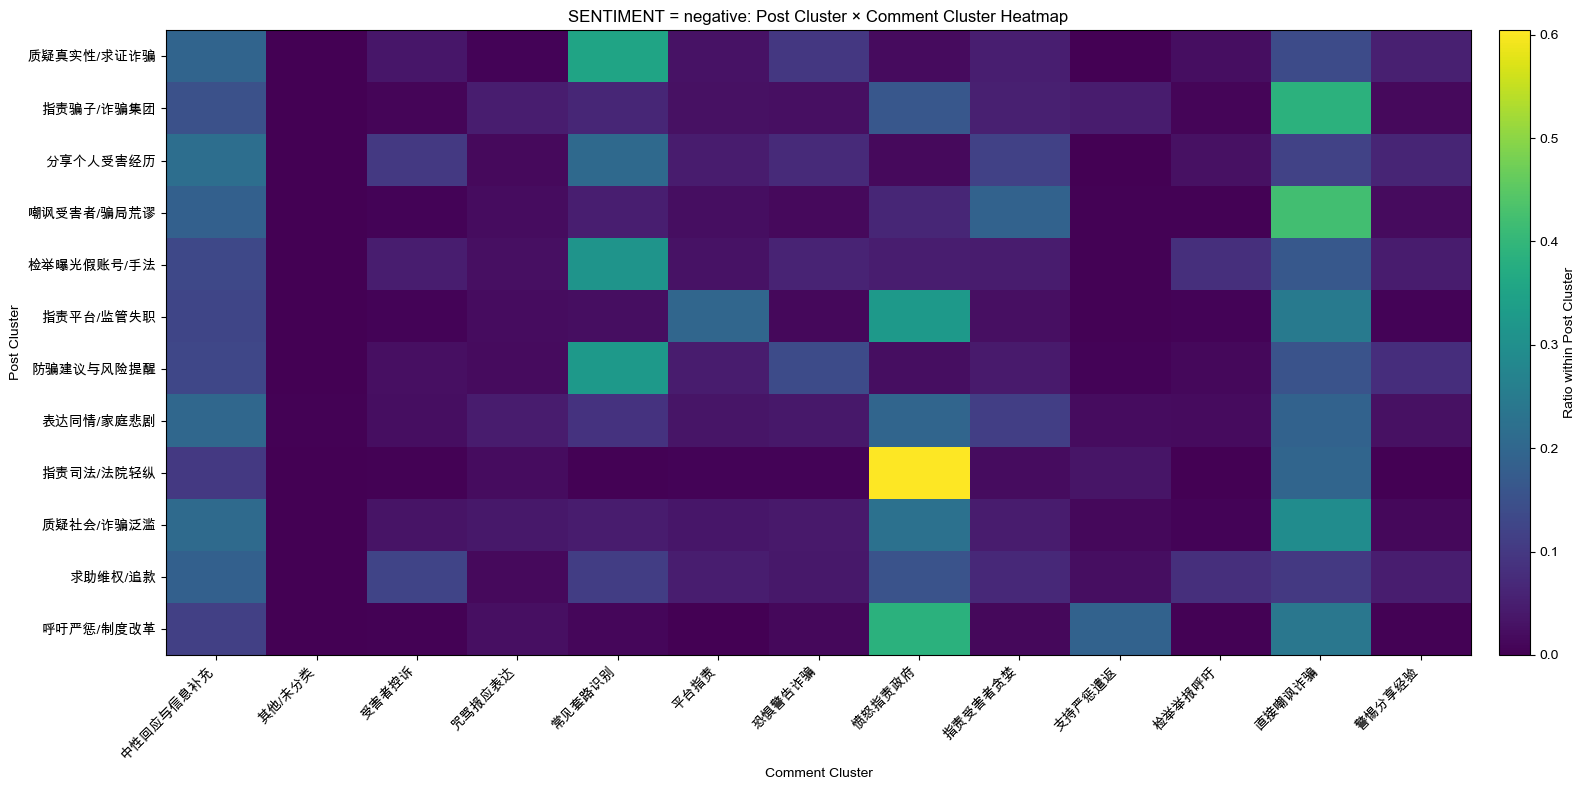

已完成：sentiment = negative


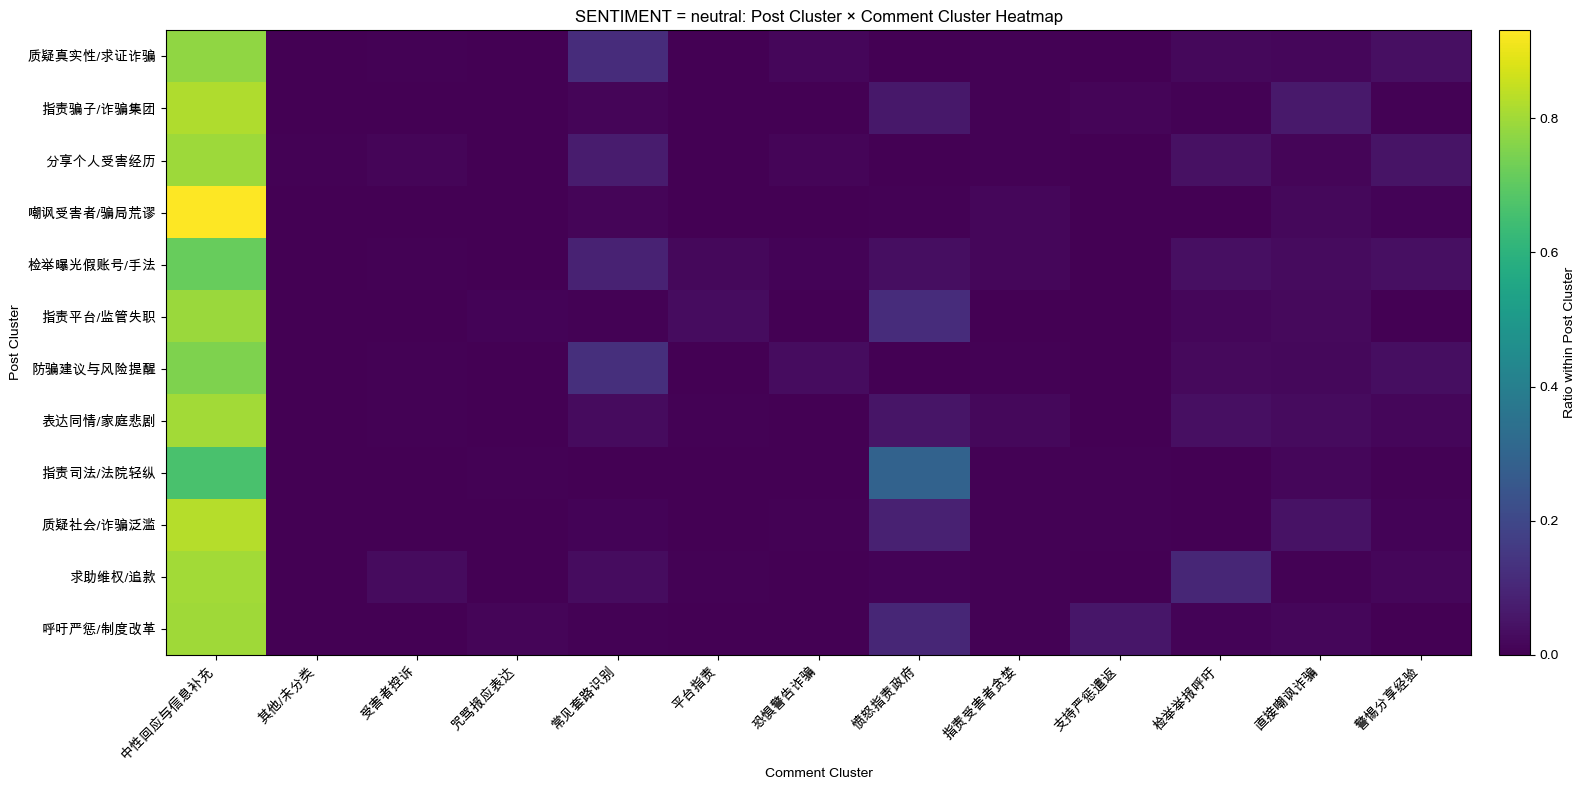

已完成：sentiment = neutral


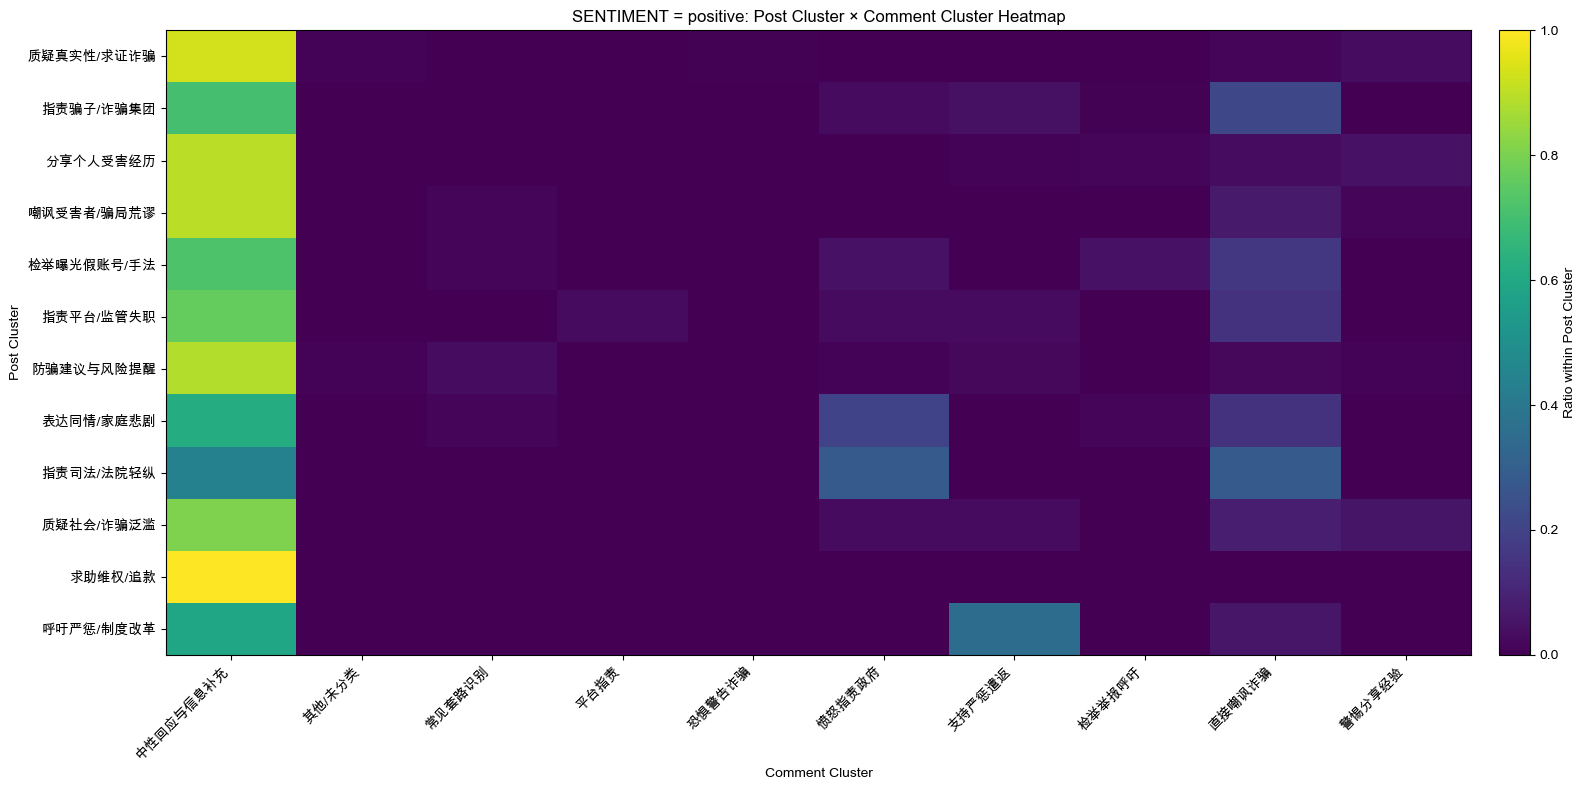

已完成：sentiment = positive


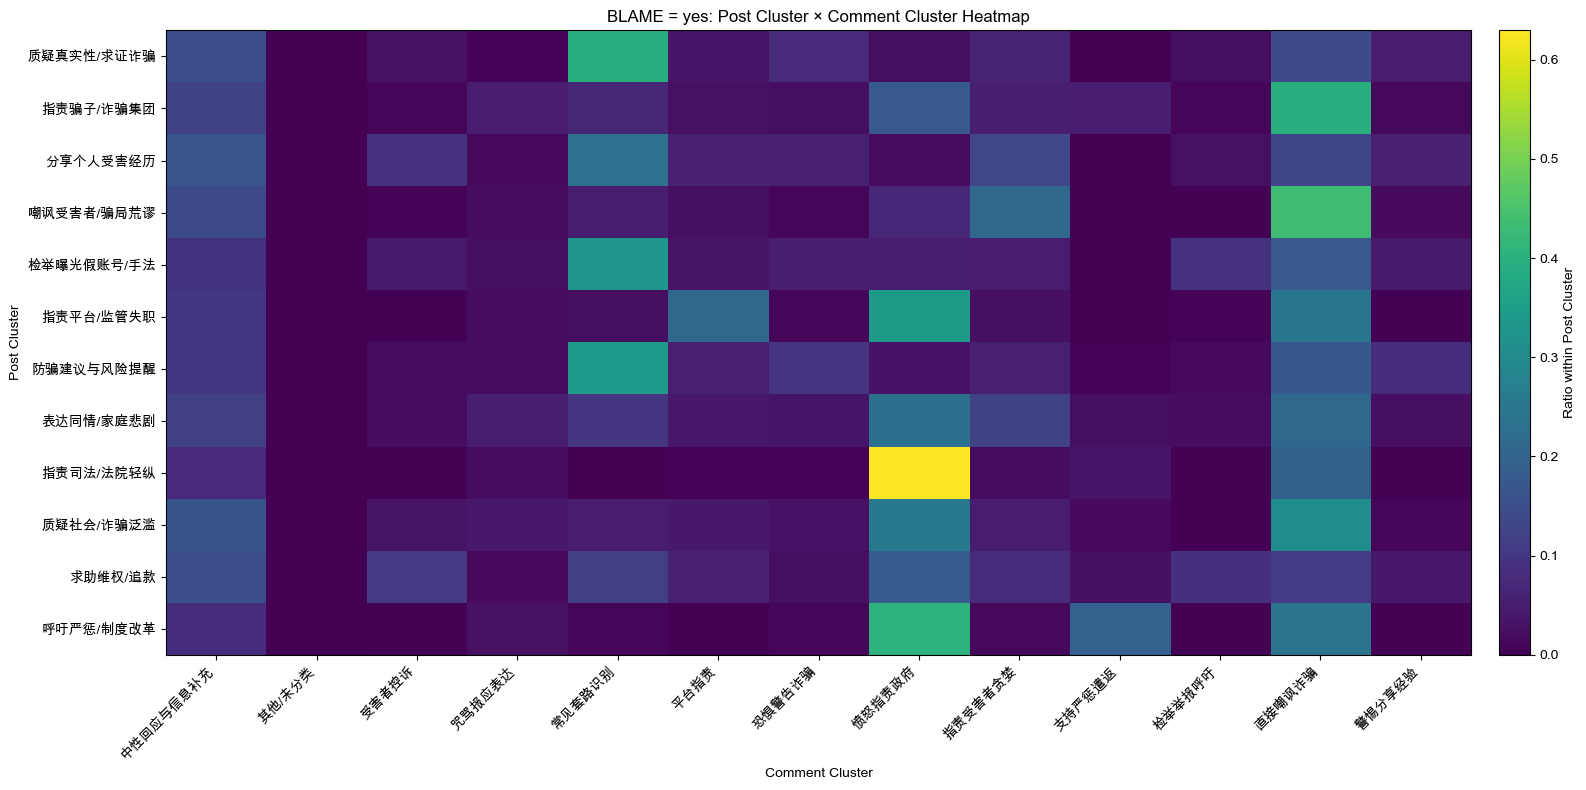

已完成：blame = yes


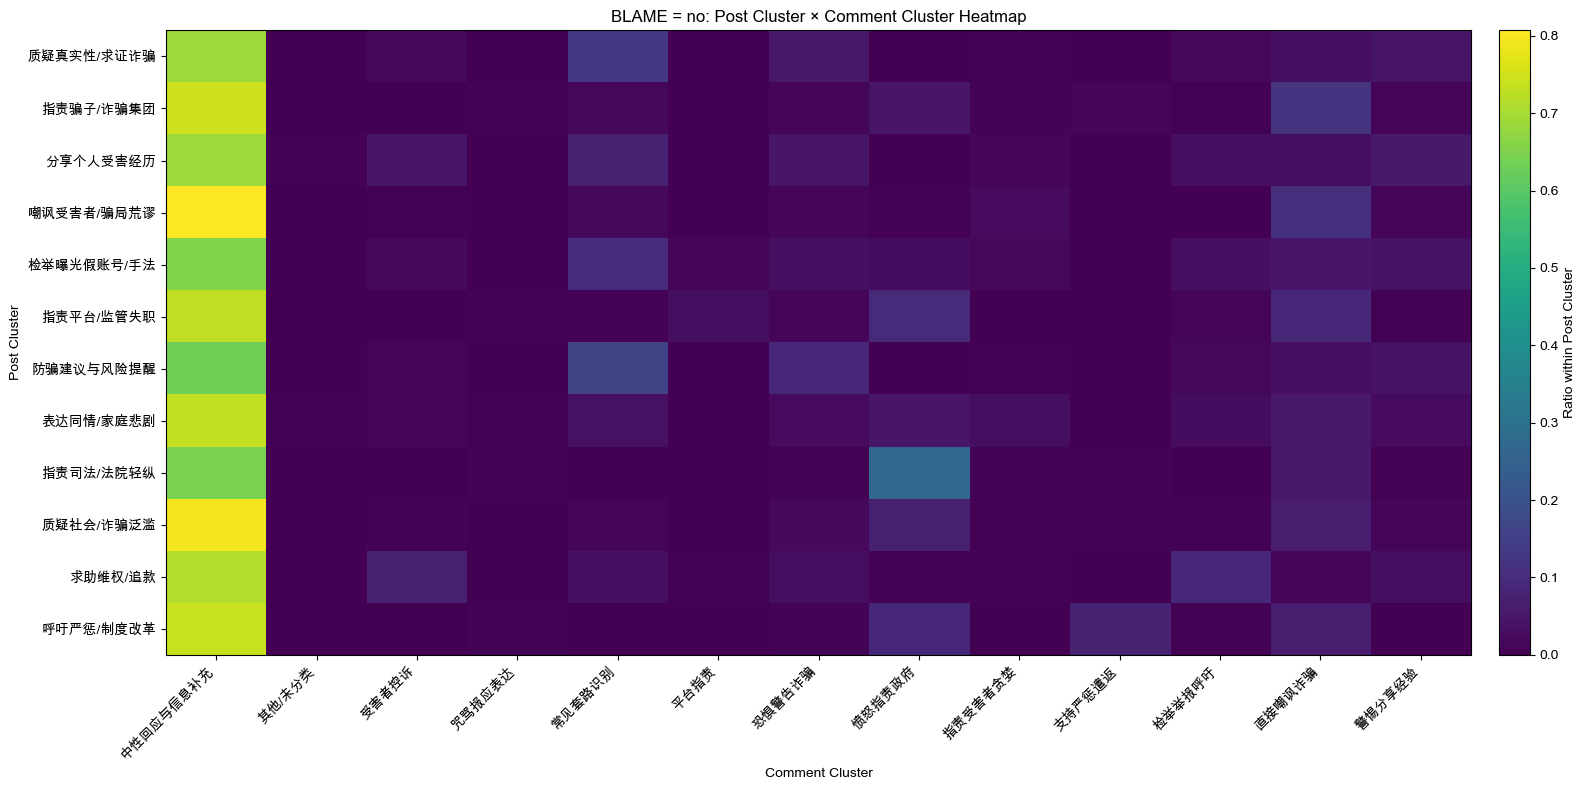

已完成：blame = no
第6部分完成，输出保存在： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_part6


In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# =========================
# 1. 路径设置
# =========================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析")
INPUT_FILE = BASE_DIR / "topic_merged_final_core_only.csv"
OUTPUT_DIR = BASE_DIR / "figures_part6"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2. 读取数据
# =========================
df = pd.read_csv(INPUT_FILE, low_memory=False)

print("数据大小：", df.shape)
print(df.head())

# 字体设置
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS", "PingFang HK", "Heiti TC", "SimHei", "Microsoft YaHei"
]
plt.rcParams["axes.unicode_minus"] = False

# 基本清洗
for col in ["post_cluster_label", "comment_cluster_label", "sentiment_category", "has_blame"]:
    df[col] = df[col].astype(str).str.strip()

# 统一排序顺序：按 post cluster 总 comment 数排序
post_order = (
    df.groupby("post_cluster_label", as_index=False)["comment_id"]
    .count()
    .sort_values("comment_id", ascending=False)["post_cluster_label"]
    .tolist()
)

# =========================
# 3. 定义一个通用函数：
# 某个分组变量下，画 post × comment 热力图
# =========================
def make_split_heatmaps(data, split_col, split_values, prefix):
    for val in split_values:
        sub = data[data[split_col] == val].copy()

        if sub.empty:
            print(f"{split_col}={val} 无数据，跳过")
            continue

        # 分布表
        dist = (
            sub.groupby(["post_cluster_label", "comment_cluster_label"], as_index=False)
            ["comment_id"].count()
            .rename(columns={"comment_id": "comment_count"})
        )

        # 每个 post cluster 内部比例
        dist["total_in_post_cluster"] = dist.groupby("post_cluster_label")["comment_count"].transform("sum")
        dist["ratio_within_post_cluster"] = dist["comment_count"] / dist["total_in_post_cluster"]

        dist.to_csv(
            OUTPUT_DIR / f"{prefix}_{val}_distribution.csv",
            index=False,
            encoding="utf-8-sig"
        )

        # pivot 做热力图
        pivot = dist.pivot_table(
            index="post_cluster_label",
            columns="comment_cluster_label",
            values="ratio_within_post_cluster",
            fill_value=0
        )

        # 按统一顺序重排
        pivot = pivot.reindex([x for x in post_order if x in pivot.index])

        pivot.to_csv(
            OUTPUT_DIR / f"{prefix}_{val}_pivot.csv",
            encoding="utf-8-sig"
        )

        # 画热力图
        fig, ax = plt.subplots(figsize=(16, 8))
        im = ax.imshow(pivot.values, aspect="auto")

        ax.set_xticks(np.arange(pivot.shape[1]))
        ax.set_xticklabels(pivot.columns, rotation=45, ha="right")

        ax.set_yticks(np.arange(pivot.shape[0]))
        ax.set_yticklabels(pivot.index)

        ax.set_title(f"{prefix.upper()} = {val}: Post Cluster × Comment Cluster Heatmap")
        ax.set_xlabel("Comment Cluster")
        ax.set_ylabel("Post Cluster")

        cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
        cbar.set_label("Ratio within Post Cluster")

        plt.tight_layout()
        plt.savefig(
            OUTPUT_DIR / f"{prefix}_{val}_heatmap.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

        print(f"已完成：{prefix} = {val}")

# =========================
# 4. 按 sentiment 拆分
# =========================
sentiment_values = ["negative", "neutral", "positive"]
make_split_heatmaps(
    data=df,
    split_col="sentiment_category",
    split_values=sentiment_values,
    prefix="sentiment"
)

# =========================
# 5. 按 blame 拆分
# =========================
blame_values = ["yes", "no"]
make_split_heatmaps(
    data=df,
    split_col="has_blame",
    split_values=blame_values,
    prefix="blame"
)

print("第6部分完成，输出保存在：", OUTPUT_DIR)

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析")

PIVOT_FILE = BASE_DIR / "post_comment_cluster_pivot_core.csv"
DIST_FILE = BASE_DIR / "post_comment_cluster_distribution_core.csv"
MERGED_FILE = BASE_DIR / "topic_merged_final_core_only.csv"

plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS", "PingFang HK", "Heiti TC", "SimHei", "Microsoft YaHei"
]
plt.rcParams["axes.unicode_minus"] = False

print("准备完成")

准备完成


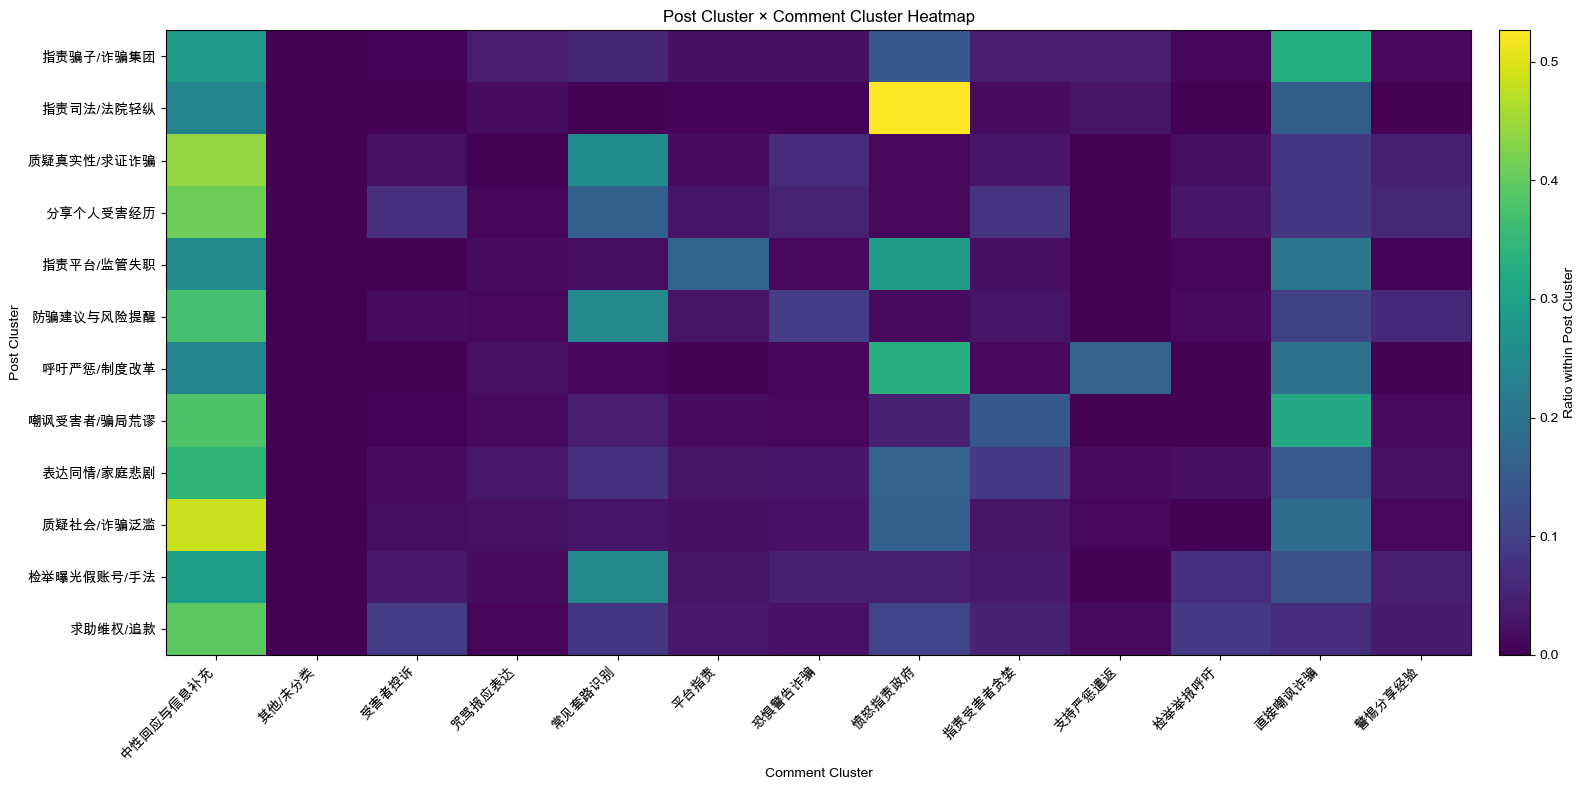

已保存： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_post_comment/01_post_comment_heatmap.png


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pivot_df = pd.read_csv(PIVOT_FILE, low_memory=False)

OUTPUT_DIR = BASE_DIR / "figures_post_comment"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 行标签
row_labels = pivot_df["post_cluster_label"].tolist()

# 去掉索引列，只保留数值矩阵
value_df = pivot_df.drop(columns=["post_cluster_id", "post_cluster_label"], errors="ignore").copy()

fig, ax = plt.subplots(figsize=(16, 8))

im = ax.imshow(value_df.values, aspect="auto")

ax.set_xticks(np.arange(value_df.shape[1]))
ax.set_xticklabels(value_df.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels)

ax.set_title("Post Cluster × Comment Cluster Heatmap")
ax.set_xlabel("Comment Cluster")
ax.set_ylabel("Post Cluster")

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Ratio within Post Cluster")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_post_comment_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("已保存：", OUTPUT_DIR / "01_post_comment_heatmap.png")

总体 Top 8 comment cluster:
['中性回应与信息补充', '直接嘲讽诈骗', '常见套路识别', '愤怒指责政府', '指责受害者贪婪', '恐惧警告诈骗', '警惕分享经验', '平台指责']


/var/folders/sf/mgyxhhk10sqcwjy1dtft4gm80000gn/T/ipykernel_11449/1154710187.py:67: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



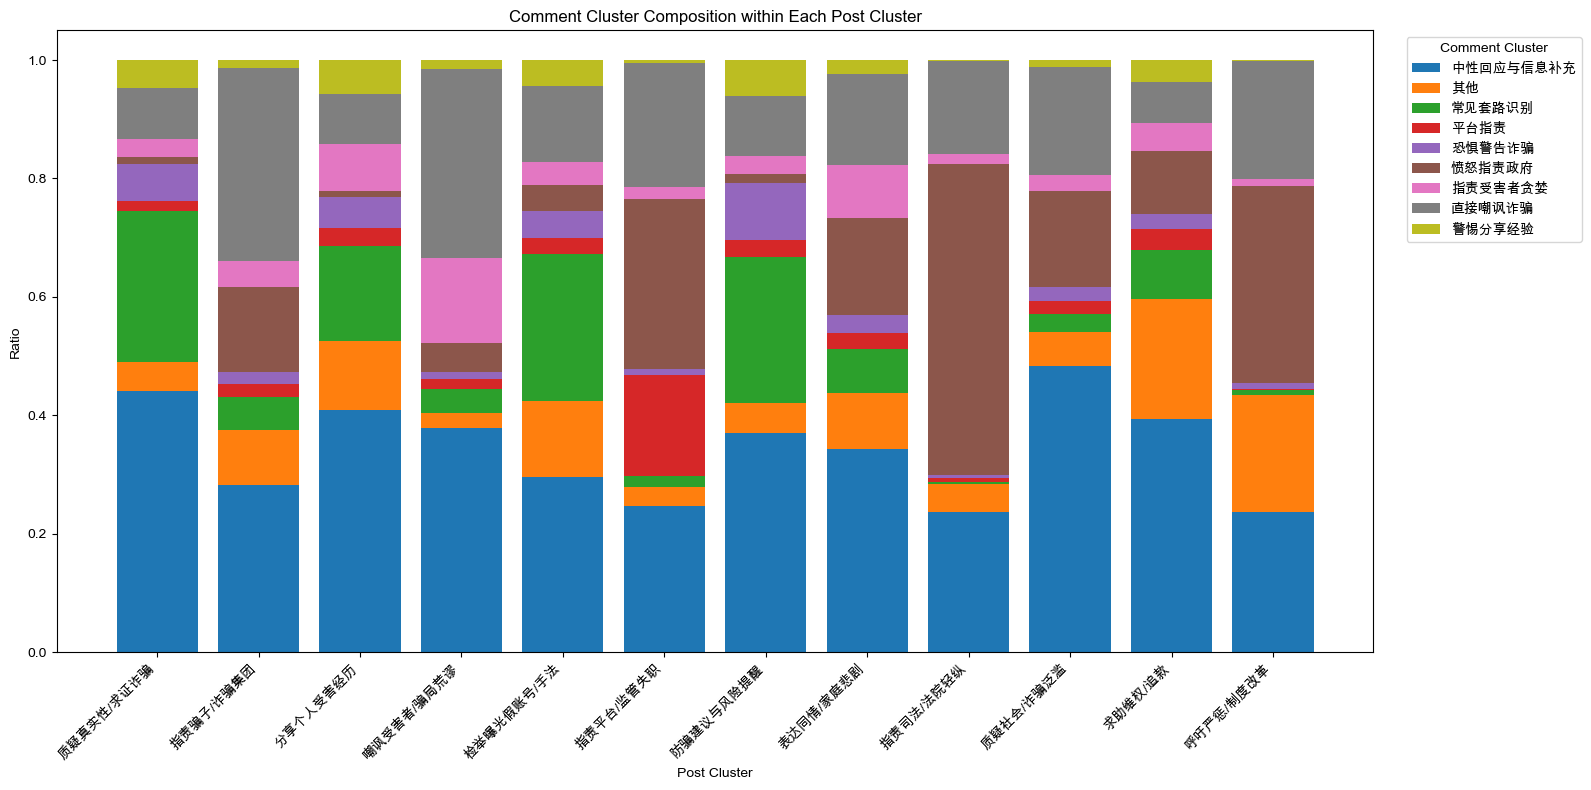

已保存： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_post_comment/02_post_comment_stacked_bar.png


In [10]:
dist_df = pd.read_csv(DIST_FILE, low_memory=False)

OUTPUT_DIR = BASE_DIR / "figures_post_comment"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

dist_df["comment_count"] = pd.to_numeric(dist_df["comment_count"], errors="coerce").fillna(0)

# 只保留总体 top 8 comment cluster，其他合并成“其他”
top_comment_clusters = (
    dist_df.groupby("comment_cluster_label", as_index=False)["comment_count"]
    .sum()
    .sort_values("comment_count", ascending=False)
    .head(8)["comment_cluster_label"]
    .tolist()
)

print("总体 Top 8 comment cluster:")
print(top_comment_clusters)

plot_df = dist_df.copy()
plot_df["comment_cluster_grouped"] = np.where(
    plot_df["comment_cluster_label"].isin(top_comment_clusters),
    plot_df["comment_cluster_label"],
    "其他"
)

# 汇总
stack_df = (
    plot_df.groupby(["post_cluster_label", "comment_cluster_grouped"], as_index=False)["comment_count"]
    .sum()
)

# 每个 post cluster 内部占比
stack_df["total_in_post_cluster"] = stack_df.groupby("post_cluster_label")["comment_count"].transform("sum")
stack_df["ratio"] = stack_df["comment_count"] / stack_df["total_in_post_cluster"]

# 透视
stack_pivot = stack_df.pivot_table(
    index="post_cluster_label",
    columns="comment_cluster_grouped",
    values="ratio",
    fill_value=0
)

# 按总评论量排序
post_order = (
    dist_df.groupby("post_cluster_label", as_index=False)["comment_count"]
    .sum()
    .sort_values("comment_count", ascending=False)["post_cluster_label"]
    .tolist()
)

stack_pivot = stack_pivot.reindex(post_order)

fig, ax = plt.subplots(figsize=(16, 8))

bottom = np.zeros(len(stack_pivot))

for col in stack_pivot.columns:
    vals = stack_pivot[col].values
    ax.bar(stack_pivot.index, vals, bottom=bottom, label=col)
    bottom += vals

ax.set_ylabel("Ratio")
ax.set_xlabel("Post Cluster")
ax.set_title("Comment Cluster Composition within Each Post Cluster")
ax.set_xticklabels(stack_pivot.index, rotation=45, ha="right")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Comment Cluster")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_post_comment_stacked_bar.png", dpi=300, bbox_inches="tight")
plt.show()

print("已保存：", OUTPUT_DIR / "02_post_comment_stacked_bar.png")

In [11]:
import plotly.graph_objects as go

dist_df = pd.read_csv(DIST_FILE, low_memory=False)

OUTPUT_DIR = BASE_DIR / "figures_post_comment"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

dist_df["comment_count"] = pd.to_numeric(dist_df["comment_count"], errors="coerce").fillna(0)

# 只保留总体 top 8 的 comment cluster，其他合并成“其他”
top_comment_clusters = (
    dist_df.groupby("comment_cluster_label", as_index=False)["comment_count"]
    .sum()
    .sort_values("comment_count", ascending=False)
    .head(8)["comment_cluster_label"]
    .tolist()
)

plot_df = dist_df.copy()
plot_df["comment_cluster_grouped"] = np.where(
    plot_df["comment_cluster_label"].isin(top_comment_clusters),
    plot_df["comment_cluster_label"],
    "其他"
)

sankey_df = (
    plot_df.groupby(["post_cluster_label", "comment_cluster_grouped"], as_index=False)["comment_count"]
    .sum()
)

# 节点
post_nodes = ["POST | " + x for x in sankey_df["post_cluster_label"].drop_duplicates().tolist()]
comment_nodes = ["COMMENT | " + x for x in sankey_df["comment_cluster_grouped"].drop_duplicates().tolist()]

all_nodes = post_nodes + comment_nodes
node_to_idx = {name: i for i, name in enumerate(all_nodes)}

sources = []
targets = []
values = []

for _, row in sankey_df.iterrows():
    s = "POST | " + row["post_cluster_label"]
    t = "COMMENT | " + row["comment_cluster_grouped"]
    v = row["comment_count"]

    sources.append(node_to_idx[s])
    targets.append(node_to_idx[t])
    values.append(v)

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=18,
        thickness=20,
        line=dict(width=0.5),
        label=all_nodes
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

fig.update_layout(
    title_text="Sankey Diagram: Post Cluster → Comment Cluster",
    font_size=11,
    width=1300,
    height=800
)

out_file = OUTPUT_DIR / "03_post_to_comment_sankey.html"
fig.write_html(str(out_file))

print("已保存：", out_file)

已保存： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_post_comment/03_post_to_comment_sankey.html


In [12]:
dist_df = pd.read_csv(DIST_FILE, low_memory=False)

OUTPUT_DIR = BASE_DIR / "figures_post_comment"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

dist_df["comment_count"] = pd.to_numeric(dist_df["comment_count"], errors="coerce")
dist_df["ratio_within_post_cluster"] = pd.to_numeric(dist_df["ratio_within_post_cluster"], errors="coerce")

top3_df = dist_df.sort_values(
    ["post_cluster_label", "ratio_within_post_cluster"],
    ascending=[True, False]
).copy()

top3_df["rank_within_post_cluster"] = (
    top3_df.groupby("post_cluster_label")["ratio_within_post_cluster"]
    .rank(method="first", ascending=False)
)

top3_df = top3_df[top3_df["rank_within_post_cluster"] <= 3].copy()

top3_out = top3_df[
    [
        "post_cluster_id",
        "post_cluster_label",
        "comment_cluster_id",
        "comment_cluster_label",
        "comment_count",
        "ratio_within_post_cluster",
        "rank_within_post_cluster"
    ]
].sort_values(["post_cluster_id", "rank_within_post_cluster"])

top3_out.to_csv(
    OUTPUT_DIR / "04_top3_comment_clusters_long.csv",
    index=False,
    encoding="utf-8-sig"
)

# 做宽表
wide_rows = []

for post_label, sub in top3_out.groupby("post_cluster_label"):
    sub = sub.sort_values("rank_within_post_cluster")
    row = {"post_cluster_label": post_label}
    for _, r in sub.iterrows():
        rk = int(r["rank_within_post_cluster"])
        row[f"top{rk}_comment_cluster"] = r["comment_cluster_label"]
        row[f"top{rk}_count"] = r["comment_count"]
        row[f"top{rk}_ratio"] = r["ratio_within_post_cluster"]
    wide_rows.append(row)

wide_df = pd.DataFrame(wide_rows)

wide_df.to_csv(
    OUTPUT_DIR / "04_top3_comment_clusters_wide.csv",
    index=False,
    encoding="utf-8-sig"
)

print("已保存：")
print(OUTPUT_DIR / "04_top3_comment_clusters_long.csv")
print(OUTPUT_DIR / "04_top3_comment_clusters_wide.csv")

已保存：
/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_post_comment/04_top3_comment_clusters_long.csv
/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_post_comment/04_top3_comment_clusters_wide.csv


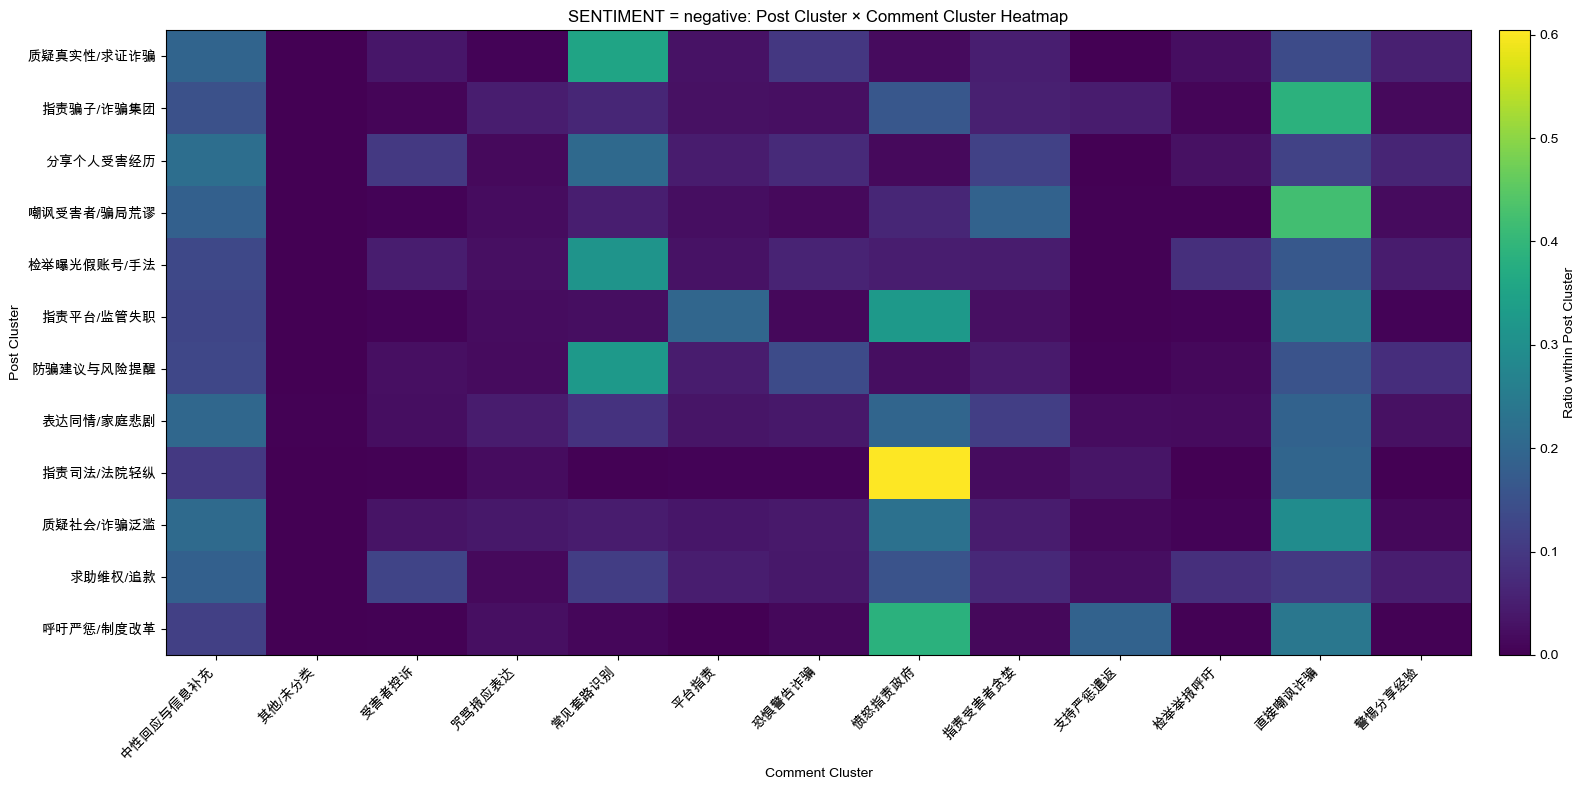

已完成：sentiment = negative


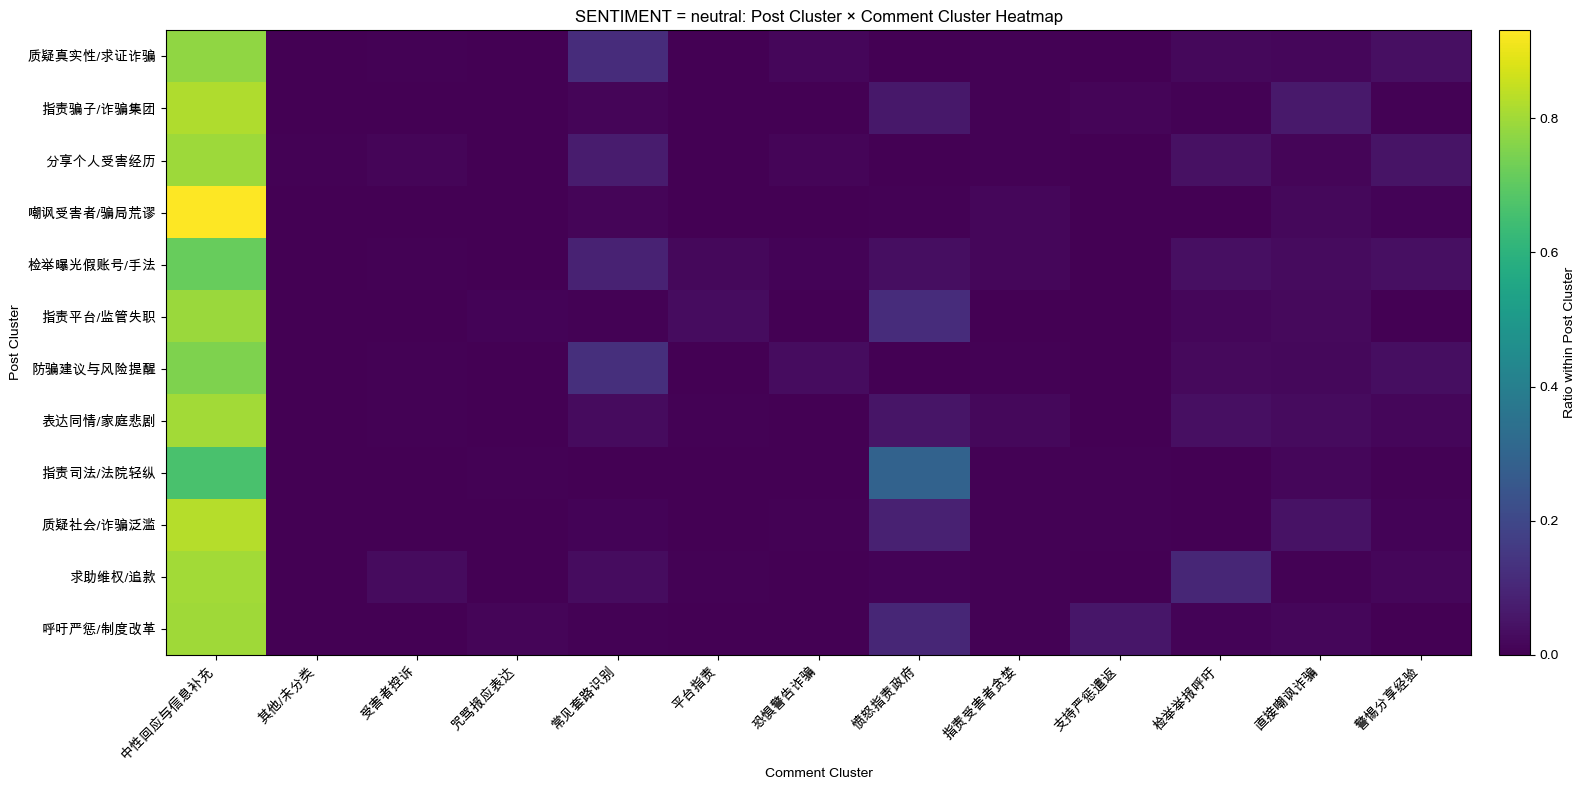

已完成：sentiment = neutral


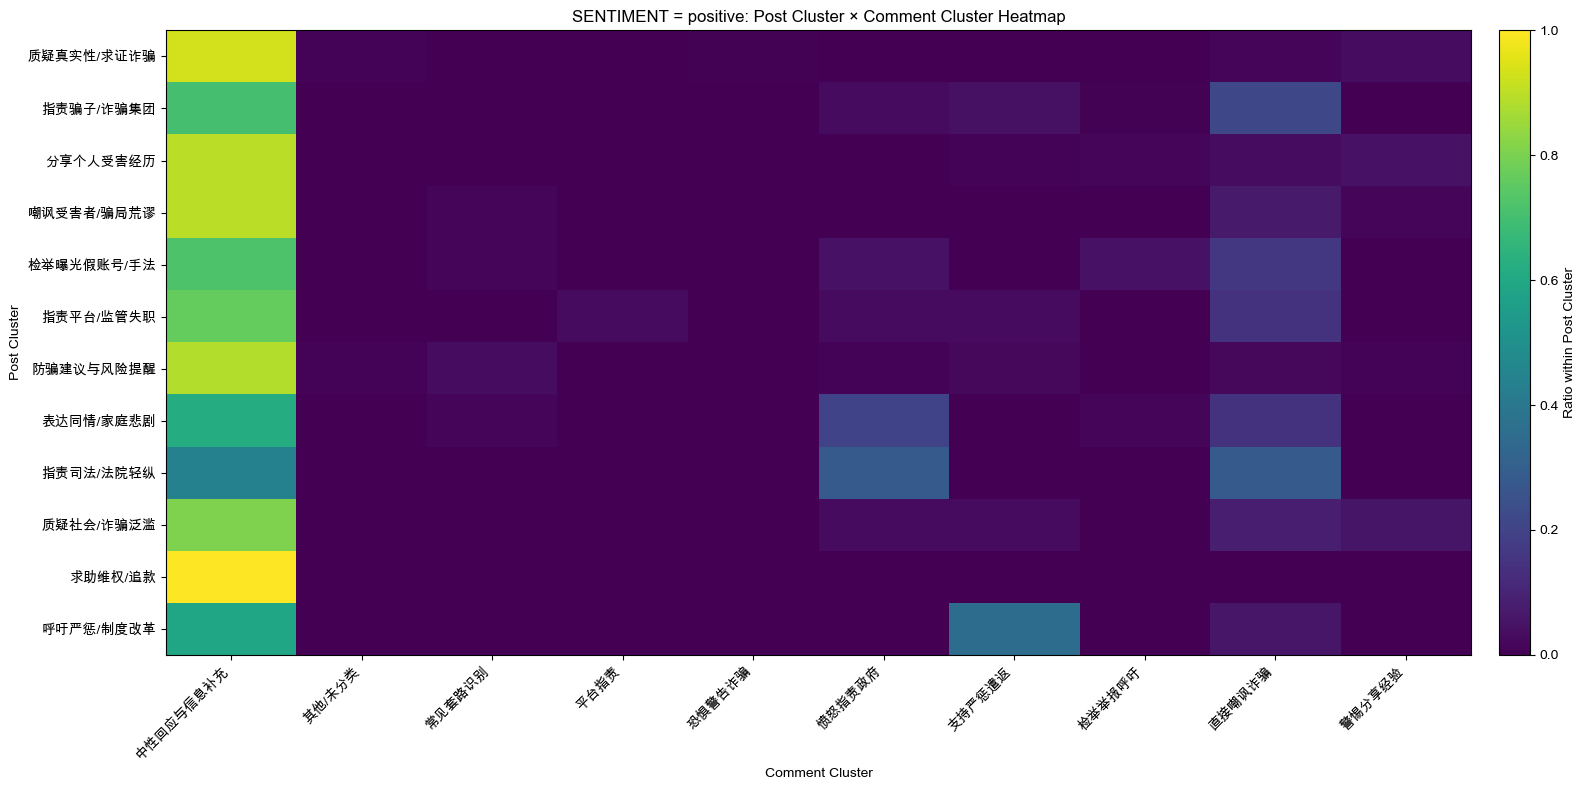

已完成：sentiment = positive


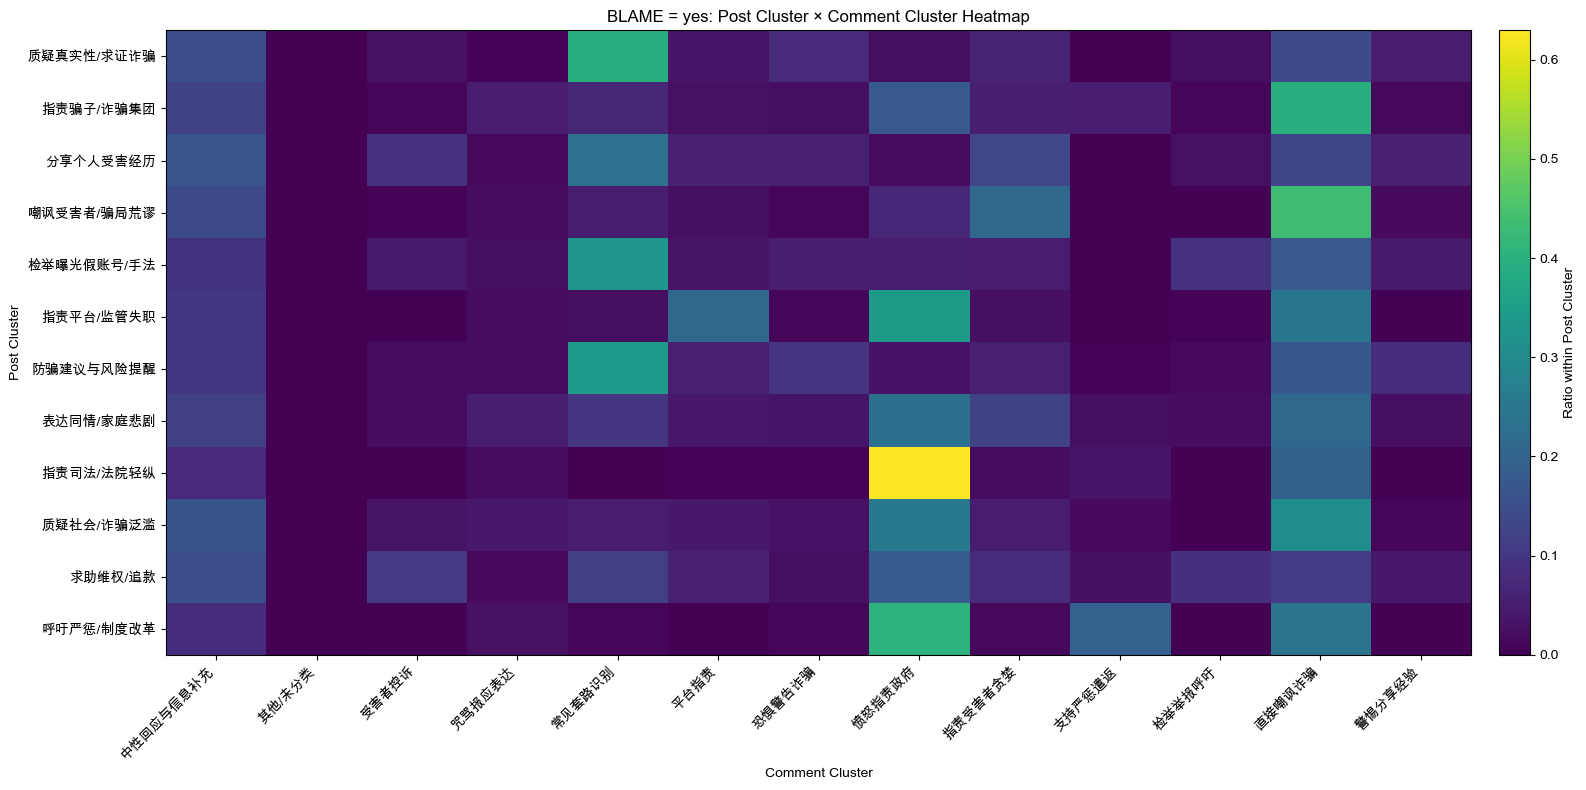

已完成：blame = yes


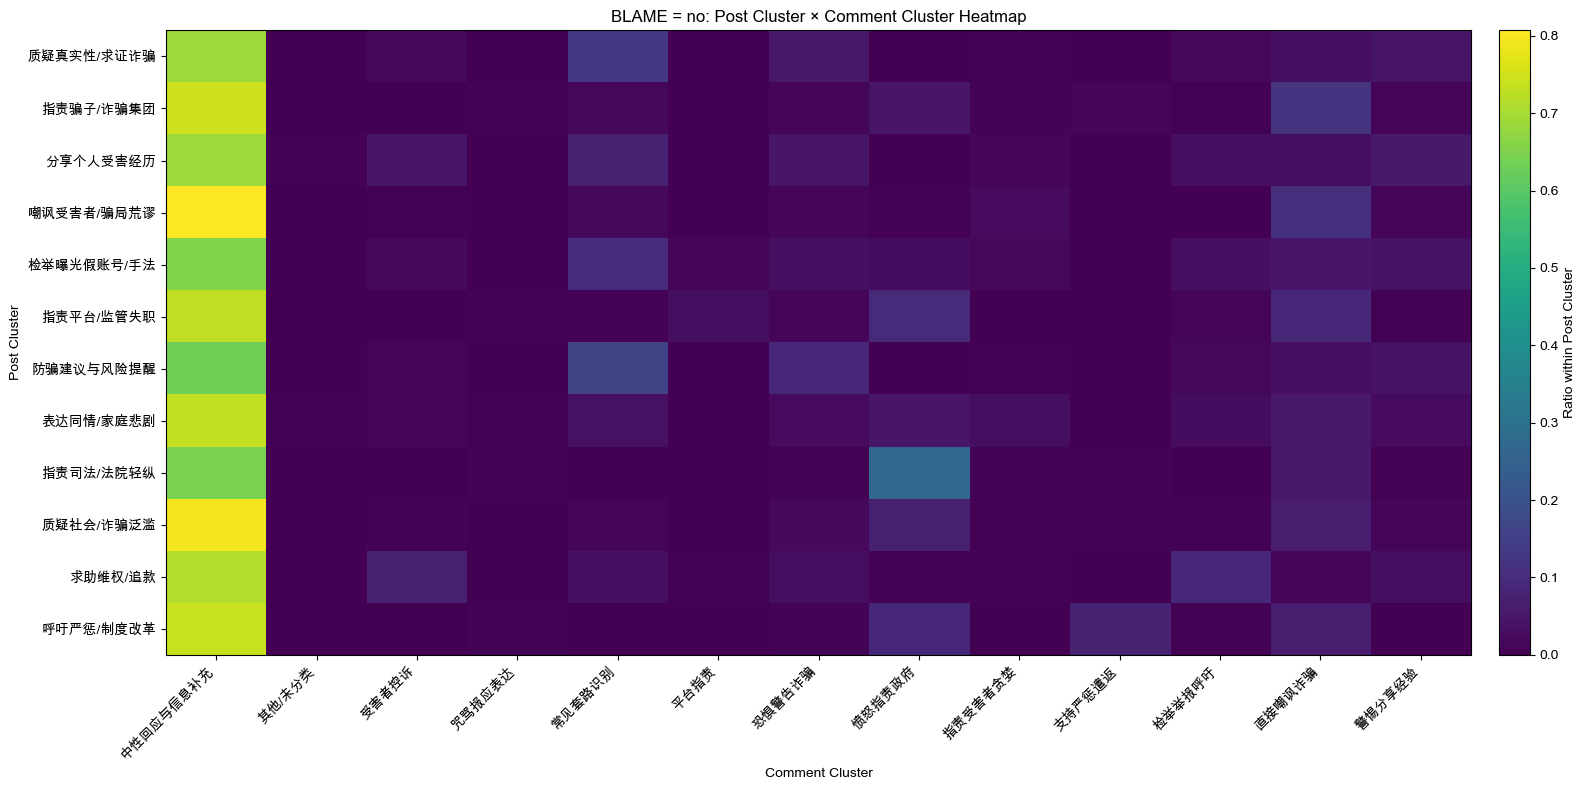

已完成：blame = no
已完成，输出目录： /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_post_comment_split


In [13]:
merged_df = pd.read_csv(MERGED_FILE, low_memory=False)

OUTPUT_DIR = BASE_DIR / "figures_post_comment_split"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for col in ["post_cluster_label", "comment_cluster_label", "sentiment_category", "has_blame"]:
    merged_df[col] = merged_df[col].astype(str).str.strip()

# 统一 post 排序
post_order = (
    merged_df.groupby("post_cluster_label", as_index=False)["comment_id"]
    .count()
    .sort_values("comment_id", ascending=False)["post_cluster_label"]
    .tolist()
)

def make_split_heatmaps(data, split_col, split_values, prefix):
    for val in split_values:
        sub = data[data[split_col] == val].copy()

        if sub.empty:
            print(f"{split_col}={val} 无数据，跳过")
            continue

        dist = (
            sub.groupby(["post_cluster_label", "comment_cluster_label"], as_index=False)["comment_id"]
            .count()
            .rename(columns={"comment_id": "comment_count"})
        )

        dist["total_in_post_cluster"] = dist.groupby("post_cluster_label")["comment_count"].transform("sum")
        dist["ratio_within_post_cluster"] = dist["comment_count"] / dist["total_in_post_cluster"]

        dist.to_csv(
            OUTPUT_DIR / f"{prefix}_{val}_distribution.csv",
            index=False,
            encoding="utf-8-sig"
        )

        pivot = dist.pivot_table(
            index="post_cluster_label",
            columns="comment_cluster_label",
            values="ratio_within_post_cluster",
            fill_value=0
        )

        pivot = pivot.reindex([x for x in post_order if x in pivot.index])

        pivot.to_csv(
            OUTPUT_DIR / f"{prefix}_{val}_pivot.csv",
            encoding="utf-8-sig"
        )

        fig, ax = plt.subplots(figsize=(16, 8))
        im = ax.imshow(pivot.values, aspect="auto")

        ax.set_xticks(np.arange(pivot.shape[1]))
        ax.set_xticklabels(pivot.columns, rotation=45, ha="right")

        ax.set_yticks(np.arange(pivot.shape[0]))
        ax.set_yticklabels(pivot.index)

        ax.set_title(f"{prefix.upper()} = {val}: Post Cluster × Comment Cluster Heatmap")
        ax.set_xlabel("Comment Cluster")
        ax.set_ylabel("Post Cluster")

        cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
        cbar.set_label("Ratio within Post Cluster")

        plt.tight_layout()
        plt.savefig(
            OUTPUT_DIR / f"{prefix}_{val}_heatmap.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

        print(f"已完成：{prefix} = {val}")

# 按 sentiment
make_split_heatmaps(
    data=merged_df,
    split_col="sentiment_category",
    split_values=["negative", "neutral", "positive"],
    prefix="sentiment"
)

# 按 blame
make_split_heatmaps(
    data=merged_df,
    split_col="has_blame",
    split_values=["yes", "no"],
    prefix="blame"
)

print("已完成，输出目录：", OUTPUT_DIR)

full_cluster_count_summary.csv exists: True
full_cluster_sentiment_summary.csv exists: True
full_cluster_blame_summary.csv exists: True
full_comment_cluster_results.csv exists: True
count_df: (13, 5)
sent_df: (12, 10)
blame_df: (12, 7)
result_df: (69879, 13)


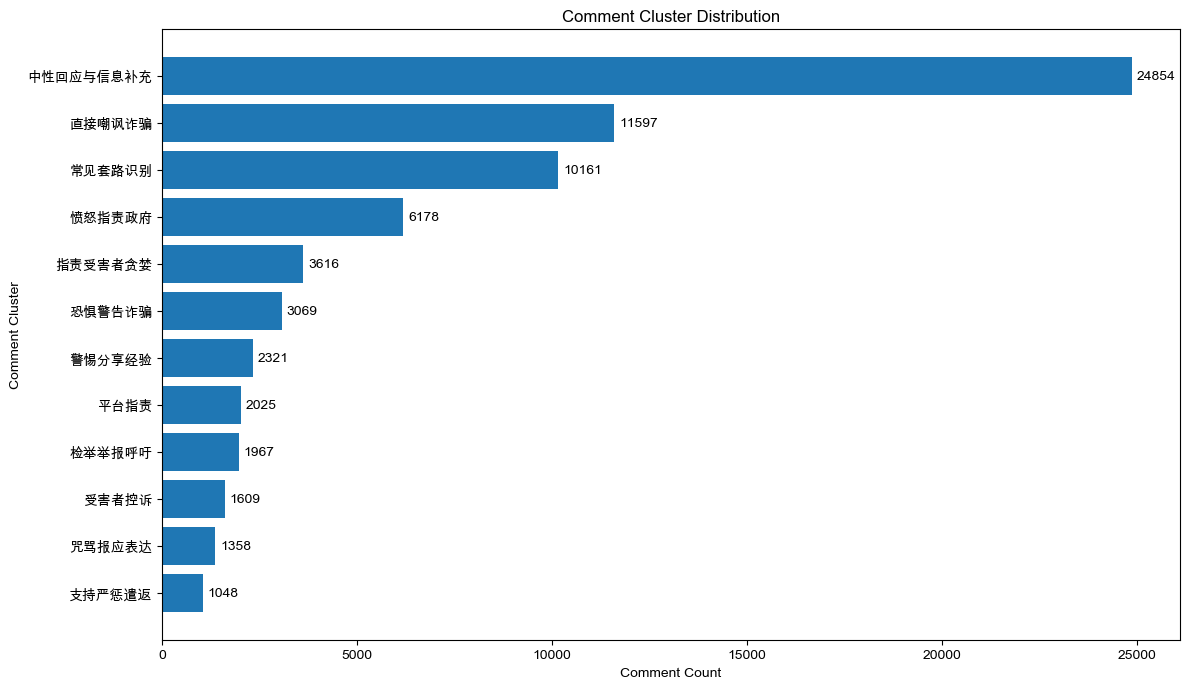

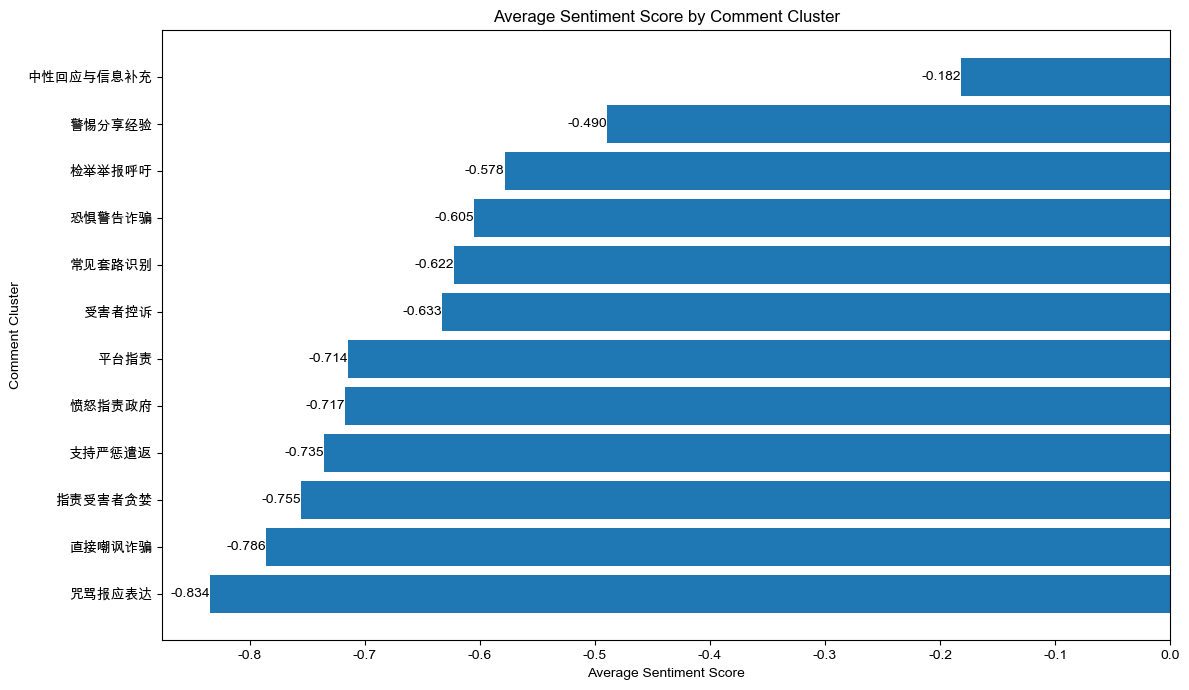

ValueError: sent_df 里找不到评论数量列，当前列名为: ['comment_cluster_id', 'comment_cluster_label', 'avg_sentiment_score', 'main_fine_grained_emotion', 'negative', 'neutral', 'positive', 'negative_ratio', 'neutral_ratio', 'positive_ratio']

In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# =====================================================
# 0. 路径设置
# =====================================================
INPUT_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment话题聚类分析")
OUTPUT_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/comment_cluster_visualizations")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COUNT_FILE = INPUT_DIR / "full_cluster_count_summary.csv"
SENTIMENT_FILE = INPUT_DIR / "full_cluster_sentiment_summary.csv"
BLAME_FILE = INPUT_DIR / "full_cluster_blame_summary.csv"
RESULT_FILE = INPUT_DIR / "full_comment_cluster_results.csv"

# =====================================================
# 1. 检查文件
# =====================================================
for f in [COUNT_FILE, SENTIMENT_FILE, BLAME_FILE, RESULT_FILE]:
    print(f"{f.name} exists:", f.exists())

# =====================================================
# 2. 读数据
# =====================================================
count_df = pd.read_csv(COUNT_FILE, low_memory=False)
sent_df = pd.read_csv(SENTIMENT_FILE, low_memory=False)
blame_df = pd.read_csv(BLAME_FILE, low_memory=False)
result_df = pd.read_csv(RESULT_FILE, low_memory=False)

print("count_df:", count_df.shape)
print("sent_df:", sent_df.shape)
print("blame_df:", blame_df.shape)
print("result_df:", result_df.shape)

# =====================================================
# 3. 兼容列名
# =====================================================
def standardize_cluster_cols(df):
    if "comment_cluster_id" not in df.columns and "cluster_id" in df.columns:
        df = df.rename(columns={"cluster_id": "comment_cluster_id"})
    if "comment_cluster_label" not in df.columns and "cluster_label" in df.columns:
        df = df.rename(columns={"cluster_label": "comment_cluster_label"})
    return df

count_df = standardize_cluster_cols(count_df)
sent_df = standardize_cluster_cols(sent_df)
blame_df = standardize_cluster_cols(blame_df)
result_df = standardize_cluster_cols(result_df)

# 如果没有 comment_text，尝试兼容原字段
if "comment_text" not in result_df.columns:
    if "translated_content_x" in result_df.columns:
        result_df["comment_text"] = result_df["translated_content_x"].fillna("")
    elif "content_x" in result_df.columns:
        result_df["comment_text"] = result_df["content_x"].fillna("")
    else:
        result_df["comment_text"] = ""

# =====================================================
# 4. 基础清洗
# =====================================================
for df in [count_df, sent_df, blame_df, result_df]:
    if "comment_cluster_label" in df.columns:
        df["comment_cluster_label"] = df["comment_cluster_label"].fillna("").astype(str).str.strip()

if "comment_cluster_id" in count_df.columns:
    count_df["comment_cluster_id"] = pd.to_numeric(count_df["comment_cluster_id"], errors="coerce")
if "comment_cluster_id" in sent_df.columns:
    sent_df["comment_cluster_id"] = pd.to_numeric(sent_df["comment_cluster_id"], errors="coerce")
if "comment_cluster_id" in blame_df.columns:
    blame_df["comment_cluster_id"] = pd.to_numeric(blame_df["comment_cluster_id"], errors="coerce")
if "comment_cluster_id" in result_df.columns:
    result_df["comment_cluster_id"] = pd.to_numeric(result_df["comment_cluster_id"], errors="coerce")

for col in ["comment_count", "avg_confidence", "ratio"]:
    if col in count_df.columns:
        count_df[col] = pd.to_numeric(count_df[col], errors="coerce")

for col in ["comment_count", "avg_sentiment_score", "negative_ratio", "neutral_ratio", "positive_ratio"]:
    if col in sent_df.columns:
        sent_df[col] = pd.to_numeric(sent_df[col], errors="coerce")

for col in ["comment_count", "blame_ratio"]:
    if col in blame_df.columns:
        blame_df[col] = pd.to_numeric(blame_df[col], errors="coerce")

if "sentiment_score" in result_df.columns:
    result_df["sentiment_score"] = pd.to_numeric(result_df["sentiment_score"], errors="coerce")

for col in ["sentiment_category", "fine_grained_emotions", "has_blame", "blame_subject", "blame_object", "blame_intensity"]:
    if col not in result_df.columns:
        result_df[col] = ""
    result_df[col] = result_df[col].fillna("").astype(str).str.strip()

# 去掉没有 cluster 的行
count_df = count_df[count_df["comment_cluster_label"] != ""].copy()
sent_df = sent_df[sent_df["comment_cluster_label"] != ""].copy()
blame_df = blame_df[blame_df["comment_cluster_label"] != ""].copy()
result_df = result_df[result_df["comment_cluster_label"] != ""].copy()

# =====================================================
# 5. 字体设置
# =====================================================
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS", "PingFang HK", "Heiti TC", "SimHei", "Microsoft YaHei"
]
plt.rcParams["axes.unicode_minus"] = False

# =====================================================
# 6. 工具函数
# =====================================================
def mode_nonempty(series):
    s = series.dropna().astype(str).str.strip()
    s = s[~s.isin(["", "nan", "None", "null"])]
    if len(s) == 0:
        return ""
    return s.value_counts().index[0]

# =====================================================
# 7. 图1：comment cluster 分布柱状图
# =====================================================
plot_count = count_df.sort_values("comment_count", ascending=False).copy()

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(plot_count["comment_cluster_label"], plot_count["comment_count"])
ax.invert_yaxis()
ax.set_xlabel("Comment Count")
ax.set_ylabel("Comment Cluster")
ax.set_title("Comment Cluster Distribution")

for i, v in enumerate(plot_count["comment_count"]):
    if pd.notna(v):
        ax.text(v + max(plot_count["comment_count"]) * 0.005, i, f"{int(v)}", va="center")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_comment_cluster_count_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# 8. 图2：comment cluster 平均情感分值图
# =====================================================
plot_sent = sent_df.sort_values("avg_sentiment_score", ascending=True).copy()

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(plot_sent["comment_cluster_label"], plot_sent["avg_sentiment_score"])
ax.set_xlabel("Average Sentiment Score")
ax.set_ylabel("Comment Cluster")
ax.set_title("Average Sentiment Score by Comment Cluster")

for i, v in enumerate(plot_sent["avg_sentiment_score"]):
    if pd.notna(v):
        ax.text(v, i, f"{v:.3f}", va="center", ha="left" if v >= 0 else "right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_comment_cluster_avg_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# 图3：comment cluster 情感结构 100% 堆叠图
# =====================================================

# 自动识别评论数量列
if "comment_count" in sent_df.columns:
    count_col = "comment_count"
elif "count" in sent_df.columns:
    count_col = "count"
elif "cluster_count" in sent_df.columns:
    count_col = "cluster_count"
else:
    raise ValueError(f"sent_df 里找不到评论数量列，当前列名为: {sent_df.columns.tolist()}")

stack_df = sent_df.sort_values(count_col, ascending=False).copy()

x = np.arange(len(stack_df))
neg = stack_df["negative_ratio"].fillna(0).values
neu = stack_df["neutral_ratio"].fillna(0).values
pos = stack_df["positive_ratio"].fillna(0).values

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(x, neg, label="Negative")
ax.bar(x, neu, bottom=neg, label="Neutral")
ax.bar(x, pos, bottom=neg + neu, label="Positive")

ax.set_xticks(x)
ax.set_xticklabels(stack_df["comment_cluster_label"], rotation=45, ha="right")
ax.set_ylabel("Ratio")
ax.set_title("Sentiment Composition within Each Comment Cluster")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_comment_cluster_sentiment_stacked.png", dpi=300, bbox_inches="tight")
plt.show()
# =====================================================
# 10. 图4：comment cluster blame_ratio 柱状图
# =====================================================
plot_blame = blame_df.sort_values("blame_ratio", ascending=False).copy()

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(plot_blame["comment_cluster_label"], plot_blame["blame_ratio"])
ax.invert_yaxis()
ax.set_xlabel("Blame Ratio")
ax.set_ylabel("Comment Cluster")
ax.set_title("Blame Ratio by Comment Cluster")

for i, v in enumerate(plot_blame["blame_ratio"]):
    if pd.notna(v):
        ax.text(v + 0.005, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_comment_cluster_blame_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# 11. 图5：情感 × blame 气泡图
# x = avg_sentiment_score
# y = blame_ratio
# 点大小 = comment_count
# =====================================================
bubble_df = sent_df.merge(
    blame_df[["comment_cluster_id", "comment_cluster_label", "blame_ratio"]],
    on=["comment_cluster_id", "comment_cluster_label"],
    how="left"
)

bubble_df["blame_ratio"] = pd.to_numeric(bubble_df["blame_ratio"], errors="coerce").fillna(0)
bubble_df["comment_count"] = pd.to_numeric(bubble_df["comment_count"], errors="coerce").fillna(0)

size_scaled = (bubble_df["comment_count"] / bubble_df["comment_count"].max()) * 1500 + 100

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(
    bubble_df["avg_sentiment_score"],
    bubble_df["blame_ratio"],
    s=size_scaled,
    alpha=0.7
)

for _, row in bubble_df.iterrows():
    ax.text(
        row["avg_sentiment_score"],
        row["blame_ratio"],
        str(row["comment_cluster_label"]),
        fontsize=9
    )

ax.set_xlabel("Average Sentiment Score")
ax.set_ylabel("Blame Ratio")
ax.set_title("Comment Cluster Bubble Plot\n(x = Avg Sentiment, y = Blame Ratio, size = Comment Count)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_comment_cluster_sentiment_blame_bubble.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# 12. 表1：每个 comment cluster 的 Top3 blame object
# =====================================================
blame_object_dist = (
    result_df[result_df["blame_object"] != ""]
    .groupby(["comment_cluster_label", "blame_object"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

blame_object_dist["rank"] = (
    blame_object_dist.groupby("comment_cluster_label")["count"]
    .rank(method="first", ascending=False)
)

top_blame_object = blame_object_dist[blame_object_dist["rank"] <= 3].copy()
top_blame_object = top_blame_object.sort_values(["comment_cluster_label", "rank"])

top_blame_object.to_csv(
    OUTPUT_DIR / "06_comment_cluster_top_blame_object.csv",
    index=False,
    encoding="utf-8-sig"
)

# =====================================================
# 13. 表2：每个 comment cluster 抽样 5 条评论
# =====================================================
result_df["text_len"] = result_df["comment_text"].astype(str).str.len()

sample_comments = (
    result_df.sort_values(["comment_cluster_label", "text_len"], ascending=[True, False])
    .groupby("comment_cluster_label", group_keys=False)
    .head(5)
)

sample_comments = sample_comments[
    [
        "comment_cluster_id",
        "comment_cluster_label",
        "comment_text",
        "sentiment_category",
        "has_blame",
        "blame_object",
        "blame_intensity"
    ]
].copy()

sample_comments.to_csv(
    OUTPUT_DIR / "07_comment_cluster_sample_comments.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n全部完成，输出文件保存在：")
print(OUTPUT_DIR)

In [19]:
from pathlib import Path
import pandas as pd

base = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析")

print("文件夹存在：", base.exists())
print("\n里面的文件：")
for f in base.iterdir():
    print("-", f.name)

# 如果你想检查某个表的列名，比如这个：
file = base / "post_cluster_sentiment_summary_core.csv"
print("\n目标文件存在：", file.exists())

if file.exists():
    df = pd.read_csv(file, low_memory=False)
    print("\n列名：")
    print(df.columns.tolist())
    print("\n前5行：")
    print(df.head())

文件夹存在： True

里面的文件：
- figures_part4
- figures_part3
- figures_part2
- figures_part5
- figures_post_comment
- .DS_Store
- unmatched_post_ids_from_comment.csv
- post_cluster_blame_summary_core.csv
- figures_part6
- figures_part1
- topic_merged_final_core_only.csv
- comment_cluster_visualizations
- post_comment_cluster_distribution_core.csv
- post_comment_cluster_distribution_all.csv
- post_cluster_sentiment_summary_core.csv
- post_comment_cluster_pivot_core.csv
- topic_merged_final_all_comments.csv
- figures_post_comment_split

目标文件存在： True

列名：
['post_cluster_id', 'post_cluster_label', 'comment_count', 'avg_sentiment_score', 'negative', 'neutral', 'positive', 'negative_ratio', 'neutral_ratio', 'positive_ratio']

前5行：
   post_cluster_id post_cluster_label  comment_count  avg_sentiment_score  \
0              3.0         质疑真实性/求证诈骗          19391            -0.390293   
1              1.0          指责骗子/诈骗集团          13702            -0.624799   
2              4.0           分享个人受害经历      

数据大小： (64453, 16)
['comment_id', 'post_id', 'post_cluster_id', 'post_cluster_label', 'post_cluster_matched', 'comment_cluster_id', 'comment_cluster_label', 'comment_text', 'sentiment_score', 'sentiment_category', 'fine_grained_emotions', 'has_blame', 'blame_subject', 'blame_object', 'blame_intensity', 'confidence']

comment cluster summary:
   comment_cluster_label  comment_count     ratio
0              中性回应与信息补充          23339  0.362109
11                直接嘲讽诈骗          11127  0.172637
4                 常见套路识别           9209  0.142879
7                 愤怒指责政府           6089  0.094472
8                指责受害者贪婪           3104  0.048159
6                 恐惧警告诈骗           2649  0.041100
12                警惕分享经验           2089  0.032411
5                   平台指责           1881  0.029184
2                  受害者控诉           1476  0.022900
10                检举举报呼吁           1309  0.020309
3                 咒骂报应表达           1125  0.017455
9                 支持严惩遣返            983  0.015251
1      

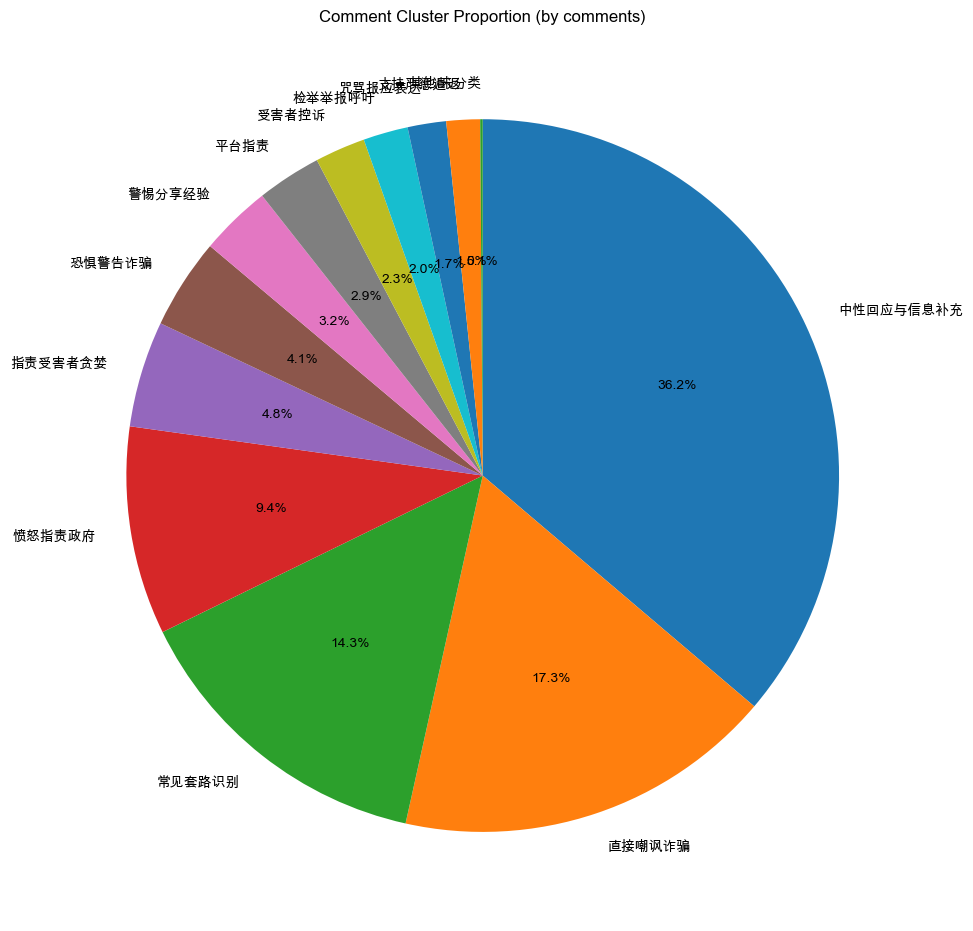

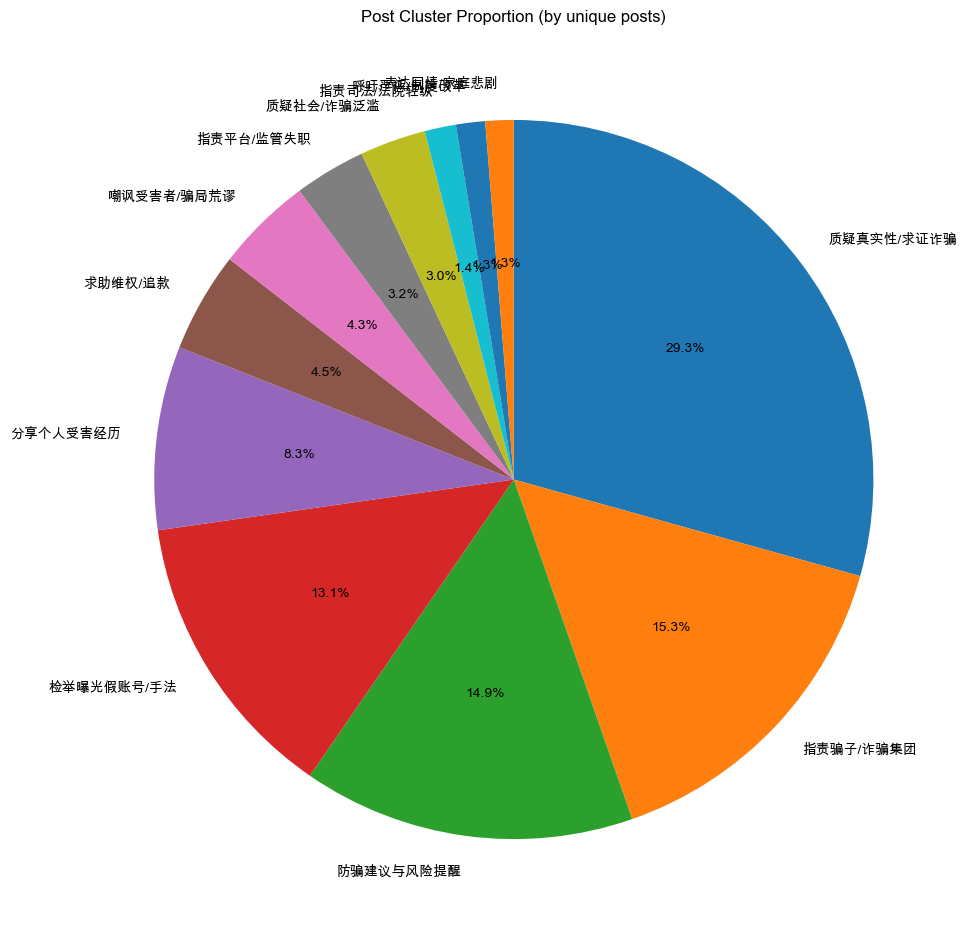


完成，输出文件：
1. /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_pie/comment_cluster_ratio_summary.csv
2. /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_pie/post_cluster_ratio_summary.csv
3. /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_pie/comment_cluster_pie_chart.png
4. /Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_pie/post_cluster_pie_chart.png


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 1. 路径设置
# =========================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析")

INPUT_FILE = BASE_DIR / "topic_merged_final_core_only.csv"

OUTPUT_DIR = BASE_DIR / "figures_pie"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COMMENT_SUMMARY_FILE = OUTPUT_DIR / "comment_cluster_ratio_summary.csv"
POST_SUMMARY_FILE = OUTPUT_DIR / "post_cluster_ratio_summary.csv"

# =========================
# 2. 读取数据
# =========================
df = pd.read_csv(INPUT_FILE, low_memory=False)

print("数据大小：", df.shape)
print(df.columns.tolist())

# =========================
# 3. 基础清洗
# =========================
for col in ["comment_id", "post_id", "comment_cluster_label", "post_cluster_label"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# 去掉空标签
df = df[
    (df["comment_cluster_label"] != "") &
    (df["post_cluster_label"] != "")
].copy()

# 中文字体
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS", "PingFang HK", "Heiti TC", "SimHei", "Microsoft YaHei"
]
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 4. comment cluster 占比
#    按评论条数统计
# =========================
comment_summary = (
    df.groupby("comment_cluster_label", as_index=False)
    .agg(comment_count=("comment_id", "count"))
    .sort_values("comment_count", ascending=False)
)

comment_summary["ratio"] = comment_summary["comment_count"] / comment_summary["comment_count"].sum()
comment_summary.to_csv(COMMENT_SUMMARY_FILE, index=False, encoding="utf-8-sig")

print("\ncomment cluster summary:")
print(comment_summary)

# =========================
# 5. post cluster 占比
#    按唯一 post_id 统计
# =========================
post_summary = (
    df[["post_id", "post_cluster_label"]]
    .drop_duplicates(subset=["post_id"])
    .groupby("post_cluster_label", as_index=False)
    .agg(post_count=("post_id", "count"))
    .sort_values("post_count", ascending=False)
)

post_summary["ratio"] = post_summary["post_count"] / post_summary["post_count"].sum()
post_summary.to_csv(POST_SUMMARY_FILE, index=False, encoding="utf-8-sig")

print("\npost cluster summary:")
print(post_summary)

# =========================
# 6. 画 comment cluster 饼图
# =========================
fig, ax = plt.subplots(figsize=(10, 10))

ax.pie(
    comment_summary["comment_count"],
    labels=comment_summary["comment_cluster_label"],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)

ax.set_title("Comment Cluster Proportion (by comments)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comment_cluster_pie_chart.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 7. 画 post cluster 饼图
# =========================
fig, ax = plt.subplots(figsize=(10, 10))

ax.pie(
    post_summary["post_count"],
    labels=post_summary["post_cluster_label"],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)

ax.set_title("Post Cluster Proportion (by unique posts)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "post_cluster_pie_chart.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n完成，输出文件：")
print("1.", COMMENT_SUMMARY_FILE)
print("2.", POST_SUMMARY_FILE)
print("3.", OUTPUT_DIR / "comment_cluster_pie_chart.png")
print("4.", OUTPUT_DIR / "post_cluster_pie_chart.png")

数据大小： (64453, 16)
列名：
['comment_id', 'post_id', 'post_cluster_id', 'post_cluster_label', 'post_cluster_matched', 'comment_cluster_id', 'comment_cluster_label', 'comment_text', 'sentiment_score', 'sentiment_category', 'fine_grained_emotions', 'has_blame', 'blame_subject', 'blame_object', 'blame_intensity', 'confidence']

comment cluster summary:
   comment_cluster_label  comment_count     ratio
0              中性回应与信息补充          23339  0.362109
11                直接嘲讽诈骗          11127  0.172637
4                 常见套路识别           9209  0.142879
7                 愤怒指责政府           6089  0.094472
8                指责受害者贪婪           3104  0.048159
6                 恐惧警告诈骗           2649  0.041100
12                警惕分享经验           2089  0.032411
5                   平台指责           1881  0.029184
2                  受害者控诉           1476  0.022900
10                检举举报呼吁           1309  0.020309
3                 咒骂报应表达           1125  0.017455
9                 支持严惩遣返            983  0.015251
1  

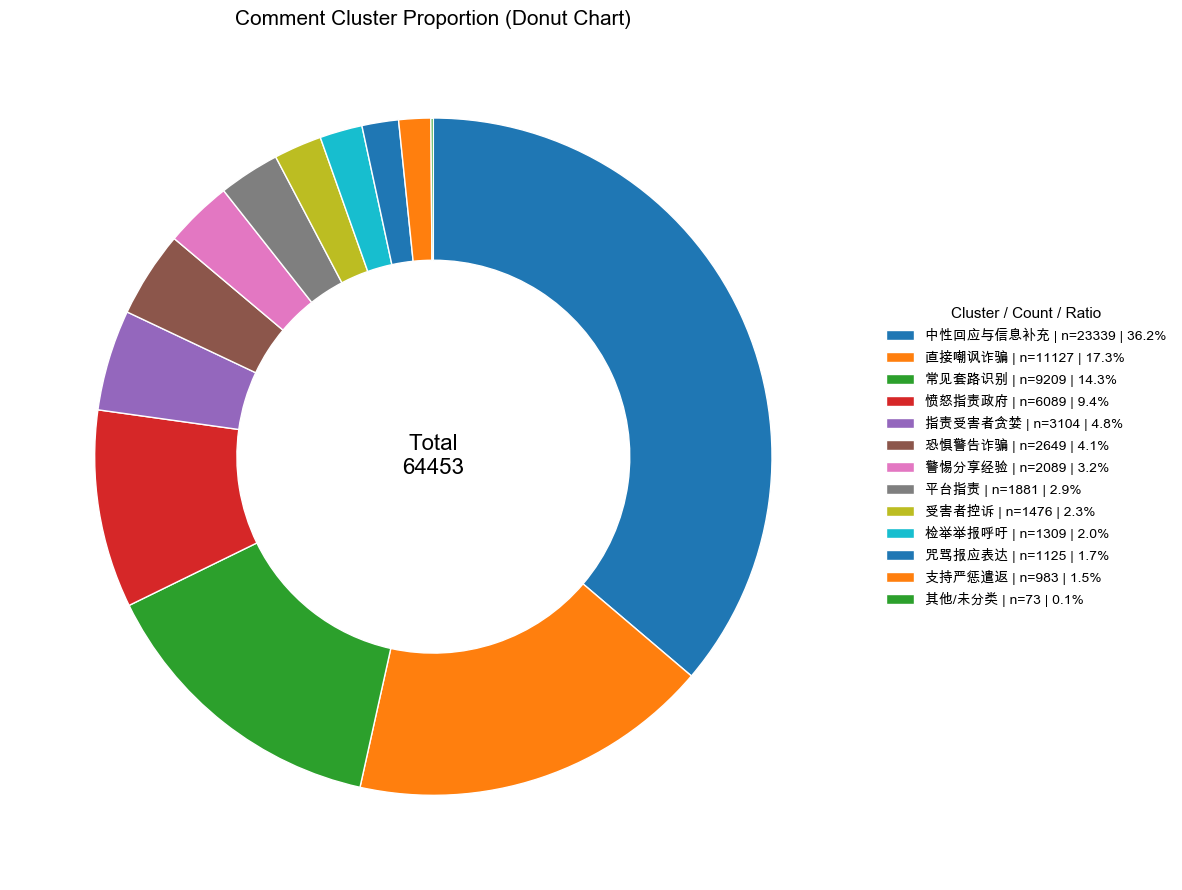

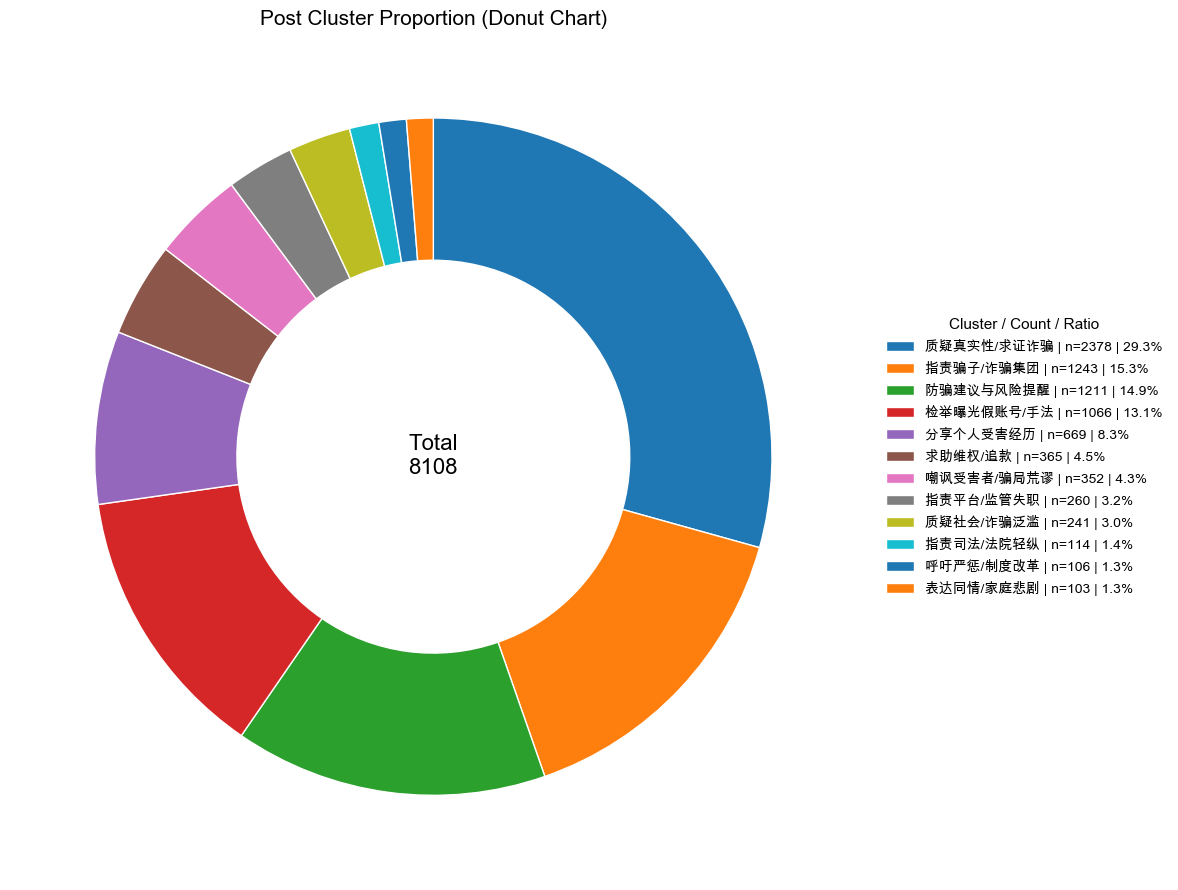


完成，输出文件：
/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_donut/comment_cluster_ratio_summary.csv
/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_donut/post_cluster_ratio_summary.csv
/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_donut/comment_cluster_donut_chart.png
/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_donut/post_cluster_donut_chart.png


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 1. 路径设置
# =========================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析")
INPUT_FILE = BASE_DIR / "topic_merged_final_core_only.csv"

OUTPUT_DIR = BASE_DIR / "figures_donut"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2. 读取数据
# =========================
df = pd.read_csv(INPUT_FILE, low_memory=False)

print("数据大小：", df.shape)
print("列名：")
print(df.columns.tolist())

# =========================
# 3. 基础清洗
# =========================
for col in ["comment_id", "post_id", "comment_cluster_label", "post_cluster_label"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df = df[
    (df["comment_cluster_label"].notna()) &
    (df["post_cluster_label"].notna()) &
    (df["comment_cluster_label"] != "") &
    (df["post_cluster_label"] != "")
].copy()

# 中文显示
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS", "PingFang HK", "Heiti TC", "SimHei", "Microsoft YaHei"
]
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 4. comment cluster 汇总
# =========================
comment_summary = (
    df.groupby("comment_cluster_label", as_index=False)
    .agg(comment_count=("comment_id", "count"))
    .sort_values("comment_count", ascending=False)
)

comment_summary["ratio"] = comment_summary["comment_count"] / comment_summary["comment_count"].sum()
comment_summary.to_csv(OUTPUT_DIR / "comment_cluster_ratio_summary.csv", index=False, encoding="utf-8-sig")

print("\ncomment cluster summary:")
print(comment_summary)

# =========================
# 5. post cluster 汇总
# =========================
post_summary = (
    df[["post_id", "post_cluster_label"]]
    .drop_duplicates(subset=["post_id"])
    .groupby("post_cluster_label", as_index=False)
    .agg(post_count=("post_id", "count"))
    .sort_values("post_count", ascending=False)
)

post_summary["ratio"] = post_summary["post_count"] / post_summary["post_count"].sum()
post_summary.to_csv(OUTPUT_DIR / "post_cluster_ratio_summary.csv", index=False, encoding="utf-8-sig")

print("\npost cluster summary:")
print(post_summary)

# =========================
# 6. 画 donut chart 的函数
# =========================
def draw_donut(summary_df, label_col, count_col, title, output_file):
    labels = summary_df[label_col].tolist()
    values = summary_df[count_col].tolist()
    ratios = (summary_df[count_col] / summary_df[count_col].sum() * 100).tolist()
    total = sum(values)

    # 右侧图例文字：名称 + 数量 + 百分比
    legend_labels = [
        f"{lab} | n={val} | {rat:.1f}%"
        for lab, val, rat in zip(labels, values, ratios)
    ]

    fig, ax = plt.subplots(figsize=(12, 9))

    wedges, _ = ax.pie(
        values,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.42, edgecolor="white")
    )

    # 中间文字
    ax.text(
        0, 0,
        f"Total\n{total}",
        ha="center",
        va="center",
        fontsize=16
    )

    ax.set_title(title, fontsize=15)

    # 右侧图例
    ax.legend(
        wedges,
        legend_labels,
        title="Cluster / Count / Ratio",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10,
        title_fontsize=11,
        frameon=False
    )

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

# =========================
# 7. comment donut chart
# =========================
draw_donut(
    summary_df=comment_summary,
    label_col="comment_cluster_label",
    count_col="comment_count",
    title="Comment Cluster Proportion (Donut Chart)",
    output_file=OUTPUT_DIR / "comment_cluster_donut_chart.png"
)

# =========================
# 8. post donut chart
# =========================
draw_donut(
    summary_df=post_summary,
    label_col="post_cluster_label",
    count_col="post_count",
    title="Post Cluster Proportion (Donut Chart)",
    output_file=OUTPUT_DIR / "post_cluster_donut_chart.png"
)

print("\n完成，输出文件：")
print(OUTPUT_DIR / "comment_cluster_ratio_summary.csv")
print(OUTPUT_DIR / "post_cluster_ratio_summary.csv")
print(OUTPUT_DIR / "comment_cluster_donut_chart.png")
print(OUTPUT_DIR / "post_cluster_donut_chart.png")

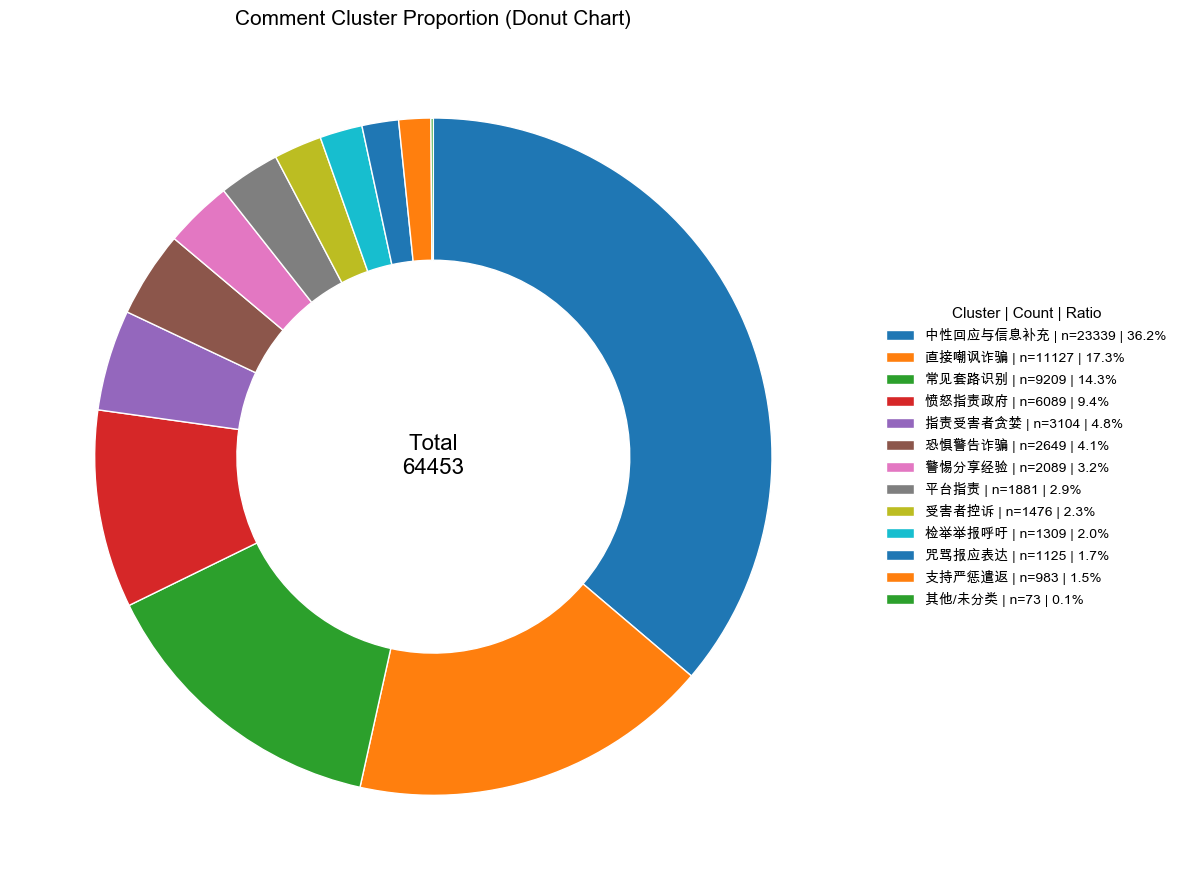

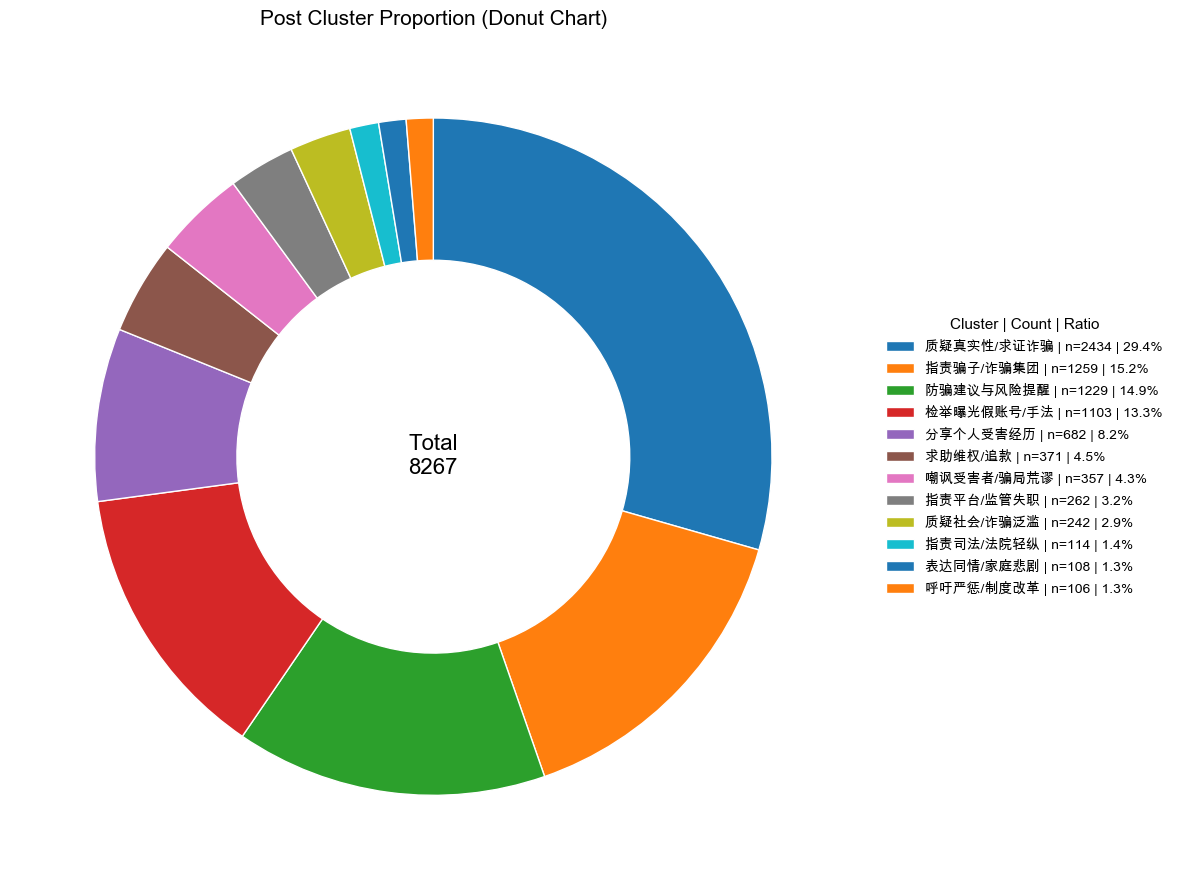


完成，输出文件：
/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_donut_fixed/comment_cluster_ratio_summary.csv
/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_donut_fixed/post_cluster_ratio_summary_fixed.csv
/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_donut_fixed/comment_cluster_donut_chart.png
/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/figures_donut_fixed/post_cluster_donut_chart_fixed.png


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 1. 路径设置
# =========================
BASE_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析")
INPUT_FILE = BASE_DIR / "topic_merged_final_core_only.csv"

OUTPUT_DIR = BASE_DIR / "figures_donut_fixed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2. 读取 comment 数据
# =========================
df = pd.read_csv(INPUT_FILE, low_memory=False)

for col in ["comment_id", "post_id", "comment_cluster_label", "post_cluster_label"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df = df[
    (df["comment_cluster_label"].notna()) &
    (df["comment_cluster_label"] != "")
].copy()

# 中文显示
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS", "PingFang HK", "Heiti TC", "SimHei", "Microsoft YaHei"
]
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 3. comment cluster 汇总（按评论条数）
# =========================
comment_summary = (
    df.groupby("comment_cluster_label", as_index=False)
    .agg(comment_count=("comment_id", "count"))
    .sort_values("comment_count", ascending=False)
)

comment_summary["ratio"] = comment_summary["comment_count"] / comment_summary["comment_count"].sum()
comment_summary.to_csv(OUTPUT_DIR / "comment_cluster_ratio_summary.csv", index=False, encoding="utf-8-sig")

# =========================
# 4. post cluster 汇总（直接用你给的数据）
# =========================
post_summary = pd.DataFrame([
    [3, "质疑真实性/求证诈骗", 2434, 0.89685703, 0.2930059],
    [1, "指责骗子/诈骗集团", 1259, 0.87682288, 0.15155893],
    [6, "防骗建议与风险提醒", 1229, 0.87209113, 0.14794751],
    [11, "检举曝光假账号/手法", 1103, 0.89500453, 0.13277958],
    [4, "分享个人受害经历", 682, 0.88002933, 0.08209943],
    [12, "求助维权/追款", 371, 0.87784367, 0.04466113],
    [8, "嘲讽受害者/骗局荒谬", 357, 0.83879552, 0.0429758],
    [5, "指责平台/监管失职", 262, 0.85820611, 0.03153967],
    [10, "质疑社会/诈骗泛滥", 242, 0.78206612, 0.02913206],
    [2, "指责司法/法院轻纵", 114, 0.87561404, 0.01372337],
    [9, "表达同情/家庭悲剧", 108, 0.8675, 0.01300108],
    [7, "呼吁严惩/制度改革", 106, 0.86641509, 0.01276032],
], columns=["post_cluster_id", "post_cluster_label", "post_count", "avg_confidence", "ratio"])

post_summary.to_csv(OUTPUT_DIR / "post_cluster_ratio_summary_fixed.csv", index=False, encoding="utf-8-sig")

# =========================
# 5. donut chart 函数
# =========================
def draw_donut(summary_df, label_col, count_col, title, output_file):
    labels = summary_df[label_col].tolist()
    values = summary_df[count_col].tolist()
    ratios = (summary_df[count_col] / summary_df[count_col].sum() * 100).tolist()
    total = sum(values)

    legend_labels = [
        f"{lab} | n={val} | {rat:.1f}%"
        for lab, val, rat in zip(labels, values, ratios)
    ]

    fig, ax = plt.subplots(figsize=(12, 9))

    wedges, _ = ax.pie(
        values,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.42, edgecolor="white")
    )

    ax.text(
        0, 0,
        f"Total\n{total}",
        ha="center",
        va="center",
        fontsize=16
    )

    ax.set_title(title, fontsize=15)

    ax.legend(
        wedges,
        legend_labels,
        title="Cluster | Count | Ratio",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10,
        title_fontsize=11,
        frameon=False
    )

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

# =========================
# 6. comment donut
# =========================
draw_donut(
    summary_df=comment_summary,
    label_col="comment_cluster_label",
    count_col="comment_count",
    title="Comment Cluster Proportion (Donut Chart)",
    output_file=OUTPUT_DIR / "comment_cluster_donut_chart.png"
)

# =========================
# 7. post donut（固定版）
# =========================
draw_donut(
    summary_df=post_summary,
    label_col="post_cluster_label",
    count_col="post_count",
    title="Post Cluster Proportion (Donut Chart)",
    output_file=OUTPUT_DIR / "post_cluster_donut_chart_fixed.png"
)

print("\n完成，输出文件：")
print(OUTPUT_DIR / "comment_cluster_ratio_summary.csv")
print(OUTPUT_DIR / "post_cluster_ratio_summary_fixed.csv")
print(OUTPUT_DIR / "comment_cluster_donut_chart.png")
print(OUTPUT_DIR / "post_cluster_donut_chart_fixed.png")

原始数据大小： (69879, 16)
列名：
['comment_id', 'post_id', 'post_cluster_id', 'post_cluster_label', 'post_cluster_matched', 'comment_cluster_id', 'comment_cluster_label', 'comment_text', 'sentiment_score', 'sentiment_category', 'fine_grained_emotions', 'has_blame', 'blame_subject', 'blame_object', 'blame_intensity', 'confidence']
清洗后数据大小： (63930, 3)
拆分后长表大小： (106920, 4)

已保存：post_cluster_fine_grained_emotion_distribution.csv
   post_cluster_id post_cluster_label         emotion  emotion_count  \
0              1.0          指责骗子/诈骗集团           anger           8219   
1              1.0          指责骗子/诈骗集团            mock           7830   
2              1.0          指责骗子/诈骗集团             sad           1746   
3              1.0          指责骗子/诈骗集团        surprise           1713   
4              1.0          指责骗子/诈骗集团            fear           1328   
5              1.0          指责骗子/诈骗集团             joy            255   
6              1.0          指责骗子/诈骗集团         neutral            231   
7   

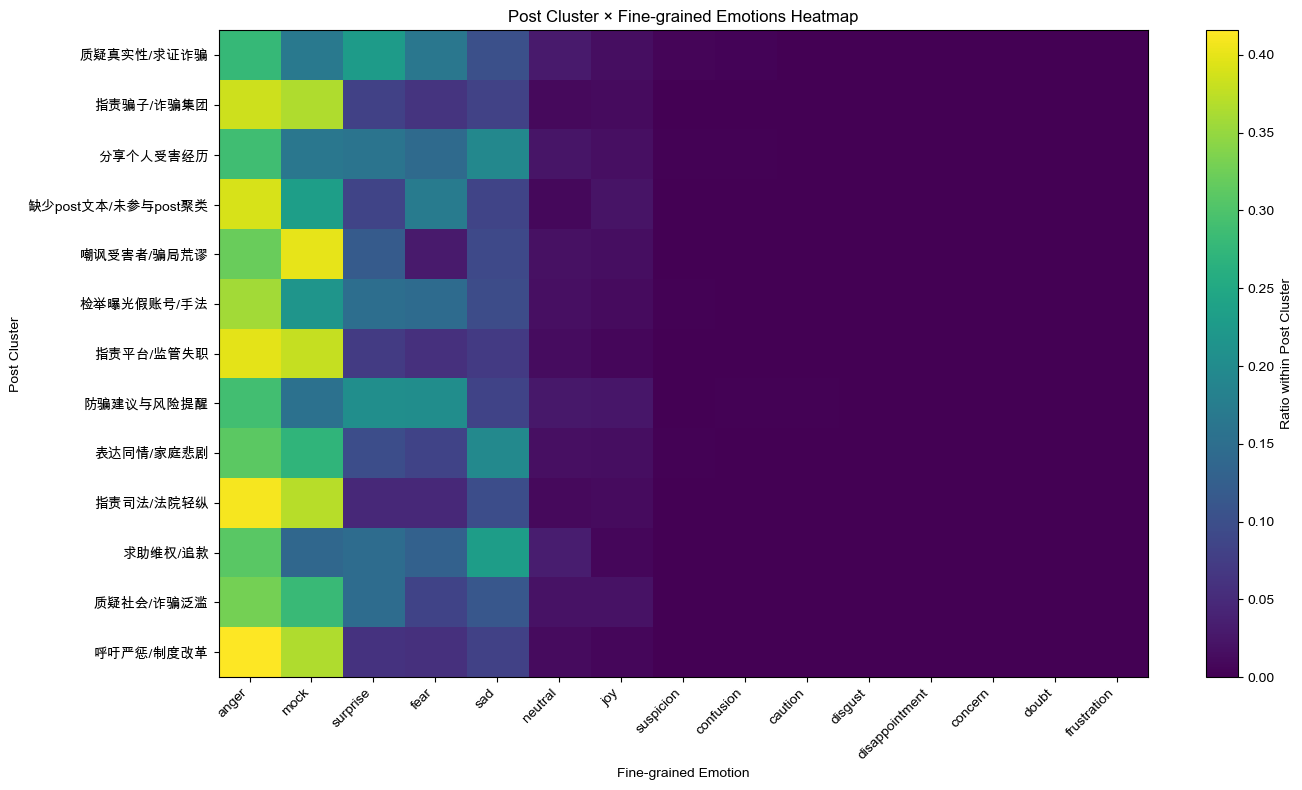


已保存：post_cluster_fine_grained_emotion_heatmap.png


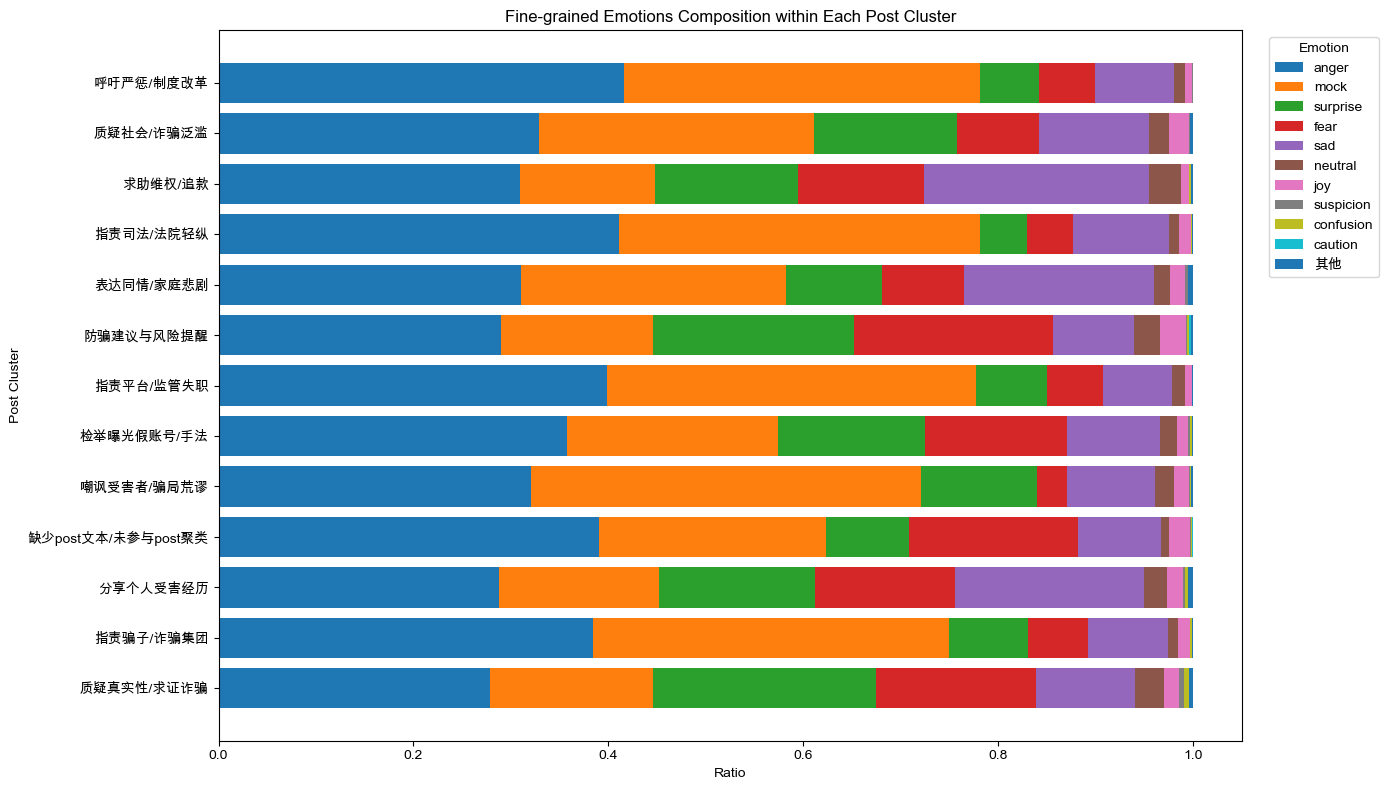


已保存：post_cluster_fine_grained_emotion_stacked_bar.png

全部完成，输出文件保存在：
/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/post_cluster_fine_grained_emotions


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# =========================================================
# 1. 路径设置
# =========================================================
INPUT_FILE = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/topic_merged_final_all_comments.csv")
OUTPUT_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/post_cluster_fine_grained_emotions")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# 2. 读取数据
# =========================================================
df = pd.read_csv(INPUT_FILE, low_memory=False)
print("原始数据大小：", df.shape)
print("列名：")
print(df.columns.tolist())

# =========================================================
# 3. 检查需要的列
# =========================================================
required_cols = ["post_cluster_id", "post_cluster_label", "fine_grained_emotions"]
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"缺少这些列：{missing_cols}")

# =========================================================
# 4. 保留核心列并清洗
# =========================================================
emotion_df = df[required_cols].copy()

emotion_df["post_cluster_id"] = emotion_df["post_cluster_id"].astype(str).str.strip()
emotion_df["post_cluster_label"] = emotion_df["post_cluster_label"].astype(str).str.strip()
emotion_df["fine_grained_emotions"] = emotion_df["fine_grained_emotions"].astype(str).str.strip()

# 去掉明显无效值
invalid_values = ["", "nan", "none", "null", "[]", "{}", "未分类", "无", "missing"]
emotion_df = emotion_df[
    ~emotion_df["fine_grained_emotions"].str.lower().isin(invalid_values)
].copy()

print("清洗后数据大小：", emotion_df.shape)

# =========================================================
# 5. 拆分 fine_grained_emotions
#    兼容多种分隔符：, ; | / 、 以及中英文逗号分号
# =========================================================
def split_emotions(x):
    if pd.isna(x):
        return []
    x = str(x).strip()
    if x == "":
        return []
    
    # 去掉两边中括号（如果有）
    x = re.sub(r"^\[|\]$", "", x)
    
    # 按常见分隔符切分
    parts = re.split(r"[;,，；|/、]+", x)
    parts = [p.strip() for p in parts if p.strip()]
    return parts

emotion_df["emotion_list"] = emotion_df["fine_grained_emotions"].apply(split_emotions)

# explode
emotion_long = emotion_df.explode("emotion_list").copy()
emotion_long = emotion_long.rename(columns={"emotion_list": "emotion"})
emotion_long["emotion"] = emotion_long["emotion"].astype(str).str.strip()

# 再去一遍空值
emotion_long = emotion_long[
    emotion_long["emotion"].notna() &
    (emotion_long["emotion"] != "") &
    (~emotion_long["emotion"].str.lower().isin(["nan", "none", "null"]))
].copy()

print("拆分后长表大小：", emotion_long.shape)

# =========================================================
# 6. 统计每个 post cluster 下 emotion 的数量与占比
# =========================================================
summary = (
    emotion_long
    .groupby(["post_cluster_id", "post_cluster_label", "emotion"], as_index=False)
    .size()
    .rename(columns={"size": "emotion_count"})
)

cluster_total = (
    summary
    .groupby(["post_cluster_id", "post_cluster_label"], as_index=False)["emotion_count"]
    .sum()
    .rename(columns={"emotion_count": "total_emotion_count"})
)

summary = summary.merge(cluster_total, on=["post_cluster_id", "post_cluster_label"], how="left")
summary["ratio"] = summary["emotion_count"] / summary["total_emotion_count"]

# 排序
summary = summary.sort_values(
    by=["post_cluster_id", "ratio", "emotion_count"],
    ascending=[True, False, False]
).reset_index(drop=True)

# 保存明细表
summary.to_csv(OUTPUT_DIR / "post_cluster_fine_grained_emotion_distribution.csv", index=False, encoding="utf-8-sig")

print("\n已保存：post_cluster_fine_grained_emotion_distribution.csv")
print(summary.head(20))

# =========================================================
# 7. 做 pivot 表（占比）
# =========================================================
pivot_ratio = summary.pivot_table(
    index="post_cluster_label",
    columns="emotion",
    values="ratio",
    fill_value=0
)

# 按总量大的 post cluster 排序
cluster_order = (
    cluster_total.sort_values("total_emotion_count", ascending=False)["post_cluster_label"]
    .tolist()
)

pivot_ratio = pivot_ratio.reindex(cluster_order)

pivot_ratio.to_csv(OUTPUT_DIR / "post_cluster_fine_grained_emotion_pivot_ratio.csv", encoding="utf-8-sig")

print("\n已保存：post_cluster_fine_grained_emotion_pivot_ratio.csv")
print(pivot_ratio.head())

# =========================================================
# 8. 做 pivot 表（计数）
# =========================================================
pivot_count = summary.pivot_table(
    index="post_cluster_label",
    columns="emotion",
    values="emotion_count",
    fill_value=0
)

pivot_count = pivot_count.reindex(cluster_order)
pivot_count.to_csv(OUTPUT_DIR / "post_cluster_fine_grained_emotion_pivot_count.csv", encoding="utf-8-sig")

print("\n已保存：post_cluster_fine_grained_emotion_pivot_count.csv")

# =========================================================
# 9. 提取每个 post cluster 的 Top3 emotions
# =========================================================
top3 = (
    summary
    .sort_values(["post_cluster_label", "ratio", "emotion_count"], ascending=[True, False, False])
    .groupby("post_cluster_label")
    .head(3)
    .copy()
)

top3["rank_within_cluster"] = top3.groupby("post_cluster_label").cumcount() + 1

top3 = top3[[
    "post_cluster_id", "post_cluster_label", "rank_within_cluster",
    "emotion", "emotion_count", "total_emotion_count", "ratio"
]]

top3.to_csv(OUTPUT_DIR / "post_cluster_fine_grained_emotion_top3.csv", index=False, encoding="utf-8-sig")

print("\n已保存：post_cluster_fine_grained_emotion_top3.csv")
print(top3.head(20))

# =========================================================
# 10. 热力图
# =========================================================
# 为了图更清楚，只显示总体出现次数前15的 emotion
top_emotions = (
    summary.groupby("emotion", as_index=False)["emotion_count"]
    .sum()
    .sort_values("emotion_count", ascending=False)
    .head(15)["emotion"]
    .tolist()
)

heatmap_df = pivot_ratio[top_emotions].copy()

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_yticks(np.arange(len(heatmap_df.index)))

ax.set_xticklabels(heatmap_df.columns, rotation=45, ha="right")
ax.set_yticklabels(heatmap_df.index)

ax.set_title("Post Cluster × Fine-grained Emotions Heatmap")
ax.set_xlabel("Fine-grained Emotion")
ax.set_ylabel("Post Cluster")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Ratio within Post Cluster")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "post_cluster_fine_grained_emotion_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n已保存：post_cluster_fine_grained_emotion_heatmap.png")

# =========================================================
# 11. 100% 堆叠条形图
#     还是只画前10个最常见 emotion，避免太挤
# =========================================================
top_emotions_bar = (
    summary.groupby("emotion", as_index=False)["emotion_count"]
    .sum()
    .sort_values("emotion_count", ascending=False)
    .head(10)["emotion"]
    .tolist()
)

stack_df = pivot_ratio[top_emotions_bar].copy()

# 如果有些行因为top10没覆盖到100%，这里可保留“其他”
stack_df["其他"] = 1 - stack_df.sum(axis=1)
stack_df["其他"] = stack_df["其他"].clip(lower=0)

fig, ax = plt.subplots(figsize=(14, 8))

bottom = np.zeros(len(stack_df))

for col in stack_df.columns:
    vals = stack_df[col].values
    ax.barh(stack_df.index, vals, left=bottom, label=col)
    bottom += vals

ax.set_title("Fine-grained Emotions Composition within Each Post Cluster")
ax.set_xlabel("Ratio")
ax.set_ylabel("Post Cluster")
ax.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "post_cluster_fine_grained_emotion_stacked_bar.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n已保存：post_cluster_fine_grained_emotion_stacked_bar.png")

# =========================================================
# 12. 输出说明
# =========================================================
print("\n全部完成，输出文件保存在：")
print(OUTPUT_DIR)

原始数据大小： (64453, 16)
列名：
['comment_id', 'post_id', 'post_cluster_id', 'post_cluster_label', 'post_cluster_matched', 'comment_cluster_id', 'comment_cluster_label', 'comment_text', 'sentiment_score', 'sentiment_category', 'fine_grained_emotions', 'has_blame', 'blame_subject', 'blame_object', 'blame_intensity', 'confidence']
清洗后数据大小： (58838, 3)
拆分后长表大小： (97797, 4)

已保存：post_cluster_fine_grained_emotion_distribution_core.csv
   post_cluster_id post_cluster_label         emotion  emotion_count  \
0              1.0          指责骗子/诈骗集团           anger           8219   
1              1.0          指责骗子/诈骗集团            mock           7830   
2              1.0          指责骗子/诈骗集团             sad           1746   
3              1.0          指责骗子/诈骗集团        surprise           1713   
4              1.0          指责骗子/诈骗集团            fear           1328   
5              1.0          指责骗子/诈骗集团             joy            255   
6              1.0          指责骗子/诈骗集团         neutral            231   


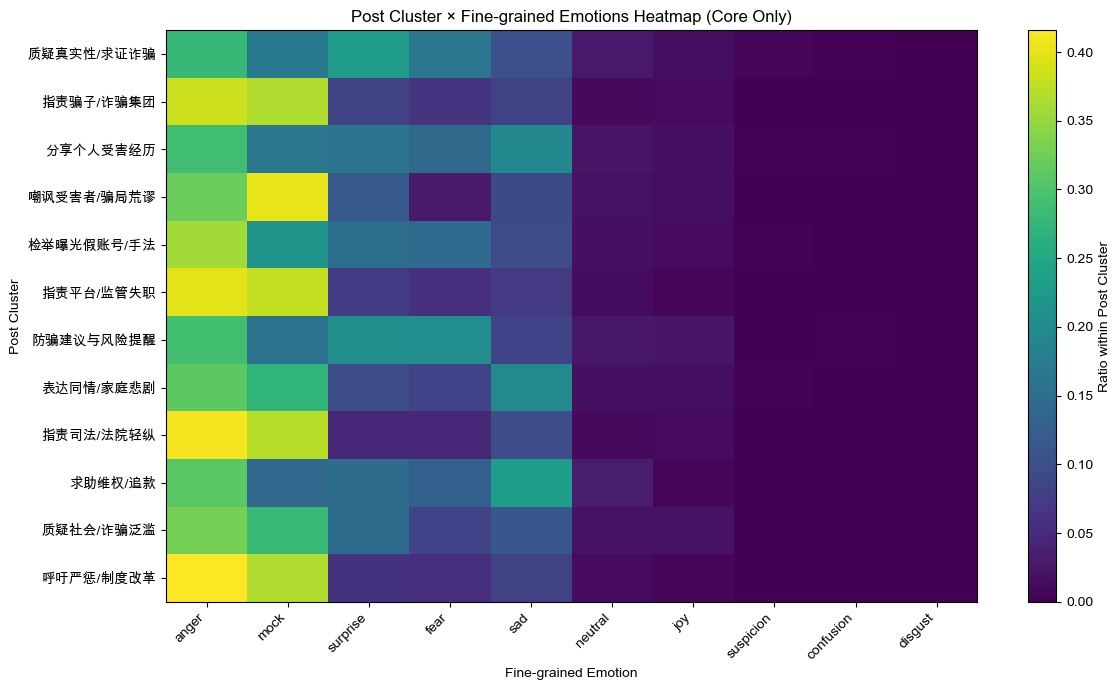

已保存：post_cluster_fine_grained_emotion_heatmap_core.png


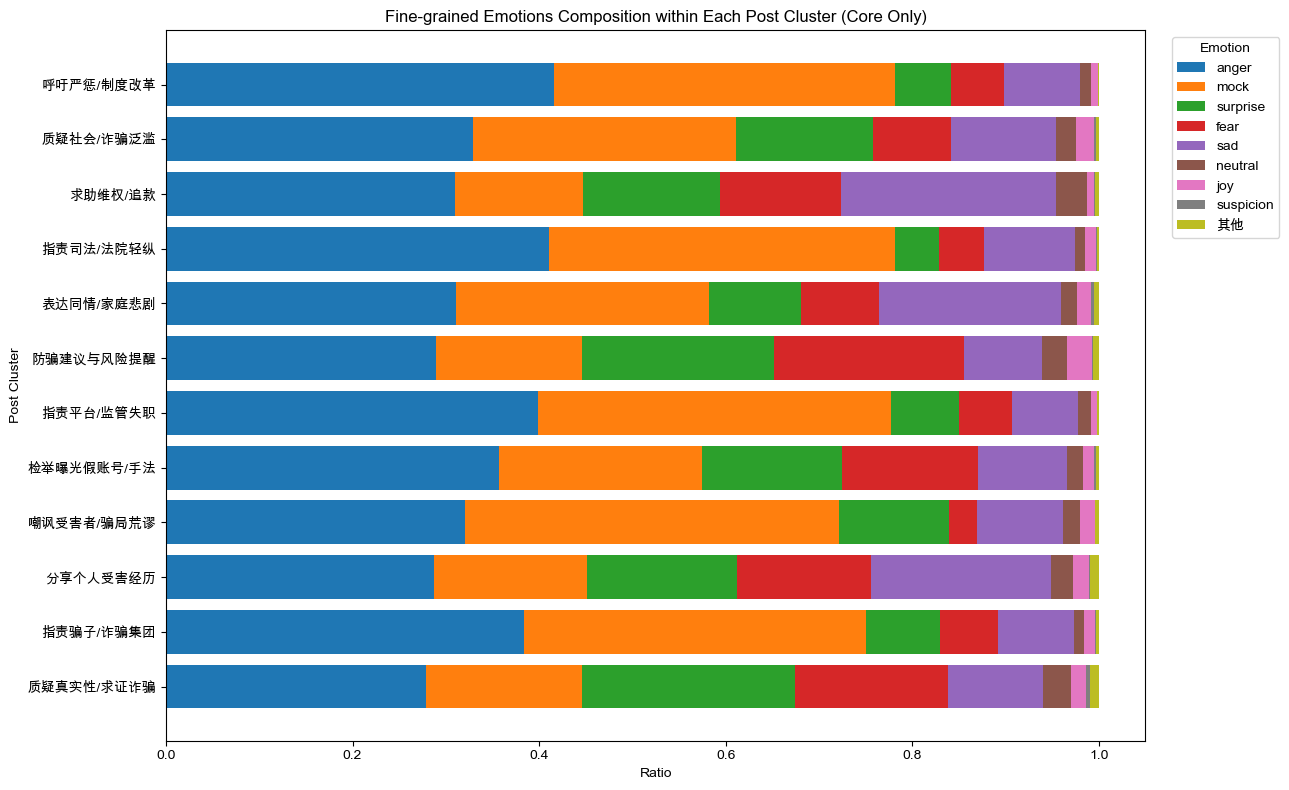

已保存：post_cluster_fine_grained_emotion_stacked_bar_core.png

全部完成，输出文件保存在：
/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/post_cluster_fine_grained_emotions_core


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# =========================================================
# 1. 路径设置
# =========================================================
INPUT_FILE = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/topic_merged_final_core_only.csv")
OUTPUT_DIR = Path("/Users/xujingyu/Desktop/课程资料/5508/project2/表2-要用的/part2_outputs/结果/聚类分析：post:comment/comment x post结合聚类分析/post_cluster_fine_grained_emotions_core")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# 2. 读取数据
# =========================================================
df = pd.read_csv(INPUT_FILE, low_memory=False)
print("原始数据大小：", df.shape)
print("列名：")
print(df.columns.tolist())

# =========================================================
# 3. 检查需要的列
# =========================================================
required_cols = ["post_cluster_id", "post_cluster_label", "fine_grained_emotions"]
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"缺少这些列：{missing_cols}")

# =========================================================
# 4. 保留核心列并清洗
# =========================================================
emotion_df = df[required_cols].copy()

emotion_df["post_cluster_id"] = emotion_df["post_cluster_id"].astype(str).str.strip()
emotion_df["post_cluster_label"] = emotion_df["post_cluster_label"].astype(str).str.strip()
emotion_df["fine_grained_emotions"] = emotion_df["fine_grained_emotions"].astype(str).str.strip()

invalid_values = ["", "nan", "none", "null", "[]", "{}", "未分类", "无", "missing"]
emotion_df = emotion_df[
    ~emotion_df["fine_grained_emotions"].str.lower().isin(invalid_values)
].copy()

print("清洗后数据大小：", emotion_df.shape)

# =========================================================
# 5. 拆分 fine_grained_emotions
# =========================================================
def split_emotions(x):
    if pd.isna(x):
        return []
    x = str(x).strip()
    if x == "":
        return []

    x = re.sub(r"^\[|\]$", "", x)
    parts = re.split(r"[;,，；|/、]+", x)
    parts = [p.strip() for p in parts if p.strip()]
    return parts

emotion_df["emotion_list"] = emotion_df["fine_grained_emotions"].apply(split_emotions)

emotion_long = emotion_df.explode("emotion_list").copy()
emotion_long = emotion_long.rename(columns={"emotion_list": "emotion"})
emotion_long["emotion"] = emotion_long["emotion"].astype(str).str.strip()

emotion_long = emotion_long[
    emotion_long["emotion"].notna() &
    (emotion_long["emotion"] != "") &
    (~emotion_long["emotion"].str.lower().isin(["nan", "none", "null"]))
].copy()

print("拆分后长表大小：", emotion_long.shape)

# =========================================================
# 6. 统计每个 post cluster 下 emotion 的数量与占比
# =========================================================
summary = (
    emotion_long
    .groupby(["post_cluster_id", "post_cluster_label", "emotion"], as_index=False)
    .size()
    .rename(columns={"size": "emotion_count"})
)

cluster_total = (
    summary
    .groupby(["post_cluster_id", "post_cluster_label"], as_index=False)["emotion_count"]
    .sum()
    .rename(columns={"emotion_count": "total_emotion_count"})
)

summary = summary.merge(cluster_total, on=["post_cluster_id", "post_cluster_label"], how="left")
summary["ratio"] = summary["emotion_count"] / summary["total_emotion_count"]

summary = summary.sort_values(
    by=["post_cluster_id", "ratio", "emotion_count"],
    ascending=[True, False, False]
).reset_index(drop=True)

summary.to_csv(OUTPUT_DIR / "post_cluster_fine_grained_emotion_distribution_core.csv", index=False, encoding="utf-8-sig")

print("\n已保存：post_cluster_fine_grained_emotion_distribution_core.csv")
print(summary.head(20))

# =========================================================
# 7. 做 pivot 表（占比）
# =========================================================
pivot_ratio = summary.pivot_table(
    index="post_cluster_label",
    columns="emotion",
    values="ratio",
    fill_value=0
)

cluster_order = (
    cluster_total.sort_values("total_emotion_count", ascending=False)["post_cluster_label"]
    .tolist()
)

pivot_ratio = pivot_ratio.reindex(cluster_order)
pivot_ratio.to_csv(OUTPUT_DIR / "post_cluster_fine_grained_emotion_pivot_ratio_core.csv", encoding="utf-8-sig")

print("\n已保存：post_cluster_fine_grained_emotion_pivot_ratio_core.csv")

# =========================================================
# 8. 做 pivot 表（计数）
# =========================================================
pivot_count = summary.pivot_table(
    index="post_cluster_label",
    columns="emotion",
    values="emotion_count",
    fill_value=0
)

pivot_count = pivot_count.reindex(cluster_order)
pivot_count.to_csv(OUTPUT_DIR / "post_cluster_fine_grained_emotion_pivot_count_core.csv", encoding="utf-8-sig")

print("已保存：post_cluster_fine_grained_emotion_pivot_count_core.csv")

# =========================================================
# 9. 提取每个 post cluster 的 Top3 emotions
# =========================================================
top3 = (
    summary
    .sort_values(["post_cluster_label", "ratio", "emotion_count"], ascending=[True, False, False])
    .groupby("post_cluster_label")
    .head(3)
    .copy()
)

top3["rank_within_cluster"] = top3.groupby("post_cluster_label").cumcount() + 1

top3 = top3[[
    "post_cluster_id", "post_cluster_label", "rank_within_cluster",
    "emotion", "emotion_count", "total_emotion_count", "ratio"
]]

top3.to_csv(OUTPUT_DIR / "post_cluster_fine_grained_emotion_top3_core.csv", index=False, encoding="utf-8-sig")

print("已保存：post_cluster_fine_grained_emotion_top3_core.csv")

# =========================================================
# 10. 热力图（只保留 top 10 emotions，更清楚）
# =========================================================
top_emotions = (
    summary.groupby("emotion", as_index=False)["emotion_count"]
    .sum()
    .sort_values("emotion_count", ascending=False)
    .head(10)["emotion"]
    .tolist()
)

heatmap_df = pivot_ratio[top_emotions].copy()

plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS", "PingFang HK", "Heiti TC", "SimHei", "Microsoft YaHei"
]
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_yticks(np.arange(len(heatmap_df.index)))

ax.set_xticklabels(heatmap_df.columns, rotation=45, ha="right")
ax.set_yticklabels(heatmap_df.index)

ax.set_title("Post Cluster × Fine-grained Emotions Heatmap (Core Only)")
ax.set_xlabel("Fine-grained Emotion")
ax.set_ylabel("Post Cluster")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Ratio within Post Cluster")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "post_cluster_fine_grained_emotion_heatmap_core.png", dpi=300, bbox_inches="tight")
plt.show()

print("已保存：post_cluster_fine_grained_emotion_heatmap_core.png")

# =========================================================
# 11. 100% 堆叠条形图（top 8 + 其他）
# =========================================================
top_emotions_bar = (
    summary.groupby("emotion", as_index=False)["emotion_count"]
    .sum()
    .sort_values("emotion_count", ascending=False)
    .head(8)["emotion"]
    .tolist()
)

stack_df = pivot_ratio[top_emotions_bar].copy()
stack_df["其他"] = 1 - stack_df.sum(axis=1)
stack_df["其他"] = stack_df["其他"].clip(lower=0)

fig, ax = plt.subplots(figsize=(13, 8))

bottom = np.zeros(len(stack_df))
for col in stack_df.columns:
    vals = stack_df[col].values
    ax.barh(stack_df.index, vals, left=bottom, label=col)
    bottom += vals

ax.set_title("Fine-grained Emotions Composition within Each Post Cluster (Core Only)")
ax.set_xlabel("Ratio")
ax.set_ylabel("Post Cluster")
ax.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "post_cluster_fine_grained_emotion_stacked_bar_core.png", dpi=300, bbox_inches="tight")
plt.show()

print("已保存：post_cluster_fine_grained_emotion_stacked_bar_core.png")

# =========================================================
# 12. 完成
# =========================================================
print("\n全部完成，输出文件保存在：")
print(OUTPUT_DIR)